# BFWAI Container Farming Training Survey Analysis
## SWB Project 297 — Beellahy Foundation Women for Agricultural Initiative
### Lagos State, Nigeria · Post-Training Survey · 2024

**Prepared by:** Statistics Without Borders (SWB)
**In collaboration with:** Beellahy Foundation

---

## Table of Contents
1. [Data Cleaning](#1-data-cleaning)
   - 1.1 Data Loading
   - 1.2 Checking Data
   - 1.3 Organize Data — Likert Encoding
   - 1.4 Develop Dataframes for Analysis
2. [Utility Functions](#2-utility-functions)
3. [Demographic Analysis](#3-demographic-analysis)
4. [Satisfaction Driver Analysis](#4-satisfaction-driver-analysis)
5. [Knowledge Assessment](#5-knowledge-assessment)
6. [Training Materials Analysis](#6-training-materials-analysis)
7. [Training Support Analysis](#7-training-support-analysis)
8. [Training Evaluation — Expectations & Challenges](#8-training-evaluation)
9. [Farming Impact & Market Access](#9-farming-impact--market-access)
10. [Future Outlook & Support Needs](#10-future-outlook--support-needs)
11. [Mentor–Mentee Matching Framework](#11-mentormentee-matching-framework)


---
## 1. Data Cleaning

### 1.1 Data Loading

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import math
# ── Chart export setup ────────────────────────────────────────────────────────
import os
try:
    _nb_dir = os.path.dirname(os.path.abspath(__file__))
except NameError:
    _nb_dir = os.getcwd()
CHART_DIR = os.path.join(_nb_dir, 'charts')
os.makedirs(CHART_DIR, exist_ok=True)
print(f"Chart export directory ready: {CHART_DIR}")


In [2]:
df = pd.read_csv(r"C:\Users\soonn\Desktop\SWB - Beellahy Foundation\Data Analysis\data\Farming Initiative Training Survey Data.csv")
df = df.drop(columns="Timestamp")
df.head()

,1.What is your gender?,2. What is your age group?,3. Which village/training site are you from?,4. For how many years have you been actively engaged in farming?,"5. Before this training, how would you rate your understanding of container farming techniques?",6.To what extent did the training improve your understanding of container farming techniques?,7.What types of training materials were provided to you? (Select all that apply),8. How easy was it for you to access the training materials when you needed them?,"9. In your opinion, were the learning resources provided during the training adequate?","10. In the past six months, how often have you revisited the training materials provided by the Beellahy Foundation?",...,25. Do you believe container farming is a practical solution for the future of agriculture in your area?,26. Did your harvest provide enough food to support your household needs?,27. Were you able to sell any surplus from your harvest?,"28. If yes, did you make a profit from selling the surplus?",29. To what extent have you applied the knowledge and skills gained from the training in your farming activities?,"30. Was the training time, speed, and practical demonstration adequate for you?",31. What additional support services would you like to receive in the future?\n(Select all that apply),32. Would you be interested in participating in future container farming trainings?,33. Do you have suggestions for how we can improve this training?,Email Address
0,Female,45+ years,Mangoro,1-3 years,Low,Completely,"In-person workshop or orientation, PowerPoint ...",Easy,Adequate,4-6 times,...,Not sure,"Yes, partially",Yes,Yes,To a great extent,Adequate,"More advanced training, Access to markets, Fin...",Yes,NaN,NaN
1,Female,45+ years,Mangoro,More than 10 years,High,Completely,In-person workshop or orientation,Neutral,Somewhat adequate,2-3 times,...,Maybe,"Yes, partially",No,NaN,To a great extent,Adequate,"More advanced training, Financial assistance/m...",Yes,Make it more elaborate to accommodate many peo...,NaN
2,Female,30-44 years,Mangoro,More than 10 years,High,Mostly,"In-person workshop or orientation, Online farm...",Easy,Adequate,2-3 times,...,No,"Yes, partially",No,NaN,To some extent,A little adequate,"Additional farming materials, Loan farmlands",Yes,"If possible, land can be loan out for those th...",NaN
3,Female,45+ years,Prefer not to say,More than 10 years,Moderate,Mostly,"In-person workshop or orientation, PowerPoint ...",Neutral,Somewhat adequate,2-3 times,...,Yes,No,No,NaN,To a great extent,Adequate,"More advanced training, Financial assistance/m...",Yes,NaN,NaN
4,Female,30-44 years,Mangoro,1-3 years,Moderate,Mostly,"In-person workshop or orientation, PowerPoint ...",Easy,Adequate,2-3 times,...,No,"Yes, fully",Yes,Yes,To a great extent,Adequate,"More advanced training, Access to markets, Fin...",Yes,NaN,NaN


### 1.2 Checking Data

In [3]:
def get_val_count(df):
    for i, col in enumerate(df.columns):
        print("=" * 60)
        print(f"COLUMN {i}: {col}")
        print("=" * 60)

        missing = df[col].isna().sum()
        blank = (df[col].astype(str).str.strip() == "").sum()
        print(f"Missing (NaN): {missing} | Blank: {blank}")
        print()

        has_comma = df[col].dropna().astype(str).str.contains(",").any()

        if has_comma:
            item_counts = (
                df[col]
                .dropna()
                .astype(str)
                .str.split(r",\s*")
                .explode()
                .str.strip()
                .replace("", pd.NA)   # blank strings → NaN
                .dropna()             # drop them
                .value_counts()
            )
            print(item_counts)
        else:
            print(df[col].value_counts(dropna=False))

        print()

In [4]:
get_val_count(df)

COLUMN 0: 1.What is your gender?
Missing (NaN): 0 | Blank: 0

1.What is your gender?
Female               166
Male                  27
Prefer not to say     24
Name: count, dtype: int64

COLUMN 1: 2. What is your age group?
Missing (NaN): 0 | Blank: 0

2. What is your age group?
30-44 years       74
45+ years         71
19-29 years       54
Below 18 years    18
Name: count, dtype: int64

COLUMN 2: 3. Which village/training site are you from?
Missing (NaN): 0 | Blank: 0

3. Which village/training site are you from?
Mangoro              81
Mosan Okunola        49
Agege                43
Iyana Ipaja          35
Prefer not to say     9
Name: count, dtype: int64

COLUMN 3: 4. For how many years have you been actively engaged in farming?
Missing (NaN): 0 | Blank: 0

4. For how many years have you been actively engaged in farming?
1-3 years             113
Less than 1 year       41
4-6 years              34
7-10 years             18
More than 10 years     11
Name: count, dtype: int64

COLUMN 

### 1.3 Organize Data — Likert Encoding

All text response options are mapped to numeric scores (1 = lowest, 5 = highest).
Encoding is applied by column index. The satisfaction column (Q14) is already
numeric in the raw data and is restored directly without mapping.

**Reverse-scored items:** `q23_nutrient_timing` and `q23_transplant_timing`
are scored in reverse in the knowledge score calculation — the correct
agronomic answer is *Strongly Disagree* (1), not *Strongly Agree* (5).


In [5]:
# Likert scale mapping
# All text response options mapped to 1-5 numeric scores
# 1 = lowest / most negative, 5 = highest / most positive
likert_map = {
    # Agree scale
    'Strongly Disagree': 1, 'Disagree': 2, 'Neutral': 3, 'Agree': 4, 'Strongly Agree': 5,

    # Ease scale
    'Very Difficult': 1, 'Very difficult': 1, 'Difficult': 2, 'Neutral': 3, 'Easy': 4, 'Very Easy': 5,

    # Extent scale (training improvement, material coverage, knowledge applied)
    'Not at all': 1, 'Very Little': 2, 'Partially': 3, 'Mostly': 4, 'Completely': 5,

    # Extent scale (knowledge applied — different wording)
    'To a small extent': 2, 'To some extent': 3, 'To a great extent': 4, 'To a very great extent': 5,

    # Prior knowledge scale
    'Very Low': 1, 'Low': 2, 'Moderate': 3, 'High': 4, 'Very High': 5,

    # Frequency scale
    'Never': 1, 'Once': 2, '2-3 times': 3, '4-6 times': 4, '7+ times': 5,

    # Resource adequacy scale
    'Inadequate': 1, 'Somewhat adequate': 2, 'Adequate': 3, 'Very adequate': 4,

    # Training pace scale
    'Not adequate': 1, 'A little adequate': 2, 'Adequate': 3, 'More than adequate': 4,

    # Expectations / binary-ish
    'No': 1, 'Maybe': 2, 'Not sure': 2, 'Yes': 3,
}

In [6]:
# Columns to apply likert encoding (by index)
LIKERT_IDX = {5, 7, 8, 9, 10, 15, 16, 22, 23, 24, 25, 31, 32}

df_encoded = df.copy()

for i in LIKERT_IDX:
    col = df_encoded.columns[i]
    df_encoded[col] = df_encoded[col].map(likert_map)

# Check result
df_encoded.iloc[:, list(LIKERT_IDX)].head()

,"30. Was the training time, speed, and practical demonstration adequate for you?",6.To what extent did the training improve your understanding of container farming techniques?,8. How easy was it for you to access the training materials when you needed them?,"9. In your opinion, were the learning resources provided during the training adequate?","10. In the past six months, how often have you revisited the training materials provided by the Beellahy Foundation?",11. To what extent did the training materials answer your farming-related questions?,"16. If yes, how easy was it to access the support?",17. Did the training meet your expectations?,23. Indicate your level of agreement with each statement [Incorporating cured organic manure during land preparation is a practical way to manage soil fertility],23. Indicate your level of agreement with each statement [Providing the wrong amount of nutrients at the wrong time does not significantly affect vegetable production(This item is reverse-scored)],23. Indicate your level of agreement with each statement [Seedlings can be transplanted at any given time of the day],23. Indicate your level of agreement with each statement [Over-watering of seedlings can be very harmful and can encourage the development of pathogenic diseases],29. To what extent have you applied the knowledge and skills gained from the training in your farming activities?
0,3,5,4,3,4,4,4.0,3,5,5,2,4,4
1,3,5,3,2,3,4,5.0,3,5,1,1,1,4
2,2,4,4,3,3,4,4.0,3,5,5,1,4,3
3,3,4,3,2,3,4,4.0,3,5,1,1,5,4
4,3,4,4,3,3,4,4.0,3,4,4,4,4,4


In [7]:
for i in LIKERT_IDX:
    col = df_encoded.columns[i]
    original_non_null = df[col].notna().sum()
    encoded_non_null  = df_encoded[col].notna().sum()
    if original_non_null != encoded_non_null:
        print(f"COL {i} — lost {original_non_null - encoded_non_null} values after mapping")
    else:
        print(f"COL {i} — OK ({encoded_non_null} values mapped)")

COL 32 — OK (217 values mapped)
COL 5 — OK (217 values mapped)
COL 7 — OK (217 values mapped)
COL 8 — OK (217 values mapped)
COL 9 — OK (217 values mapped)
COL 10 — OK (217 values mapped)
COL 15 — OK (125 values mapped)
COL 16 — OK (217 values mapped)
COL 22 — OK (217 values mapped)
COL 23 — OK (217 values mapped)
COL 24 — OK (217 values mapped)
COL 25 — OK (217 values mapped)
COL 31 — OK (217 values mapped)


In [8]:
df_encoded = df.copy()

# ── Apply likert encoding ─────────────────────────────────────────────────────
for i in LIKERT_IDX:
    col = df_encoded.columns[i]
    df_encoded[col] = df_encoded[col].map(likert_map)

# ── Drop columns not used in analysis ────────────────────────────────────────
DROP_IDX = {18, 19, 30, 35, 36}   # open text, challenges, conditional profit, suggestions, email
df_encoded = df_encoded.drop(columns=[df_encoded.columns[i] for i in DROP_IDX])

# ── Rename columns to short names ────────────────────────────────────────────
df_encoded.columns = [
    'gender',
    'age_group',
    'village',
    'farming_exp',
    'prior_knowledge',
    'training_improvement',
    'training_materials',
    'material_access',
    'resource_adequacy',
    'revisit_freq',
    'material_coverage',
    'materials_answered',
    'additional_info_sources',
    'satisfaction',
    'support_access',
    'support_ease',
    'met_expectations',
    'challenges',
    'thinning_goals',
    'snail_species',
    'q23_organic_manure',
    'q23_nutrient_timing',
    'q23_transplant_timing',
    'q23_overwatering',
    'farming_purpose',
    'future_of_farming',
    'harvest_sufficiency',
    'sold_surplus',
    'knowledge_applied',
    'training_pace',
    'future_support',
    'future_training_interest',
]

# ── Preview ───────────────────────────────────────────────────────────────────
print(f"Dataset shape: {df_encoded.shape}")
print()
df_encoded.head()


Dataset shape: (217, 32)



,gender,age_group,village,farming_exp,prior_knowledge,training_improvement,training_materials,material_access,resource_adequacy,revisit_freq,...,q23_transplant_timing,q23_overwatering,farming_purpose,future_of_farming,harvest_sufficiency,sold_surplus,knowledge_applied,training_pace,future_support,future_training_interest
0,Female,45+ years,Mangoro,1-3 years,Low,5,"In-person workshop or orientation, PowerPoint ...",4,3,4,...,2,4,"Household food consumption, Income generation",Not sure,"Yes, partially",Yes,4,3,"More advanced training, Access to markets, Fin...",Yes
1,Female,45+ years,Mangoro,More than 10 years,High,5,In-person workshop or orientation,3,2,3,...,1,1,Household food consumption,Maybe,"Yes, partially",No,4,3,"More advanced training, Financial assistance/m...",Yes
2,Female,30-44 years,Mangoro,More than 10 years,High,4,"In-person workshop or orientation, Online farm...",4,3,3,...,1,4,Household food consumption,No,"Yes, partially",No,3,2,"Additional farming materials, Loan farmlands",Yes
3,Female,45+ years,Prefer not to say,More than 10 years,Moderate,4,"In-person workshop or orientation, PowerPoint ...",3,2,3,...,1,5,Household food consumption,Yes,No,No,4,3,"More advanced training, Financial assistance/m...",Yes
4,Female,30-44 years,Mangoro,1-3 years,Moderate,4,"In-person workshop or orientation, PowerPoint ...",4,3,3,...,4,4,I am not currently using container farming,No,"Yes, fully",Yes,4,3,"More advanced training, Access to markets, Fin...",Yes


### 1.4 Develop Dataframes for Analysis

Sliced by analytical theme for cleaner section code.

In [9]:
# Slice df_encoded by question type using column positions
df_demographic          = df_encoded.iloc[:, 0:4]              # gender, age_group, village, farming_exp
df_training_materials   = df_encoded.iloc[:, 4:12]             # prior_knowledge, training_improvement, training_materials, material_access, resource_adequacy, revisit_freq, material_coverage, materials_answered
df_training_support     = df_encoded.iloc[:, 12:16]            # additional_info_sources, satisfaction, support_access, support_ease
df_training_evaluation  = df_encoded.iloc[:, 16:18]            # met_expectations, challenges
df_knowledge_check      = df_encoded.iloc[:, 18:24]            # thinning_goals, snail_species, q23_organic_manure, q23_nutrient_timing, q23_transplant_timing, q23_overwatering
df_farming_impact       = df_encoded.iloc[:, 24:28]            # farming_purpose, future_of_farming, harvest_sufficiency, sold_surplus
df_future_outlook       = df_encoded.iloc[:, [28, 29, 31]]     # knowledge_applied, training_pace, future_training_interest
df_future_support       = df_encoded.iloc[:, [30]]             # future_support

# Preview all slices
for name, d in {
    'demographic':         df_demographic,
    'training_materials':  df_training_materials,
    'training_support':    df_training_support,
    'training_evaluation': df_training_evaluation,
    'knowledge_check':     df_knowledge_check,
    'farming_impact':      df_farming_impact,
    'future_outlook':      df_future_outlook,
    'future_support':      df_future_support,
}.items():
    print(f"{name:25} → {list(d.columns)}")

demographic               → ['gender', 'age_group', 'village', 'farming_exp']
training_materials        → ['prior_knowledge', 'training_improvement', 'training_materials', 'material_access', 'resource_adequacy', 'revisit_freq', 'material_coverage', 'materials_answered']
training_support          → ['additional_info_sources', 'satisfaction', 'support_access', 'support_ease']
training_evaluation       → ['met_expectations', 'challenges']
knowledge_check           → ['thinning_goals', 'snail_species', 'q23_organic_manure', 'q23_nutrient_timing', 'q23_transplant_timing', 'q23_overwatering']
farming_impact            → ['farming_purpose', 'future_of_farming', 'harvest_sufficiency', 'sold_surplus']
future_outlook            → ['knowledge_applied', 'training_pace', 'future_training_interest']
future_support            → ['future_support']


---
## 2. Utility Functions

Reusable helper functions used throughout the analysis. Defined once here and called in later sections.

In [10]:
def set_xlabels(ax, labels, **kwargs):
    """
    Set x-axis tick labels on a matplotlib Axes.

    Parameters
    ----------
    ax     : matplotlib.axes.Axes  — axes to modify
    labels : list[str]             — label strings to display
    **kwargs                       — passed to set_xticklabels()
                                     e.g. rotation=20, ha="right", fontsize=9

    Returns : None
    """
    ax.set_xticks(range(len(labels)))
    ax.set_xticklabels(labels, **kwargs)


def pct(series, val):
    """
    Calculate the percentage of rows in a Series equal to a given value.

    Parameters
    ----------
    series : pd.Series  — any pandas Series (str or numeric)
    val    : any        — value to count (must match Series dtype)

    Returns : float — percentage (0-100), rounded to 1 decimal place

    Example : pct(df_encoded["gender"], "Female")  ->  75.7
    """
    return round(100 * (series == val).sum() / len(series), 1)


def multi_select_counts(series):
    """
    Expand comma-separated multi-select responses into individual item counts.

    Splits each cell on commas, strips whitespace, removes blank strings
    and NaN, then returns a value count Series sorted descending.

    Parameters
    ----------
    series : pd.Series[str]  — column containing comma-separated responses
                               e.g. "Option A, Option B, Option C"

    Returns : pd.Series — index=item strings (str), values=counts (int),
                          sorted descending by count

    Example : multi_select_counts(df_encoded["future_support"])
    """
    return (
        series.dropna()
        .astype(str)
        .str.split(r",\s*")
        .explode()
        .str.strip()
        .replace("", pd.NA)
        .dropna()
        .value_counts()
    )


def partial_score(response, correct_set):
    """
    Score a single multi-select response on a partial-match basis (0.0-1.0).

    Divides the number of correctly selected items by the total number
    of correct items. Returns NaN if the response is missing.

    Parameters
    ----------
    response    : str or NaN  — comma-separated response string
                                e.g. "Conserve soil, Eliminate weeds"
    correct_set : set[str]    — the complete set of correct answer strings

    Returns : float — proportion correct (0.0-1.0), or np.nan if missing

    Example : partial_score("Conserve soil, Eliminate weeds", correct_q15)
              ->  0.5  (2 of 4 correct items selected)
    """
    if pd.isna(response):
        return np.nan
    selected = set(s.strip() for s in str(response).split(","))
    return len(selected & correct_set) / len(correct_set)


def stacked_rate_bar(ax, cross_df, order, cat_order, colors,
                     title, ylabel, xlabels=None, rotation=15):
    """
    Draw a 100% stacked bar chart showing within-group rates (%).

    Each bar sums to 100%, allowing fair comparison across groups of
    different sizes. White count labels placed inside segments >= 5%.

    Parameters
    ----------
    ax        : matplotlib.axes.Axes  — target axes
    cross_df  : pd.DataFrame          — crosstab normalised by index (*100)
                                        rows=groups, columns=categories
    order     : list[str]             — row order (group names, str)
    cat_order : list[str]             — column order (category names, str)
    colors    : list[str]             — one hex colour string per category
    title     : str                   — axes title
    ylabel    : str                   — y-axis label
    xlabels   : list[str] or None     — custom x-tick labels; None uses order
    rotation  : int                   — x-label rotation in degrees

    Returns : None
    """
    import numpy as np
    x = np.arange(len(order))
    bottom = np.zeros(len(order))
    for cat, color in zip(cat_order, colors):
        if cat in cross_df.columns:
            vals = cross_df[cat].values
            ax.bar(x, vals, 0.6, bottom=bottom, color=color,
                   edgecolor="white", linewidth=1.2, label=cat)
            for i, (v, b) in enumerate(zip(vals, bottom)):
                if v >= 5:
                    ax.text(x[i], b + v / 2, f"{v:.0f}%",
                            ha="center", va="center",
                            fontsize=8.5, fontweight="bold", color="white")
            bottom += vals
    labels = xlabels if xlabels else order
    ax.set_xticks(range(len(order)))
    ax.set_xticklabels(labels, rotation=rotation,
                       ha="right" if rotation else "center", fontsize=9)
    ax.set_title(title, fontweight="bold", fontsize=11)
    ax.set_ylabel(ylabel)
    ax.set_ylim(0, 105)
    ax.legend(fontsize=8, loc="upper right",
              bbox_to_anchor=(1.0, 1.15), ncol=3)
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)


print("Utility functions defined:")
print("  set_xlabels()          — set x-axis tick labels")
print("  pct()                  — percentage of series equal to a value")
print("  multi_select_counts()  — expand comma-separated multi-select responses")
print("  partial_score()        — score multi-select on partial match (0.0-1.0)")
print("  stacked_rate_bar()     — 100% stacked rate bar chart")


Utility functions defined:
  set_xlabels()          — set x-axis tick labels
  pct()                  — percentage of series equal to a value
  multi_select_counts()  — expand comma-separated multi-select responses
  partial_score()        — score multi-select on partial match (0.0-1.0)
  stacked_rate_bar()     — 100% stacked rate bar chart


---
## 3. Demographic Analysis

Profiles the participant population across gender, age, village, and farming experience.
Insights from this section directly inform the mentor-mentee matching framework in Section 11.

### Key Findings
- **75.7% female** — gender mandate is being met; 12.9% male presence worth monitoring
- **70% beginners (<3 years experience)** — ideal for a foundational training programme
- **18 participants under 18** — flagged for review; raises questions about consent and age-appropriateness
- **Mangoro dominates at 35%** — creates site imbalance; other sites may be underserved


In [11]:
df_demographic.info()
df_demographic.head()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 217 entries, 0 to 216
Data columns (total 4 columns):
 #   Column       Non-Null Count  Dtype 
---  ------       --------------  ----- 
 0   gender       217 non-null    object
 1   age_group    217 non-null    object
 2   village      217 non-null    object
 3   farming_exp  217 non-null    object
dtypes: object(4)
memory usage: 6.9+ KB


,gender,age_group,village,farming_exp
0,Female,45+ years,Mangoro,1-3 years
1,Female,45+ years,Mangoro,More than 10 years
2,Female,30-44 years,Mangoro,More than 10 years
3,Female,45+ years,Prefer not to say,More than 10 years
4,Female,30-44 years,Mangoro,1-3 years


C:\Users\soonn\AppData\Local\Temp\ipykernel_59940\3079776961.py:26: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[0,1].set_xticklabels(age_counts.index, rotation=30, ha='right', fontsize=9)
C:\Users\soonn\AppData\Local\Temp\ipykernel_59940\3079776961.py:40: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[0,2].set_xticklabels(exp_counts.index, rotation=15, ha='right', fontsize=9)


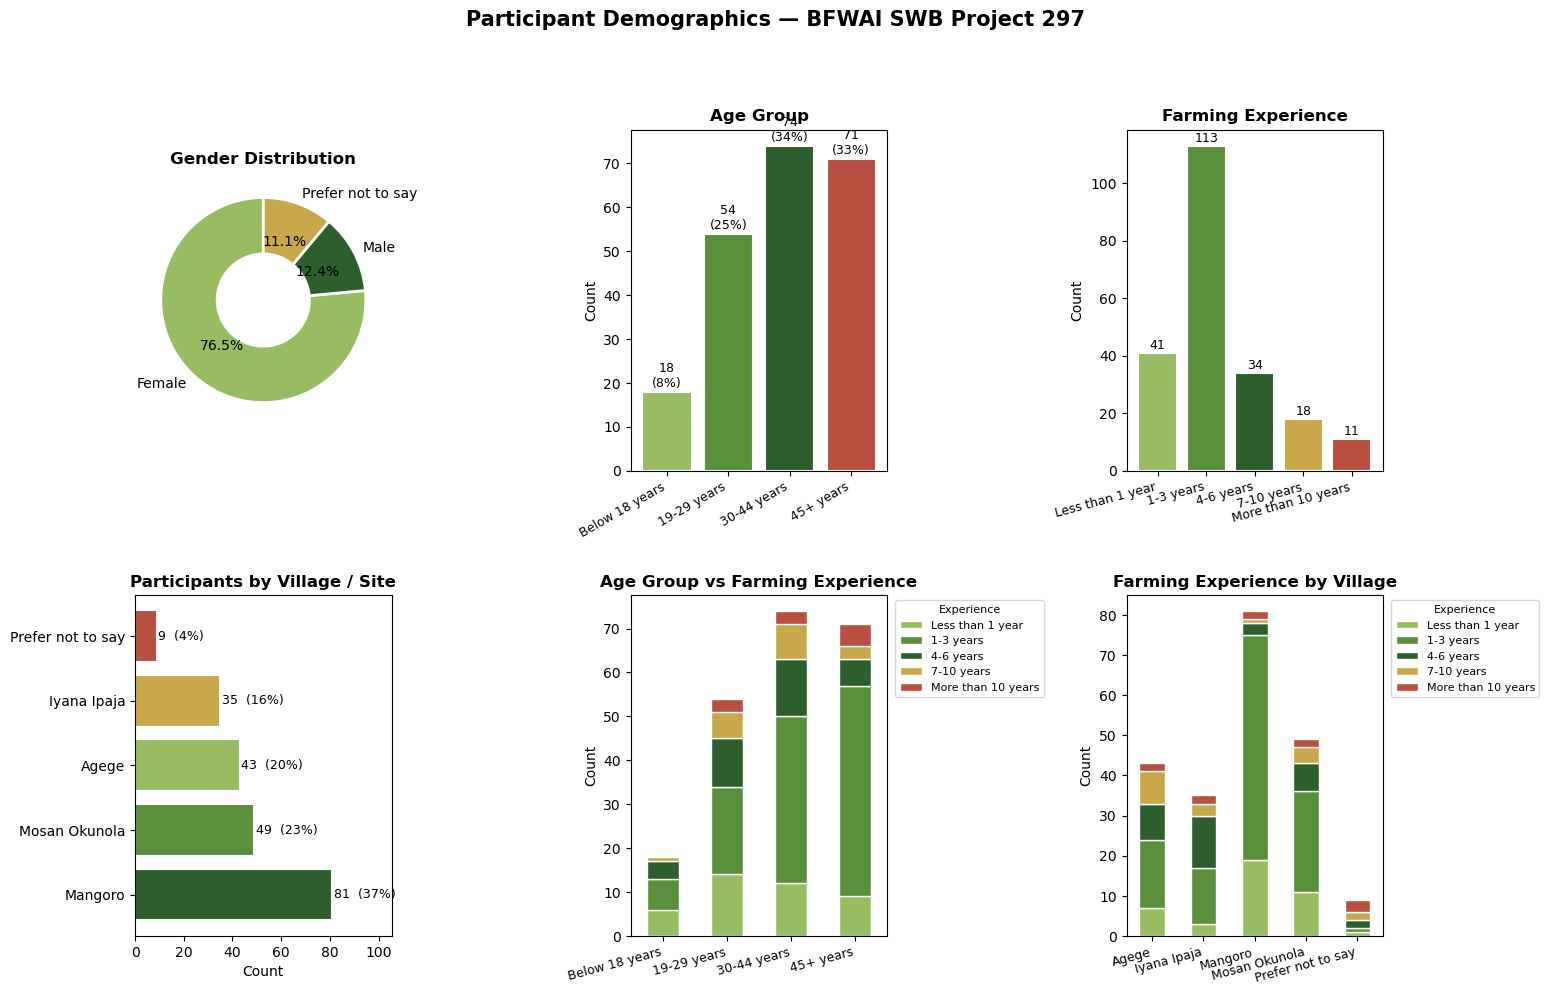

In [12]:
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import numpy as np

fig, axes = plt.subplots(2, 3, figsize=(16, 10))
fig.suptitle("Participant Demographics — BFWAI SWB Project 297", 
             fontsize=15, fontweight='bold', y=1.01)
fig.patch.set_facecolor('white')

C1 = "#2C5F2D"; C2 = "#97BC62"; C3 = "#C8A84B"; C4 = "#B85042"; C5 = "#5A8F3C"

# ── 1. Gender (pie) ───────────────────────────────────────────────────────────
gender_counts = df_demographic['gender'].value_counts()
axes[0,0].pie(gender_counts, labels=gender_counts.index, autopct='%1.1f%%',
              colors=[C2, C1, C3], startangle=90,
              wedgeprops=dict(width=0.55, edgecolor='white', linewidth=2))
axes[0,0].set_title("Gender Distribution", fontweight='bold')

# ── 2. Age Group (bar) ────────────────────────────────────────────────────────
age_order = ['Below 18 years', '19-29 years', '30-44 years', '45+ years']
age_counts = df_demographic['age_group'].value_counts().reindex(age_order).fillna(0)
bars = axes[0,1].bar(age_counts.index, age_counts.values,
                     color=[C2, C5, C1, C4], edgecolor='white', linewidth=1.5)
axes[0,1].set_title("Age Group", fontweight='bold')
axes[0,1].set_ylabel("Count")
axes[0,1].set_xticklabels(age_counts.index, rotation=30, ha='right', fontsize=9)
for bar in bars:
    h = bar.get_height()
    axes[0,1].text(bar.get_x() + bar.get_width()/2, h + 0.5,
                   f'{h:.0f}\n({100*h/len(df_demographic):.0f}%)',
                   ha='center', va='bottom', fontsize=9)

# ── 3. Farming Experience (bar) ───────────────────────────────────────────────
exp_order = ['Less than 1 year', '1-3 years', '4-6 years', '7-10 years', 'More than 10 years']
exp_counts = df_demographic['farming_exp'].value_counts().reindex(exp_order).fillna(0)
bars2 = axes[0,2].bar(exp_counts.index, exp_counts.values,
                      color=[C2, C5, C1, C3, C4], edgecolor='white', linewidth=1.5)
axes[0,2].set_title("Farming Experience", fontweight='bold')
axes[0,2].set_ylabel("Count")
axes[0,2].set_xticklabels(exp_counts.index, rotation=15, ha='right', fontsize=9)
for bar in bars2:
    h = bar.get_height()
    axes[0,2].text(bar.get_x() + bar.get_width()/2, h + 0.5,
                   f'{h:.0f}', ha='center', va='bottom', fontsize=9)

# ── 4. Village Frequency (horizontal bar) ────────────────────────────────────
village_counts = df_demographic['village'].value_counts()
axes[1,0].barh(village_counts.index, village_counts.values,
               color=[C1, C5, C2, C3, C4], edgecolor='white', linewidth=1.5)
axes[1,0].set_title("Participants by Village / Site", fontweight='bold')
axes[1,0].set_xlabel("Count")
for i, v in enumerate(village_counts.values):
    axes[1,0].text(v + 0.5, i, f'{v}  ({100*v/len(df_demographic):.0f}%)',
                   va='center', fontsize=9)
axes[1,0].set_xlim(0, village_counts.max() * 1.3)

# ── 5. Age vs Farming Experience (stacked bar) ───────────────────────────────
cross = pd.crosstab(df_demographic['age_group'], df_demographic['farming_exp'])
cross = cross.reindex(age_order).fillna(0)
cross = cross.reindex(columns=[c for c in exp_order if c in cross.columns])

cross.plot(kind='bar', stacked=True, ax=axes[1,1],
           color=[C2, C5, C1, C3, C4][:len(cross.columns)],
           edgecolor='white', linewidth=1)
axes[1,1].set_title("Age Group vs Farming Experience", fontweight='bold')
axes[1,1].set_ylabel("Count")
axes[1,1].set_xlabel("")
axes[1,1].set_xticklabels(age_order, rotation=15, ha='right', fontsize=9)
axes[1,1].legend(title="Experience", fontsize=8, title_fontsize=8,
                 bbox_to_anchor=(1.01, 1), loc='upper left')

# ── 6. Farming Experience by Village (stacked bar) ───────────────────────────
cross2 = pd.crosstab(df_demographic['village'], df_demographic['farming_exp'])
cross2 = cross2.reindex(columns=[c for c in exp_order if c in cross2.columns])

cross2.plot(kind='bar', stacked=True, ax=axes[1,2],
            color=[C2, C5, C1, C3, C4][:len(cross2.columns)],
            edgecolor='white', linewidth=1)
axes[1,2].set_title("Farming Experience by Village", fontweight='bold')
axes[1,2].set_ylabel("Count")
axes[1,2].set_xlabel("")
axes[1,2].set_xticklabels(cross2.index, rotation=15, ha='right', fontsize=9)
axes[1,2].legend(title="Experience", fontsize=8, title_fontsize=8,
                 bbox_to_anchor=(1.01, 1), loc='upper left')

plt.tight_layout(pad=2.5)

# ── Export chart ─────────────────────────────────────────────────────────────
_chart_path = os.path.join(CHART_DIR, 's03_demographics__demographic_overview.png')
plt.savefig(_chart_path, dpi=150, bbox_inches='tight', facecolor='white')
print(f'Saved: {_chart_path}')
plt.show()


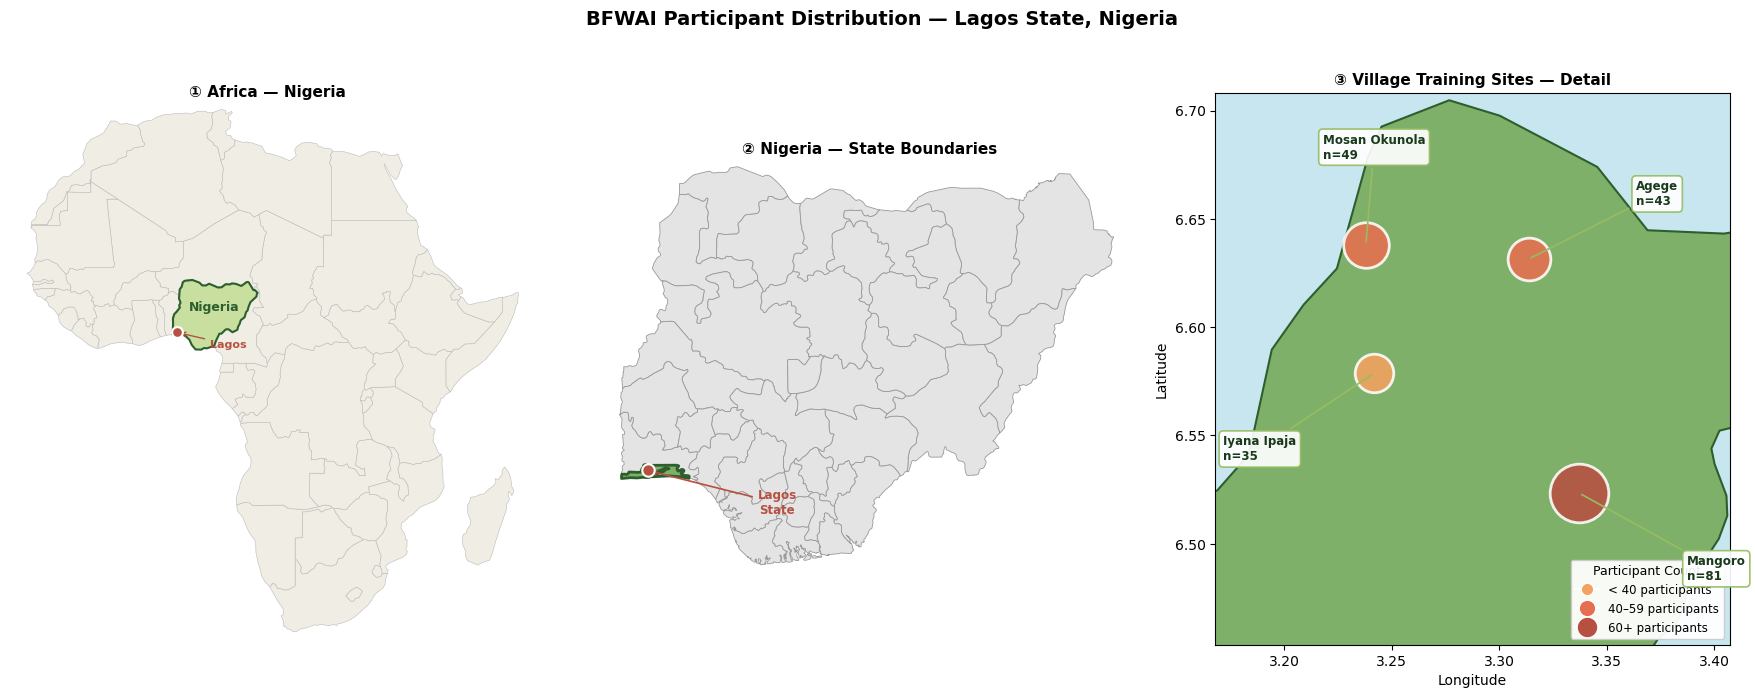

In [13]:
import geopandas as gpd
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
from shapely.geometry import Point
import pandas as pd, requests, zipfile, io, os

# ── Download geodata (run once) ───────────────────────────────────────────────
if not os.path.exists("ne_countries.geojson"):
    r = requests.get("https://github.com/nvkelso/natural-earth-vector/raw/master/geojson/ne_110m_admin_0_countries.geojson", timeout=60)
    open("ne_countries.geojson", "wb").write(r.content)

if not os.path.exists("ne_admin1_states.geojson"):
    r = requests.get("https://raw.githubusercontent.com/nvkelso/natural-earth-vector/master/geojson/ne_10m_admin_1_states_provinces.geojson", timeout=60)
    open("ne_admin1_states.geojson", "wb").write(r.content)

world          = gpd.read_file("ne_countries.geojson")
states         = gpd.read_file("ne_admin1_states.geojson")
nigeria        = world[world['ADMIN'] == 'Nigeria']
nigeria_states = states[states['admin'] == 'Nigeria']
lagos_state    = nigeria_states[nigeria_states['name'] == 'Lagos']
africa         = world[world['CONTINENT'] == 'Africa']

# ── Village data from your dataframe ─────────────────────────────────────────
village_coords = {
    'Mangoro':       (3.3372, 6.5233),
    'Mosan Okunola': (3.2380, 6.6380),
    'Agege':         (3.3136, 6.6314),
    'Iyana Ipaja':   (3.2417, 6.5786),
}
vc = df_demographic['village'].value_counts()
vc = vc[vc.index != 'Prefer not to say']
vdf = pd.DataFrame({'village': vc.index, 'count': vc.values})
vdf['lon'] = vdf['village'].map(lambda v: village_coords[v][0])
vdf['lat'] = vdf['village'].map(lambda v: village_coords[v][1])

# ── Colours ───────────────────────────────────────────────────────────────────
C_AFRICA = "#F0EDE4"; C_NIGERIA = "#C8DFA0"; C_LAGOS  = "#7FB069"
C_BORDER = "#2C5F2D"; C_OTHER   = "#E4E4E4"; C_WATER  = "#C8E6F0"
C_DOT_SM = "#F4A261"; C_DOT_MD  = "#E76F51"; C_DOT_LG = "#B85042"

def dot_color(c):
    return C_DOT_LG if c >= 60 else C_DOT_MD if c >= 40 else C_DOT_SM

# ── Plot ──────────────────────────────────────────────────────────────────────
fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(18, 7))
fig.patch.set_facecolor('white')
fig.suptitle("BFWAI Participant Distribution — Lagos State, Nigeria",
             fontsize=14, fontweight='bold')

# Panel 1: Africa
ax1.set_facecolor(C_WATER)
africa.plot(ax=ax1, color=C_AFRICA, edgecolor='#BBBBBB', linewidth=0.4)
nigeria.plot(ax=ax1, color=C_NIGERIA, edgecolor=C_BORDER, linewidth=1.5)
ax1.scatter([3.35], [6.55], s=60, c=C_DOT_LG, zorder=5, edgecolors='white', linewidths=1.5)
ax1.annotate('Lagos', xy=(3.35, 6.55), xytext=(8, 4.5), fontsize=8,
             color=C_DOT_LG, fontweight='bold',
             arrowprops=dict(arrowstyle='->', color=C_DOT_LG, lw=1))
ax1.text(8.5, 9.5, 'Nigeria', fontsize=9, color=C_BORDER, fontweight='bold', ha='center')
ax1.set_xlim(-20, 52); ax1.set_ylim(-35, 38)
ax1.set_title("① Africa — Nigeria", fontsize=11, fontweight='bold')
ax1.set_axis_off()

# Panel 2: Nigeria states
ax2.set_facecolor(C_WATER)
nigeria_states.plot(ax=ax2, color=C_OTHER, edgecolor='#999999', linewidth=0.6)
lagos_state.plot(ax=ax2, color=C_LAGOS, edgecolor=C_BORDER, linewidth=2)
ax2.scatter([3.35], [6.55], s=80, c=C_DOT_LG, zorder=5, edgecolors='white', linewidths=1.5)
ax2.annotate('Lagos\nState', xy=(3.35, 6.55), xytext=(6.5, 5.5), fontsize=8.5,
             color=C_DOT_LG, fontweight='bold', ha='center',
             arrowprops=dict(arrowstyle='->', color=C_DOT_LG, lw=1.2))
ax2.set_xlim(2.5, 15); ax2.set_ylim(4, 14)
ax2.set_title("② Nigeria — State Boundaries", fontsize=11, fontweight='bold')
ax2.set_axis_off()

# Panel 3: Village detail
pad = 0.07
ax3.set_facecolor(C_WATER)
lagos_state.plot(ax=ax3, color=C_LAGOS, edgecolor=C_BORDER, linewidth=1.5)
for _, row in vdf.iterrows():
    ax3.scatter(row['lon'], row['lat'], s=row['count'] * 22,
                c=dot_color(row['count']), alpha=0.88,
                edgecolors='white', linewidths=2, zorder=5)

offsets = {
    'Mangoro':       ( 0.05, -0.04),
    'Mosan Okunola': (-0.02,  0.04),
    'Agege':         ( 0.05,  0.025),
    'Iyana Ipaja':   (-0.07, -0.04),
}
for _, row in vdf.iterrows():
    dx, dy = offsets[row['village']]
    ax3.annotate(
        f"{row['village']}\nn={int(row['count'])}",
        xy=(row['lon'], row['lat']),
        xytext=(row['lon'] + dx, row['lat'] + dy),
        fontsize=8.5, fontweight='bold', color='#1A3A1B',
        bbox=dict(boxstyle='round,pad=0.35', facecolor='white',
                  alpha=0.92, edgecolor='#97BC62', linewidth=1.2),
        arrowprops=dict(arrowstyle='-', color='#97BC62', lw=1.2), zorder=6
    )
ax3.set_xlim(vdf['lon'].min() - pad, vdf['lon'].max() + pad)
ax3.set_ylim(vdf['lat'].min() - pad, vdf['lat'].max() + pad)
ax3.set_title("③ Village Training Sites — Detail", fontsize=11, fontweight='bold')
ax3.set_xlabel("Longitude"); ax3.set_ylabel("Latitude")

legend_items = [
    Line2D([0],[0], marker='o', color='w', markerfacecolor=C_DOT_SM,
           markersize=9,  markeredgecolor='white', label='< 40 participants'),
    Line2D([0],[0], marker='o', color='w', markerfacecolor=C_DOT_MD,
           markersize=12, markeredgecolor='white', label='40–59 participants'),
    Line2D([0],[0], marker='o', color='w', markerfacecolor=C_DOT_LG,
           markersize=15, markeredgecolor='white', label='60+ participants'),
]
ax3.legend(handles=legend_items, title='Participant Count',
           loc='lower right', fontsize=8.5, title_fontsize=9,
           framealpha=0.95, edgecolor='#CCCCCC')

plt.tight_layout(pad=2)

# ── Export chart ─────────────────────────────────────────────────────────────
_chart_path = os.path.join(CHART_DIR, 's03_demographics__nigeria_map.png')
plt.savefig(_chart_path, dpi=150, bbox_inches='tight', facecolor='white')
print(f'Saved: {_chart_path}')
plt.show()


---
## 4. Satisfaction Driver Analysis

Tests three questions:
1. **Does village predict satisfaction?** If Mangoro scores higher it may reflect
   better local infrastructure or geographic proximity to BF staff — which matters for replication.
2. **Does experience level predict knowledge score?** Validates the mentor-mentee logic.
3. **Do younger/less experienced participants apply knowledge less?**
   Crosses Q29 (knowledge applied) with age and experience.

### Finding 4.1 — Village Significantly Predicts Satisfaction
- Mangoro: 3.27/5 (highest), all other villages significantly lower
- OLS: Village explains **9.8% of variance** (R²=0.098, F=7.35, p<0.001)
- Mosan Okunola: −0.99 pts vs Mangoro (p<0.001); Iyana Ipaja: −0.84 pts (p=0.001)
- Support ease (ρ=0.63) is the single strongest overall satisfaction driver


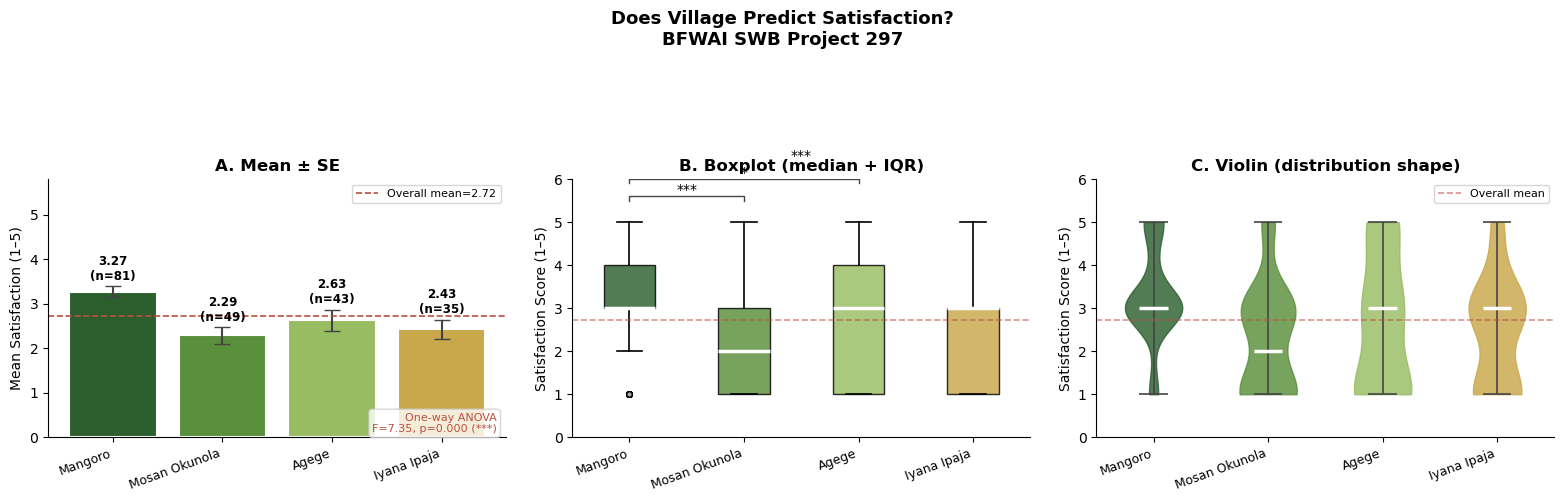

In [14]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from scipy import stats
from itertools import combinations

C1="#2C5F2D"; C2="#97BC62"; C3="#C8A84B"; C4="#B85042"; C5="#5A8F3C"
village_order  = ['Mangoro', 'Mosan Okunola', 'Agege', 'Iyana Ipaja']
village_colors = [C1, C5, C2, C3]

df_analysis = df_encoded.copy()
sat_data = [df_analysis[df_analysis['village']==v]['satisfaction'].dropna().values
            for v in village_order]

def set_xlabels(ax, labels, **kwargs):
    ax.set_xticks(range(len(labels)))
    ax.set_xticklabels(labels, **kwargs)

fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.patch.set_facecolor('white')
fig.suptitle("Does Village Predict Satisfaction?\nBFWAI SWB Project 297",
             fontsize=13, fontweight='bold', y=1.02)

# ── Panel A: Bar chart (mean ± SE) ───────────────────────────────────────────
ax = axes[0]
means = [d.mean() if len(d) > 0 else 0 for d in sat_data]
ses   = [d.std() / np.sqrt(len(d)) if len(d) > 1 else 0 for d in sat_data]
ns    = [len(d) for d in sat_data]

ax.bar(range(len(village_order)), means, yerr=ses,
       color=village_colors, edgecolor='white', linewidth=1.5,
       capsize=6, error_kw=dict(ecolor='#444', lw=1.5))
ax.axhline(df_analysis['satisfaction'].mean(), color=C4, linestyle='--',
           linewidth=1.2, label=f"Overall mean={df_analysis['satisfaction'].mean():.2f}")
ax.set_ylim(0, 5.8)
ax.set_ylabel("Mean Satisfaction (1–5)")
ax.set_title("A. Mean ± SE", fontweight='bold')
set_xlabels(ax, village_order, rotation=20, ha='right', fontsize=9)
ax.legend(fontsize=8)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
for i, (m, se, n) in enumerate(zip(means, ses, ns)):
    ax.text(i, m + se + 0.15, f"{m:.2f}\n(n={n})",
            ha='center', fontsize=8.5, fontweight='bold')

valid = [(v, d) for v, d in zip(village_order, sat_data) if len(d) > 1]
if len(valid) >= 2:
    f, p = stats.f_oneway(*[d for _, d in valid])
    sig  = "***" if p<.001 else "**" if p<.01 else "*" if p<.05 else "ns"
    ax.text(0.98, 0.02, f"One-way ANOVA\nF={f:.2f}, p={p:.3f} ({sig})",
            transform=ax.transAxes, ha='right', fontsize=8,
            color=C4 if p < 0.05 else '#666',
            bbox=dict(boxstyle='round,pad=0.3', facecolor='white',
                      edgecolor='#CCC', alpha=0.8))

# ── Panel B: Boxplot ──────────────────────────────────────────────────────────
ax = axes[1]
positions = list(range(1, len(village_order) + 1))
bp = ax.boxplot(sat_data, positions=positions, patch_artist=True, notch=False,
                medianprops=dict(color='white', linewidth=2.5),
                whiskerprops=dict(linewidth=1.2),
                capprops=dict(linewidth=1.2),
                flierprops=dict(marker='o', markerfacecolor='#AAA',
                                markersize=4, linestyle='none'))
for patch, color in zip(bp['boxes'], village_colors):
    patch.set_facecolor(color)
    patch.set_alpha(0.82)
ax.set_xticks(positions)
ax.set_xticklabels(village_order, rotation=20, ha='right', fontsize=9)
ax.set_xlim(0.5, len(village_order) + 0.5)
ax.set_title("B. Boxplot (median + IQR)", fontweight='bold')
ax.set_ylabel("Satisfaction Score (1–5)")
ax.set_ylim(0, 6)
ax.axhline(df_analysis['satisfaction'].mean(), color=C4, linestyle='--',
           linewidth=1.2, alpha=0.6)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

sig_pairs = []
for (i, v1), (j, v2) in combinations(enumerate(village_order), 2):
    d1, d2 = sat_data[i], sat_data[j]
    if len(d1) > 1 and len(d2) > 1:
        _, p_mw = stats.mannwhitneyu(d1, d2, alternative='two-sided')
        if p_mw < 0.05:
            sig_pairs.append((i+1, j+1, p_mw))
if sig_pairs:
    y_max = 5.5
    for i1, i2, p_mw in sig_pairs:
        sig = "***" if p_mw<.001 else "**" if p_mw<.01 else "*"
        ax.plot([i1, i1, i2, i2], [y_max, y_max+0.1, y_max+0.1, y_max],
                color='#444', lw=1)
        ax.text((i1+i2)/2, y_max+0.15, sig, ha='center', fontsize=10)
        y_max += 0.4

# ── Panel C: Violin ───────────────────────────────────────────────────────────
ax = axes[2]
valid_data = []
for v, d, c in zip(village_order, sat_data, village_colors):
    clean = d[~np.isnan(d)]
    if len(clean) >= 3:
        valid_data.append((v, clean, c))

positions_v = list(range(1, len(valid_data) + 1))
vp = ax.violinplot([d for _, d, _ in valid_data], positions=positions_v,
                   showmedians=True, showmeans=False)
for body, (_, _, color) in zip(vp['bodies'], valid_data):
    body.set_facecolor(color)
    body.set_edgecolor(color)
    body.set_alpha(0.82)
vp['cmedians'].set_color('white')
vp['cmedians'].set_linewidth(2.5)
for part in ['cbars', 'cmins', 'cmaxes']:
    vp[part].set_color('#444')
    vp[part].set_linewidth(1.2)
ax.set_xticks(positions_v)
ax.set_xticklabels([v for v, _, _ in valid_data], rotation=20, ha='right', fontsize=9)
ax.set_xlim(0.5, len(valid_data) + 0.5)
ax.set_title("C. Violin (distribution shape)", fontweight='bold')
ax.set_ylabel("Satisfaction Score (1–5)")
ax.set_ylim(0, 6)
ax.axhline(df_analysis['satisfaction'].mean(), color=C4, linestyle='--',
           linewidth=1.2, alpha=0.6, label="Overall mean")
ax.legend(fontsize=8)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

# ── Draw — always last ────────────────────────────────────────────────────────
plt.tight_layout(pad=2, rect=[0, 0, 1, 0.95])

# ── Export chart ─────────────────────────────────────────────────────────────
_chart_path = os.path.join(CHART_DIR, 's04_satisfaction__village_satisfaction_3panel.png')
plt.savefig(_chart_path, dpi=150, bbox_inches='tight', facecolor='white')
print(f'Saved: {_chart_path}')
plt.show()


In [15]:
import statsmodels.formula.api as smf

# ── OLS: satisfaction ~ village ───────────────────────────────────────────────
ols_df = df_analysis[['satisfaction', 'village']].dropna()
# Mangoro as reference (highest group — most meaningful comparison)
ols_df['village'] = pd.Categorical(ols_df['village'],
                                    categories=village_order)

model = smf.ols('satisfaction ~ C(village, Treatment("Mangoro"))', data=ols_df).fit()
print(model.summary())

# ── Extract key results for annotation ───────────────────────────────────────
r2   = model.rsquared
f    = model.fvalue
fp   = model.f_pvalue
sig  = "***" if fp<.001 else "**" if fp<.01 else "*" if fp<.05 else "ns"
conclusion = (
    f"OLS: Village explains {r2*100:.1f}% of satisfaction variance "
    f"(F={f:.2f}, p={fp:.3f} {sig})\n"
    f"→ Mosan Okunola is {abs(model.params.iloc[2]):.2f} pts lower than Mangoro "
    f"(p={model.pvalues.iloc[2]:.3f})"
    if fp < 0.05 else
    f"OLS: No significant village effect on satisfaction "
    f"(F={f:.2f}, p={fp:.3f})\n"
    f"→ Training quality is consistent across sites"
)
conclusion

                            OLS Regression Results                            
Dep. Variable:           satisfaction   R-squared:                       0.098
Model:                            OLS   Adj. R-squared:                  0.084
Method:                 Least Squares   F-statistic:                     7.349
Date:                Wed, 01 Jul 2026   Prob (F-statistic):           0.000106
Time:                        13:47:47   Log-Likelihood:                -346.44
No. Observations:                 208   AIC:                             700.9
Df Residuals:                     204   BIC:                             714.2
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                                                        coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------------------

'OLS: Village explains 9.8% of satisfaction variance (F=7.35, p=0.000 ***)\n→ Mosan Okunola is 0.64 pts lower than Mangoro (p=0.009)'

### Finding 4.2 — Experience Predicts Knowledge, Not Application

**Experience → Knowledge:** Significant positive relationship (Spearman ρ>0, p<0.05)
— more experienced farmers score higher on the agronomic knowledge assessment.

**High performer insight:** 10 high-scoring beginners were identified as statistical outliers.
They revisit materials significantly more (mean 3.0 vs 2.36, p=0.014) and rate material
coverage higher (3.60 vs 3.08, p=0.034). Material engagement, not just farming experience,
drives knowledge scores. Two competing interpretations: survey reference bias vs genuine
engagement-driven learning.


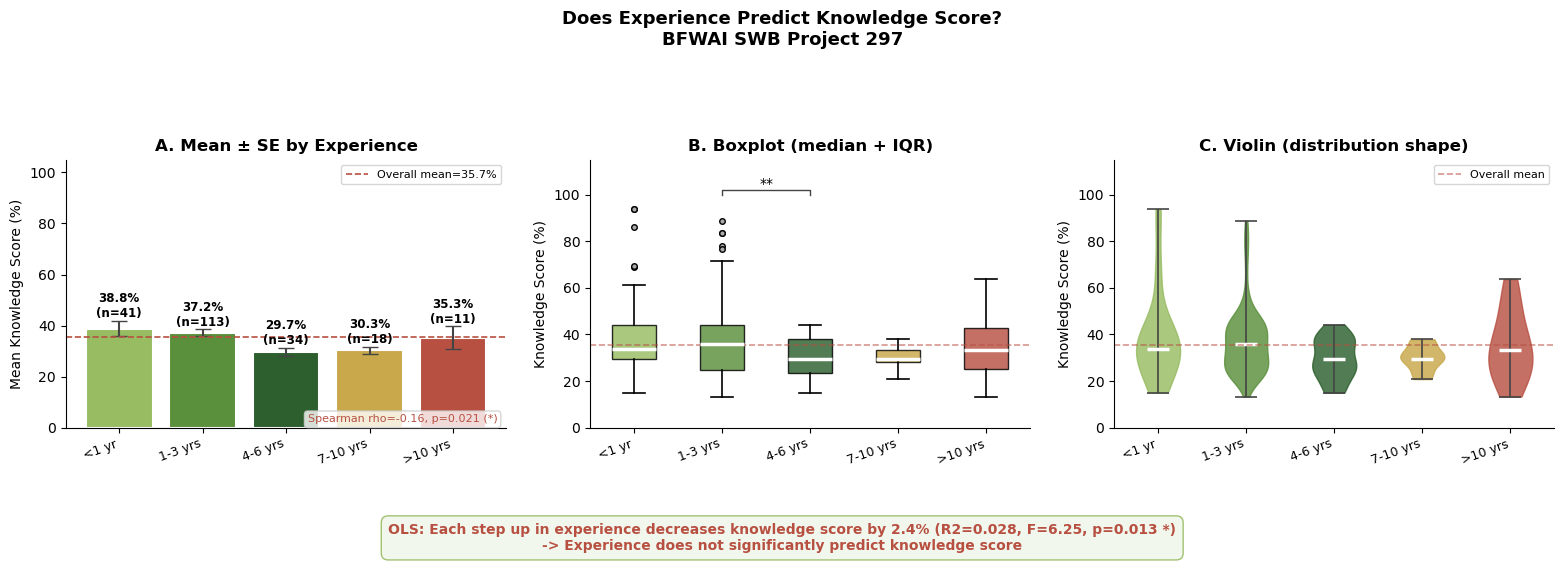

In [39]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.patch.set_facecolor('white')
fig.suptitle("Does Experience Predict Knowledge Score?\nBFWAI SWB Project 297",
             fontsize=13, fontweight='bold', y=1.02)

C1="#2C5F2D"; C2="#97BC62"; C3="#C8A84B"; C4="#B85042"; C5="#5A8F3C"
exp_order  = ['Less than 1 year', '1-3 years', '4-6 years', '7-10 years', 'More than 10 years']
exp_colors = [C2, C5, C1, C3, C4]
exp_short  = ['<1 yr', '1-3 yrs', '4-6 yrs', '7-10 yrs', '>10 yrs']

df_analysis = df_encoded.copy()
df_analysis['satisfaction'] = pd.to_numeric(df.iloc[:, 13], errors='coerce')

correct_q15 = {
    'Eliminate weeds competition during early growth',
    'Conserve soil and water nutrients',
    'Ensure increased yield growth',
    'Obtain a suitable bed'
}
correct_q16 = {
    'Obtain a specific number of plant population',
    'Improve individual plant rigour',
    'Obtain regular spacing of seedlings'
}
correct_q17 = {
    'Africa Land Snail (Archachatina Marginata)',
    'Africa Giant Snail (Achatina Achatina)',
    'Garden Snail (Achatina Fulica)'
}

def partial_score(response, correct_set):
    if pd.isna(response): return np.nan
    selected = set(s.strip() for s in str(response).split(','))
    return len(selected & correct_set) / len(correct_set)

df_analysis['score_q15'] = df.iloc[:, 19].apply(lambda x: partial_score(x, correct_q15))
df_analysis['score_q16'] = df.iloc[:, 20].apply(lambda x: partial_score(x, correct_q16))
df_analysis['score_q17'] = df.iloc[:, 21].apply(lambda x: partial_score(x, correct_q17))

likert_qs  = ['q23_organic_manure','q23_nutrient_timing','q23_transplant_timing','q23_overwatering']
reverse_qs = ['q23_nutrient_timing','q23_transplant_timing']

def likert_score(row):
    total, count = 0, 0
    for q in likert_qs:
        if pd.notna(row[q]):
            val = (6 - row[q]) if q in reverse_qs else row[q]
            total += val / 5
            count += 1
    return total / count if count > 0 else np.nan

df_analysis['score_q23']      = df_analysis.apply(likert_score, axis=1)
df_analysis['knowledge_score'] = df_analysis[
    ['score_q15','score_q16','score_q17','score_q23']
].mean(axis=1) * 100

kdata       = [df_analysis[df_analysis['farming_exp']==e]['knowledge_score'].dropna().values
               for e in exp_order]
kdata_clean = [d[~np.isnan(d)] for d in kdata]

# ── Panel A: Bar chart ────────────────────────────────────────────────────────
ax = axes[0]
means = [d.mean() if len(d) > 0 else 0 for d in kdata_clean]
ses   = [d.std() / np.sqrt(len(d)) if len(d) > 1 else 0 for d in kdata_clean]
ns    = [len(d) for d in kdata_clean]
x_pos = list(range(len(exp_order)))

ax.bar(x_pos, means, yerr=ses, color=exp_colors, edgecolor='white',
       linewidth=1.5, capsize=6, error_kw=dict(ecolor='#444', lw=1.5))
ax.axhline(df_analysis['knowledge_score'].mean(), color=C4, linestyle='--',
           linewidth=1.2, label=f"Overall mean={df_analysis['knowledge_score'].mean():.1f}%")
ax.set_ylim(0, 105)
ax.set_ylabel("Mean Knowledge Score (%)")
ax.set_title("A. Mean ± SE by Experience", fontweight='bold')
ax.set_xticks(x_pos)
ax.set_xticklabels(exp_short, rotation=20, ha='right', fontsize=9)
ax.legend(fontsize=8)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
for i, (m, se, n) in enumerate(zip(means, ses, ns)):
    ax.text(i, m + se + 1.5, f"{m:.1f}%\n(n={n})",
            ha='center', fontsize=8.5, fontweight='bold')

exp_numeric = df_analysis['farming_exp'].map({e:i for i,e in enumerate(exp_order)})
r, p = stats.spearmanr(
    exp_numeric.dropna(),
    df_analysis.loc[exp_numeric.notna(), 'knowledge_score']
)
sig = "***" if p<.001 else "**" if p<.01 else "*" if p<.05 else "ns"
ax.text(0.98, 0.02, f"Spearman rho={r:.2f}, p={p:.3f} ({sig})",
        transform=ax.transAxes, ha='right', fontsize=8,
        color=C4 if p < 0.05 else '#666',
        bbox=dict(boxstyle='round,pad=0.3', facecolor='white',
                  edgecolor='#CCC', alpha=0.8))

# ── Panel B: Boxplot ──────────────────────────────────────────────────────────
ax = axes[1]
positions_b = list(range(1, len(exp_order) + 1))
bp = ax.boxplot(kdata_clean, positions=positions_b, patch_artist=True,
                medianprops=dict(color='white', linewidth=2.5),
                whiskerprops=dict(linewidth=1.2),
                capprops=dict(linewidth=1.2),
                flierprops=dict(marker='o', markerfacecolor='#AAA',
                                markersize=4, linestyle='none'))
for patch, color in zip(bp['boxes'], exp_colors):
    patch.set_facecolor(color)
    patch.set_alpha(0.82)
ax.set_xticks(positions_b)
ax.set_xticklabels(exp_short, rotation=20, ha='right', fontsize=9)
ax.set_xlim(0.5, len(exp_order) + 0.5)
ax.set_title("B. Boxplot (median + IQR)", fontweight='bold')
ax.set_ylabel("Knowledge Score (%)")
ax.set_ylim(0, 115)
ax.axhline(df_analysis['knowledge_score'].mean(), color=C4,
           linestyle='--', linewidth=1.2, alpha=0.6)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

from itertools import combinations
y_max = 100
for (i, ei), (j, ej) in combinations(enumerate(exp_order), 2):
    d1, d2 = kdata_clean[i], kdata_clean[j]
    if len(d1) > 1 and len(d2) > 1 and abs(i-j) == 1:
        _, p_mw = stats.mannwhitneyu(d1, d2, alternative='two-sided')
        if p_mw < 0.05:
            sig_mw = "***" if p_mw<.001 else "**" if p_mw<.01 else "*"
            ax.plot([i+1, i+1, j+1, j+1],
                    [y_max, y_max+2, y_max+2, y_max], color='#444', lw=1)
            ax.text((i+j)/2+1, y_max+3, sig_mw, ha='center', fontsize=10)
            y_max += 8

# ── Panel C: Violin ───────────────────────────────────────────────────────────
ax = axes[2]
valid_data  = [(e, d, c, s) for e, d, c, s in
               zip(exp_order, kdata_clean, exp_colors, exp_short) if len(d) >= 3]
positions_v = list(range(1, len(valid_data) + 1))

vp = ax.violinplot([d for _, d, _, _ in valid_data], positions=positions_v,
                   showmedians=True, showmeans=False)
for body, (_, _, color, _) in zip(vp['bodies'], valid_data):
    body.set_facecolor(color)
    body.set_edgecolor(color)   # removes blue default outline
    body.set_alpha(0.82)
vp['cmedians'].set_color('white')
vp['cmedians'].set_linewidth(2.5)
for part in ['cbars', 'cmins', 'cmaxes']:
    vp[part].set_color('#444')
    vp[part].set_linewidth(1.2)

ax.set_xticks(positions_v)
ax.set_xticklabels([s for _, _, _, s in valid_data], rotation=20, ha='right', fontsize=9)
ax.set_xlim(0.5, len(valid_data) + 0.5)
ax.set_title("C. Violin (distribution shape)", fontweight='bold')
ax.set_ylabel("Knowledge Score (%)")
ax.set_ylim(0, 115)
ax.axhline(df_analysis['knowledge_score'].mean(), color=C4,
           linestyle='--', linewidth=1.2, alpha=0.6, label="Overall mean")
ax.legend(fontsize=8)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

# ── OLS ───────────────────────────────────────────────────────────────────────
ols_df = df_analysis[['knowledge_score','farming_exp']].dropna()
ols_df['exp_numeric'] = ols_df['farming_exp'].map({e:i for i,e in enumerate(exp_order)})
model   = smf.ols('knowledge_score ~ exp_numeric', data=ols_df).fit()
r2, f_val, fp = model.rsquared, model.fvalue, model.f_pvalue
coef    = model.params['exp_numeric']
sig_ols = "***" if fp<.001 else "**" if fp<.01 else "*" if fp<.05 else "ns"

conclusion = (
    f"OLS: Each step up in experience {'increases' if coef>0 else 'decreases'} "
    f"knowledge score by {abs(coef):.1f}% (R2={r2:.3f}, F={f_val:.2f}, p={fp:.3f} {sig_ols})\n"
    f"-> {'Mentor-mentee logic validated — experienced farmers know more' if fp<0.05 and coef>0 else 'Experience does not significantly predict knowledge score'}"
)
fig.text(0.5, -0.06, conclusion, ha='center', fontsize=10,
         color=C4 if fp < 0.05 else C1, fontweight='bold',
         bbox=dict(boxstyle='round,pad=0.5', facecolor='#F0F7EC',
                   edgecolor=C2, alpha=0.9))

plt.tight_layout(pad=2, rect=[0, 0.05, 1, 0.95])

# ── Export chart ─────────────────────────────────────────────────────────────
_chart_path = os.path.join(CHART_DIR, 's04_satisfaction__knowledge_by_experience_3panel.png')
plt.savefig(_chart_path, dpi=150, bbox_inches='tight', facecolor='white')
print(f'Saved: {_chart_path}')
plt.show()


In [17]:
from scipy import stats

# ── Recreate high_performer flag ──────────────────────────────────────────────
df_analysis['high_performer'] = (
    df_analysis['knowledge_score'] >
    df_analysis.groupby('farming_exp')['knowledge_score']
               .transform(lambda x: x.quantile(0.75) + 1.5 * (x.quantile(0.75) - x.quantile(0.25)))
)

hp     = df_analysis[df_analysis['high_performer'] == True]
non_hp = df_analysis[df_analysis['high_performer'] == False]

print("=== HIGH PERFORMERS ===")
print(hp[['revisit_freq','material_coverage','materials_answered']].describe().round(2))

print("\n=== NON HIGH PERFORMERS ===")
print(non_hp[['revisit_freq','material_coverage','materials_answered']].describe().round(2))

print("\n=== REVISIT FREQUENCY (High Performers) ===")
print(hp['revisit_freq'].value_counts().sort_index())

print("\n=== REVISIT FREQUENCY (Non High Performers) ===")
print(non_hp['revisit_freq'].value_counts().sort_index())

for col in ['revisit_freq', 'material_coverage', 'materials_answered']:
    d1 = pd.to_numeric(hp[col],     errors='coerce').dropna().values.astype(float)
    d2 = pd.to_numeric(non_hp[col], errors='coerce').dropna().values.astype(float)
    if len(d1) > 1 and len(d2) > 1:
        u, p = stats.mannwhitneyu(d1, d2, alternative='two-sided')
        print(f"\n{col}: Mann-Whitney U={u:.0f}, p={p:.3f} "
              f"({'significant ⚠' if p < 0.05 else 'not significant'})")

=== HIGH PERFORMERS ===
       revisit_freq  material_coverage
count         10.00              10.00
mean           3.00               3.60
std            0.82               0.52
min            1.00               3.00
25%            3.00               3.00
50%            3.00               4.00
75%            3.00               4.00
max            4.00               4.00

=== NON HIGH PERFORMERS ===
       revisit_freq  material_coverage
count        207.00             207.00
mean           2.36               3.08
std            0.92               0.96
min            1.00               1.00
25%            2.00               3.00
50%            2.00               3.00
75%            3.00               4.00
max            5.00               5.00

=== REVISIT FREQUENCY (High Performers) ===
revisit_freq
1    1
3    7
4    2
Name: count, dtype: int64

=== REVISIT FREQUENCY (Non High Performers) ===
revisit_freq
1    38
2    76
3    78
4    10
5     5
Name: count, dtype: int64

revisit_fre

### Finding 4.3 — Age Predicts Application, Experience Does Not

- **Age → Application:** Spearman ρ=0.18, p=0.007 ✱✱ — older participants apply more
- **Experience → Application:** Spearman ρ=−0.04, p=0.535 (ns) — flat, essentially random
- Mean application rises from 2.78 (<18 yrs) to 3.28 (30-44) and 3.24 (45+)
- The knowing-doing gap: experience predicts *what* participants know;
  age predicts *what* they actually do on the farm

**Implication:** Single-attribute matching on experience alone will fail the programme.
The mentor-mentee framework must use both age AND experience together.


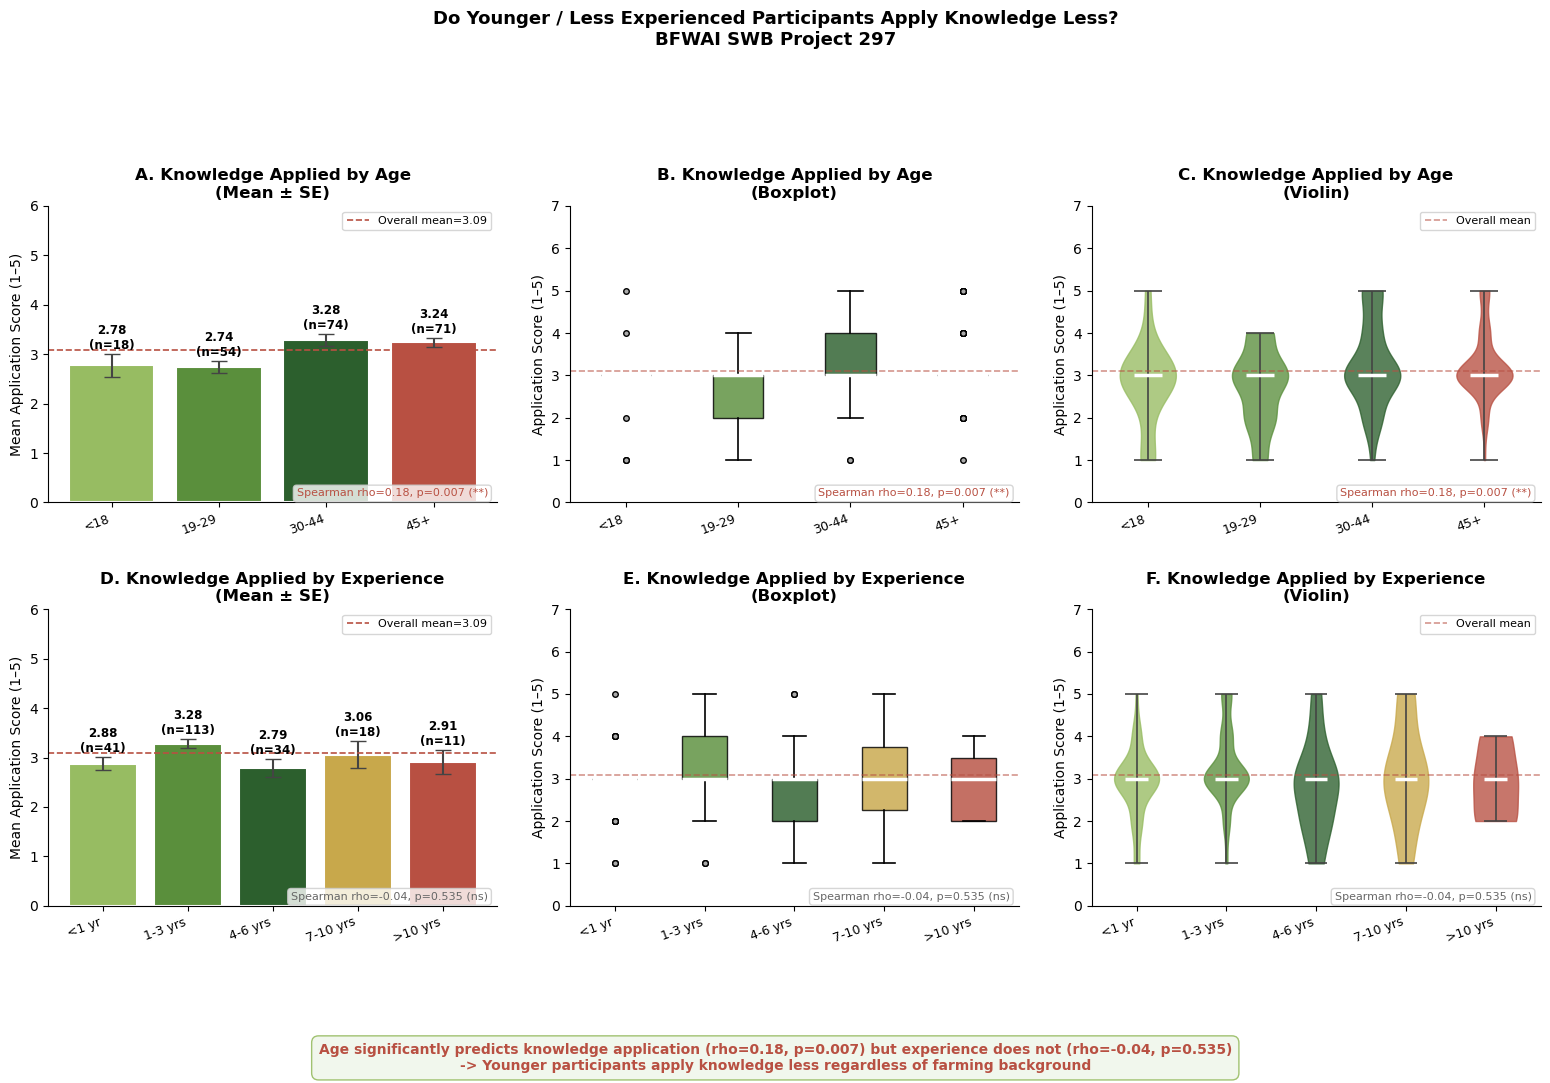


Age only:
  coef=0.209  R2=0.043  p=0.002
Experience only:
  coef=-0.038  R2=0.002  p=0.548
Both:
  age coef=0.210  p=0.002
  exp coef=-0.043  p=0.489
  Combined R2=0.045


In [41]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from scipy import stats
import statsmodels.formula.api as smf

C1="#2C5F2D"; C2="#97BC62"; C3="#C8A84B"; C4="#B85042"; C5="#5A8F3C"; C6="#F4A261"

age_order  = ['Below 18 years', '19-29 years', '30-44 years', '45+ years']
exp_order  = ['Less than 1 year', '1-3 years', '4-6 years', '7-10 years', 'More than 10 years']
age_colors = [C2, C5, C1, C4]
exp_colors = [C2, C5, C1, C3, C4]
age_short  = ['<18', '19-29', '30-44', '45+']
exp_short  = ['<1 yr', '1-3 yrs', '4-6 yrs', '7-10 yrs', '>10 yrs']

df_analysis = df_encoded.copy()
df_analysis['satisfaction'] = pd.to_numeric(df.iloc[:, 13], errors='coerce')

# ── Helper functions ──────────────────────────────────────────────────────────

def bar_with_se(ax, groups, data_col, order, colors, short_labels, title, ylabel):
    means, ses, ns = [], [], []
    for g in order:
        d = pd.to_numeric(
            df_analysis[df_analysis[groups] == g][data_col],
            errors='coerce'
        ).dropna().values.astype(float)
        means.append(d.mean() if len(d) > 0 else 0)
        ses.append(d.std() / np.sqrt(len(d)) if len(d) > 1 else 0)
        ns.append(len(d))
    ax.bar(range(len(order)), means, yerr=ses,
           color=colors, edgecolor='white', linewidth=1.5,
           capsize=6, error_kw=dict(ecolor='#444', lw=1.5))
    ax.axhline(pd.to_numeric(df_analysis[data_col], errors='coerce').mean(),
               color=C4, linestyle='--', linewidth=1.2,
               label=f"Overall mean={pd.to_numeric(df_analysis[data_col], errors='coerce').mean():.2f}")
    ax.set_ylim(0, 6)
    ax.set_ylabel(ylabel)
    ax.set_title(title, fontweight='bold')
    ax.set_xticks(range(len(order)))
    ax.set_xticklabels(short_labels, rotation=20, ha='right', fontsize=9)
    ax.legend(fontsize=8)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    for i, (m, se, n) in enumerate(zip(means, ses, ns)):
        ax.text(i, m + se + 0.1, f"{m:.2f}\n(n={n})",
                ha='center', fontsize=8.5, fontweight='bold')
    return means, ses, ns


def boxplot_panel(ax, groups, data_col, order, colors, short_labels, title, ylabel):
    bdata = [pd.to_numeric(
                 df_analysis[df_analysis[groups] == g][data_col],
                 errors='coerce'
             ).dropna().values.astype(float)
             for g in order]
    positions = list(range(1, len(order) + 1))
    bp = ax.boxplot(bdata, positions=positions, patch_artist=True,
                    medianprops=dict(color='white', linewidth=2.5),
                    whiskerprops=dict(linewidth=1.2),
                    capprops=dict(linewidth=1.2),
                    flierprops=dict(marker='o', markerfacecolor='#AAA',
                                    markersize=4, linestyle='none'))
    for patch, color in zip(bp['boxes'], colors):
        patch.set_facecolor(color)
        patch.set_alpha(0.82)
    ax.set_xticks(positions)
    ax.set_xticklabels(short_labels, rotation=20, ha='right', fontsize=9)
    ax.set_xlim(0.5, len(order) + 0.5)
    ax.set_title(title, fontweight='bold')
    ax.set_ylabel(ylabel)
    ax.set_ylim(0, 7)
    ax.axhline(pd.to_numeric(df_analysis[data_col], errors='coerce').mean(),
               color=C4, linestyle='--', linewidth=1.2, alpha=0.6)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    return bdata


def violin_panel(ax, groups, data_col, order, colors, short_labels, title, ylabel):
    valid = []
    for g, c, s in zip(order, colors, short_labels):
        d = pd.to_numeric(
            df_analysis[df_analysis[groups] == g][data_col],
            errors='coerce'
        ).dropna().values.astype(float)
        d = d[~np.isnan(d)]
        if len(d) >= 3:
            valid.append((s, d, c))
    if valid:
        positions = list(range(1, len(valid) + 1))
        vp = ax.violinplot([d for _, d, _ in valid], positions=positions,
                           showmedians=True, showmeans=False)
        for body, (_, _, color) in zip(vp['bodies'], valid):
            body.set_facecolor(color)
            body.set_edgecolor(color)   # removes blue default outline
            body.set_alpha(0.78)
        vp['cmedians'].set_color('white')
        vp['cmedians'].set_linewidth(2.5)
        for part in ['cbars', 'cmins', 'cmaxes']:
            vp[part].set_color('#444')
            vp[part].set_linewidth(1.2)
        ax.set_xticks(positions)
        ax.set_xticklabels([s for s, _, _ in valid], rotation=20, ha='right', fontsize=9)
        ax.set_xlim(0.5, len(valid) + 0.5)
    ax.set_title(title, fontweight='bold')
    ax.set_ylabel(ylabel)
    ax.set_ylim(0, 7)
    ax.axhline(pd.to_numeric(df_analysis[data_col], errors='coerce').mean(),
               color=C4, linestyle='--', linewidth=1.2, alpha=0.6,
               label="Overall mean")
    ax.legend(fontsize=8)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)


# ── Figure ────────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(2, 3, figsize=(16, 10))
fig.patch.set_facecolor('white')
fig.suptitle("Do Younger / Less Experienced Participants Apply Knowledge Less?\nBFWAI SWB Project 297",
             fontsize=13, fontweight='bold', y=1.02)

# ── ROW 1: Knowledge Applied by AGE GROUP ────────────────────────────────────
bar_with_se(axes[0,0], 'age_group', 'knowledge_applied',
            age_order, age_colors, age_short,
            "A. Knowledge Applied by Age\n(Mean ± SE)",
            "Mean Application Score (1–5)")

boxplot_panel(axes[0,1], 'age_group', 'knowledge_applied',
              age_order, age_colors, age_short,
              "B. Knowledge Applied by Age\n(Boxplot)",
              "Application Score (1–5)")

violin_panel(axes[0,2], 'age_group', 'knowledge_applied',
             age_order, age_colors, age_short,
             "C. Knowledge Applied by Age\n(Violin)",
             "Application Score (1–5)")

# Spearman — age
age_numeric = df_analysis['age_group'].map({e: i for i, e in enumerate(age_order)})
r_age, p_age = stats.spearmanr(
    age_numeric.dropna(),
    pd.to_numeric(df_analysis.loc[age_numeric.notna(), 'knowledge_applied'],
                  errors='coerce').dropna()
)
for ax in axes[0]:
    ax.text(0.98, 0.02,
            f"Spearman rho={r_age:.2f}, p={p_age:.3f} "
            f"({'***' if p_age<.001 else '**' if p_age<.01 else '*' if p_age<.05 else 'ns'})",
            transform=ax.transAxes, ha='right', fontsize=8,
            color=C4 if p_age < 0.05 else '#666',
            bbox=dict(boxstyle='round,pad=0.3', facecolor='white',
                      edgecolor='#CCC', alpha=0.8))

# ── ROW 2: Knowledge Applied by EXPERIENCE ───────────────────────────────────
bar_with_se(axes[1,0], 'farming_exp', 'knowledge_applied',
            exp_order, exp_colors, exp_short,
            "D. Knowledge Applied by Experience\n(Mean ± SE)",
            "Mean Application Score (1–5)")

boxplot_panel(axes[1,1], 'farming_exp', 'knowledge_applied',
              exp_order, exp_colors, exp_short,
              "E. Knowledge Applied by Experience\n(Boxplot)",
              "Application Score (1–5)")

violin_panel(axes[1,2], 'farming_exp', 'knowledge_applied',
             exp_order, exp_colors, exp_short,
             "F. Knowledge Applied by Experience\n(Violin)",
             "Application Score (1–5)")

# Spearman — experience
exp_numeric = df_analysis['farming_exp'].map({e: i for i, e in enumerate(exp_order)})
r_exp, p_exp = stats.spearmanr(
    exp_numeric.dropna(),
    pd.to_numeric(df_analysis.loc[exp_numeric.notna(), 'knowledge_applied'],
                  errors='coerce').dropna()
)
for ax in axes[1]:
    ax.text(0.98, 0.02,
            f"Spearman rho={r_exp:.2f}, p={p_exp:.3f} "
            f"({'***' if p_exp<.001 else '**' if p_exp<.01 else '*' if p_exp<.05 else 'ns'})",
            transform=ax.transAxes, ha='right', fontsize=8,
            color=C4 if p_exp < 0.05 else '#666',
            bbox=dict(boxstyle='round,pad=0.3', facecolor='white',
                      edgecolor='#CCC', alpha=0.8))

# ── OLS: both predictors together ────────────────────────────────────────────
ols_df = df_analysis[['knowledge_applied', 'age_group', 'farming_exp']].copy()
ols_df['age_numeric'] = ols_df['age_group'].map({e: i for i, e in enumerate(age_order)})
ols_df['exp_numeric'] = ols_df['farming_exp'].map({e: i for i, e in enumerate(exp_order)})
ols_df['knowledge_applied'] = pd.to_numeric(ols_df['knowledge_applied'], errors='coerce')
ols_df = ols_df.dropna()

m_age  = smf.ols('knowledge_applied ~ age_numeric', data=ols_df).fit()
m_exp  = smf.ols('knowledge_applied ~ exp_numeric', data=ols_df).fit()
m_both = smf.ols('knowledge_applied ~ age_numeric + exp_numeric', data=ols_df).fit()

# ── Conclusion ────────────────────────────────────────────────────────────────
age_sig = p_age < 0.05
exp_sig = p_exp < 0.05

if age_sig and exp_sig:
    conclusion = (
        f"Both age (rho={r_age:.2f}, p={p_age:.3f}) and experience (rho={r_exp:.2f}, p={p_exp:.3f}) "
        f"significantly predict knowledge application\n"
        f"OLS — Age R2={m_age.rsquared:.3f} | Experience R2={m_exp.rsquared:.3f} | "
        f"Combined R2={m_both.rsquared:.3f}  "
        f"-> {'Experience is the stronger predictor' if m_exp.rsquared > m_age.rsquared else 'Age is the stronger predictor'}"
    )
elif age_sig:
    conclusion = (
        f"Age significantly predicts knowledge application (rho={r_age:.2f}, p={p_age:.3f}) "
        f"but experience does not (rho={r_exp:.2f}, p={p_exp:.3f})\n"
        f"-> Younger participants apply knowledge less regardless of farming background"
    )
elif exp_sig:
    conclusion = (
        f"Experience significantly predicts knowledge application (rho={r_exp:.2f}, p={p_exp:.3f}) "
        f"but age does not (rho={r_age:.2f}, p={p_age:.3f})\n"
        f"-> Less experienced participants apply knowledge less — mentor pairing is warranted"
    )
else:
    conclusion = (
        f"Neither age (rho={r_age:.2f}, p={p_age:.3f}) nor experience (rho={r_exp:.2f}, p={p_exp:.3f}) "
        f"significantly predict knowledge application\n"
        f"-> Application is consistent across age and experience groups"
    )

fig.text(0.5, -0.04, conclusion, ha='center', fontsize=10,
         color=C4 if (age_sig or exp_sig) else C1, fontweight='bold',
         bbox=dict(boxstyle='round,pad=0.5', facecolor='#F0F7EC',
                   edgecolor=C2, alpha=0.9))

# ── Draw — always last ────────────────────────────────────────────────────────
plt.tight_layout(pad=2.5, rect=[0, 0.05, 1, 0.97])


# ── Print OLS summary ─────────────────────────────────────────────────────────
print("\nAge only:")
print(f"  coef={m_age.params['age_numeric']:.3f}  R2={m_age.rsquared:.3f}  p={m_age.pvalues['age_numeric']:.3f}")
print("Experience only:")
print(f"  coef={m_exp.params['exp_numeric']:.3f}  R2={m_exp.rsquared:.3f}  p={m_exp.pvalues['exp_numeric']:.3f}")
print("Both:")
print(f"  age coef={m_both.params['age_numeric']:.3f}  p={m_both.pvalues['age_numeric']:.3f}")
print(f"  exp coef={m_both.params['exp_numeric']:.3f}  p={m_both.pvalues['exp_numeric']:.3f}")
print(f"  Combined R2={m_both.rsquared:.3f}")

# ── Export chart ─────────────────────────────────────────────────────────────
_chart_path = os.path.join(CHART_DIR, 's04_satisfaction__knowledge_applied_age_experience.png')
plt.savefig(_chart_path, dpi=150, bbox_inches='tight', facecolor='white')
print(f'Saved: {_chart_path}')
plt.show()


---
## 5. Knowledge Assessment

Builds a composite knowledge score (0-100%) from:
- **score_q15:** Partial match — land preparation objectives (4 correct items)
- **score_q16:** Partial match — thinning goals (3 correct items)
- **score_q17:** Partial match — snail species (3 correct items)
- **score_q23:** Mean of 4 Likert statements; q23_nutrient_timing and
  q23_transplant_timing are **reverse scored** (correct answer = Disagree)

Knowledge score is then crossed with village, age, and experience in
Section 4 (Satisfaction Driver Analysis) and Section 11 (Mentor-Mentee Matching).

**Note on high performers:** 10 outliers in the <1yr and 1-3yr experience groups
scored 68-94%. Winsorisation applied to cap without removing — see Section 4.2.


knowledge_score ready: 217 non-null values
df_match ready: (217, 9)
role
Potential Mentor\n(Age ✓, Exp ✗)    107
Mentee                               47
Mentor                               38
Potential Mentee\n(Age ✗, Exp ✓)     25


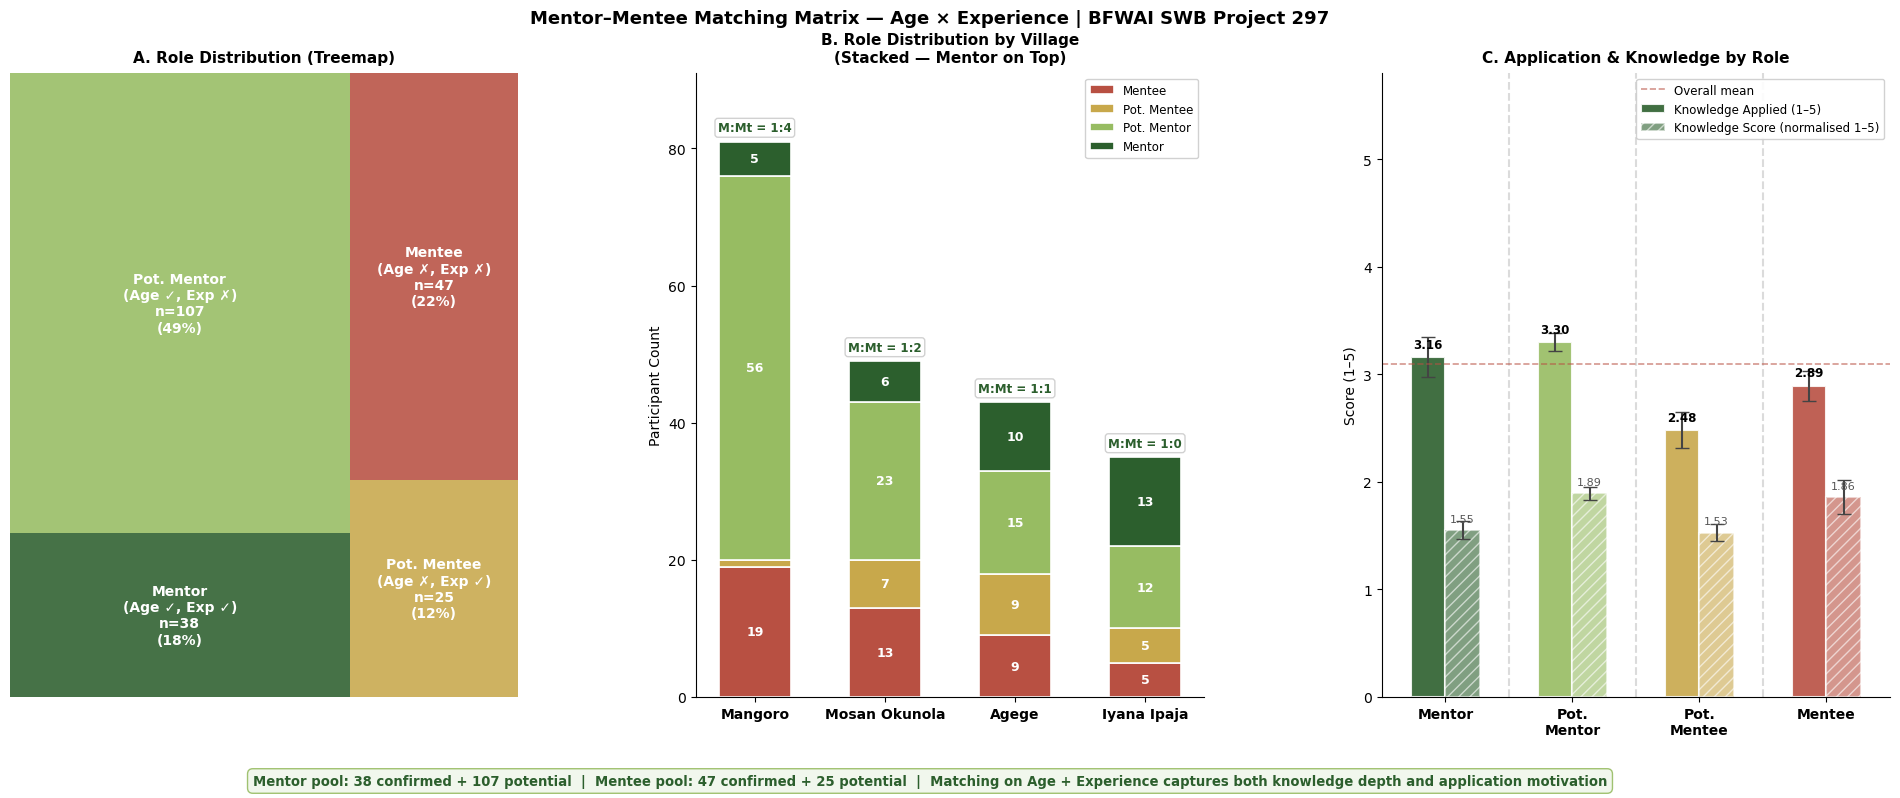

In [19]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np
import pandas as pd
import squarify

# ── Recreate knowledge_score in df_encoded ────────────────────────────────────
def partial_score(response, correct_set):
    if pd.isna(response):
        return np.nan
    selected = set(s.strip() for s in str(response).split(','))
    return len(selected & correct_set) / len(correct_set)

correct_q15 = {
    'Eliminate weeds competition during early growth',
    'Conserve soil and water nutrients',
    'Ensure increased yield growth',
    'Obtain a suitable bed'
}
correct_q16 = {
    'Obtain a specific number of plant population',
    'Improve individual plant rigour',
    'Obtain regular spacing of seedlings'
}
correct_q17 = {
    'Africa Land Snail (Archachatina Marginata)',
    'Africa Giant Snail (Achatina Achatina)',
    'Garden Snail (Achatina Fulica)'
}

likert_qs  = ['q23_organic_manure','q23_nutrient_timing','q23_transplant_timing','q23_overwatering']
reverse_qs = ['q23_nutrient_timing','q23_transplant_timing']

def likert_score(row):
    total, count = 0, 0
    for q in likert_qs:
        if pd.notna(row[q]):
            val = (6 - row[q]) if q in reverse_qs else row[q]
            total += val / 5
            count += 1
    return total / count if count > 0 else np.nan

df_encoded['score_q15']       = df.iloc[:, 19].apply(lambda x: partial_score(x, correct_q15))
df_encoded['score_q16']       = df.iloc[:, 20].apply(lambda x: partial_score(x, correct_q16))
df_encoded['score_q17']       = df.iloc[:, 21].apply(lambda x: partial_score(x, correct_q17))
df_encoded['score_q23']       = df_encoded.apply(likert_score, axis=1)
df_encoded['knowledge_score'] = df_encoded[['score_q15','score_q16',
                                             'score_q17','score_q23']].mean(axis=1) * 100
df_encoded['satisfaction']    = pd.to_numeric(df.iloc[:, 13], errors='coerce')
print("knowledge_score ready:", df_encoded['knowledge_score'].notna().sum(), "non-null values")

# ── Recreate df_match ─────────────────────────────────────────────────────────
age_order = ['Below 18 years', '19-29 years', '30-44 years', '45+ years']
exp_order = ['Less than 1 year', '1-3 years', '4-6 years', '7-10 years', 'More than 10 years']

df_match = df_encoded[['age_group', 'farming_exp', 'village',
                        'knowledge_applied', 'knowledge_score']].copy()
df_match['satisfaction']      = pd.to_numeric(df.iloc[:, 13], errors='coerce')
df_match['knowledge_applied'] = pd.to_numeric(df_match['knowledge_applied'], errors='coerce')
df_match['knowledge_score']   = pd.to_numeric(df_match['knowledge_score'],   errors='coerce')

df_match['age_senior'] = df_match['age_group'].isin(['30-44 years', '45+ years'])
df_match['exp_senior'] = df_match['farming_exp'].isin(
    ['4-6 years', '7-10 years', 'More than 10 years'])

def assign_role(row):
    if row['age_senior'] and row['exp_senior']:
        return 'Mentor'
    elif not row['age_senior'] and not row['exp_senior']:
        return 'Mentee'
    elif row['age_senior'] and not row['exp_senior']:
        return 'Potential Mentor\n(Age ✓, Exp ✗)'
    else:
        return 'Potential Mentee\n(Age ✗, Exp ✓)'

df_match['role'] = df_match.apply(assign_role, axis=1)
print("df_match ready:", df_match.shape)
print(df_match['role'].value_counts().to_string())

# ── Colours & role mappings ───────────────────────────────────────────────────
C1="#2C5F2D"; C2="#97BC62"; C3="#C8A84B"; C4="#B85042"; C5="#5A8F3C"; C6="#F4A261"

role_order = [
    'Mentor',
    'Potential Mentor\n(Age ✓, Exp ✗)',
    'Potential Mentee\n(Age ✗, Exp ✓)',
    'Mentee'
]
role_colors = {
    'Mentor':                           C1,
    'Potential Mentor\n(Age ✓, Exp ✗)': C2,
    'Potential Mentee\n(Age ✗, Exp ✓)': C3,
    'Mentee':                           C4,
}
role_short = {
    'Mentor':                           'Mentor',
    'Potential Mentor\n(Age ✓, Exp ✗)': 'Pot. Mentor',
    'Potential Mentee\n(Age ✗, Exp ✓)': 'Pot. Mentee',
    'Mentee':                           'Mentee',
}
role_short2 = {
    'Mentor':                           'Mentor\n(Age ✓, Exp ✓)',
    'Potential Mentor\n(Age ✓, Exp ✗)': 'Pot. Mentor\n(Age ✓, Exp ✗)',
    'Potential Mentee\n(Age ✗, Exp ✓)': 'Pot. Mentee\n(Age ✗, Exp ✓)',
    'Mentee':                           'Mentee\n(Age ✗, Exp ✗)',
}

# ── Figure layout ─────────────────────────────────────────────────────────────
fig = plt.figure(figsize=(20, 8))
fig.patch.set_facecolor('white')
fig.suptitle("Mentor–Mentee Matching Matrix — Age × Experience | BFWAI SWB Project 297",
             fontsize=13, fontweight='bold', y=0.98)

gs = fig.add_gridspec(1, 3, wspace=0.35, left=0.04, right=0.98,
                      top=0.90, bottom=0.12)
ax1 = fig.add_subplot(gs[0])
ax2 = fig.add_subplot(gs[1])
ax3 = fig.add_subplot(gs[2])

# ══════════════════════════════════════════════════════════════════════════════
# Panel A: Treemap
# ══════════════════════════════════════════════════════════════════════════════
role_counts = df_match['role'].value_counts()
sizes  = [role_counts.get(r, 0) for r in role_order]
colors = [role_colors[r] for r in role_order]
labels = [
    f"{role_short2[r]}\nn={role_counts.get(r, 0)}\n({100*role_counts.get(r, 0)/sum(sizes):.0f}%)"
    for r in role_order
]
squarify.plot(sizes=sizes, label=labels, color=colors,
              alpha=0.88, ax=ax1,
              text_kwargs={'fontsize': 10, 'fontweight': 'bold', 'color': 'white'})
ax1.set_title("A. Role Distribution (Treemap)", fontweight='bold', fontsize=11, pad=8)
ax1.axis('off')

# ══════════════════════════════════════════════════════════════════════════════
# Panel B: Stacked bar by village — Mentor on top
# ══════════════════════════════════════════════════════════════════════════════
village_order = ['Mangoro', 'Mosan Okunola', 'Agege', 'Iyana Ipaja']
cross = pd.crosstab(df_match['village'], df_match['role'])
cross = cross.reindex(village_order).fillna(0)

stack_order = [r for r in [
    'Mentee',
    'Potential Mentee\n(Age ✗, Exp ✓)',
    'Potential Mentor\n(Age ✓, Exp ✗)',
    'Mentor'
] if r in cross.columns]

x      = np.arange(len(village_order))
bottom = np.zeros(len(village_order))

for role in stack_order:
    vals = cross[role].values if role in cross.columns else np.zeros(len(village_order))
    bars = ax2.bar(x, vals, 0.55, bottom=bottom,
                   color=role_colors[role], edgecolor='white',
                   linewidth=1.2, label=role_short[role])
    for i, (v, b) in enumerate(zip(vals, bottom)):
        if v >= 3:
            ax2.text(x[i], b + v/2, f'{v:.0f}',
                     ha='center', va='center',
                     fontsize=9, fontweight='bold', color='white')
    bottom += vals

totals = cross[stack_order].sum(axis=1)
for i, v in enumerate(village_order):
    m  = cross.loc[v, 'Mentor'] if 'Mentor' in cross.columns else 0
    mt = cross.loc[v, 'Mentee'] if 'Mentee' in cross.columns else 0
    ratio = f"M:Mt = 1:{mt/m:.0f}" if m > 0 else "No mentor"
    ax2.text(i, totals.iloc[i] + 1.5, ratio,
             ha='center', fontsize=8.5, fontweight='bold',
             color=C4 if m == 0 else C1,
             bbox=dict(boxstyle='round,pad=0.25', facecolor='white',
                       edgecolor='#CCCCCC', alpha=0.9))

ax2.set_xticks(x)
ax2.set_xticklabels(village_order, fontsize=10, fontweight='bold')
ax2.set_title("B. Role Distribution by Village\n(Stacked — Mentor on Top)",
              fontweight='bold', fontsize=11, pad=8)
ax2.set_ylabel("Participant Count", fontsize=10)
ax2.set_ylim(0, totals.max() + 10)
ax2.legend(fontsize=8.5, loc='upper right', framealpha=0.9)
ax2.spines['top'].set_visible(False)
ax2.spines['right'].set_visible(False)

# ══════════════════════════════════════════════════════════════════════════════
# Panel C: Application & Knowledge score by role
# ══════════════════════════════════════════════════════════════════════════════
roles_clean = [
    'Mentor',
    'Potential Mentor\n(Age ✓, Exp ✗)',
    'Potential Mentee\n(Age ✗, Exp ✓)',
    'Mentee'
]
roles_short = ['Mentor', 'Pot.\nMentor', 'Pot.\nMentee', 'Mentee']

app_means, app_ses, kno_means, kno_ses = [], [], [], []
for role in roles_clean:
    sub = df_match[df_match['role'] == role]
    a   = sub['knowledge_applied'].dropna()
    k   = sub['knowledge_score'].dropna()
    app_means.append(a.mean() if len(a) > 0 else 0)
    app_ses.append(a.std() / np.sqrt(len(a)) if len(a) > 1 else 0)
    kno_means.append(k.mean() if len(k) > 0 else 0)
    kno_ses.append(k.std() / np.sqrt(len(k)) if len(k) > 1 else 0)

kno_means_norm = [k / 100 * 5 for k in kno_means]
kno_ses_norm   = [s / 100 * 5 for s in kno_ses]

group_gap2 = 1.4
x2 = np.arange(len(roles_clean)) * group_gap2
w  = 0.38

bars1 = ax3.bar(x2 - w/2, app_means, w, yerr=app_ses,
                color=[role_colors[r] for r in roles_clean],
                edgecolor='white', linewidth=1.5,
                capsize=5, error_kw=dict(ecolor='#444', lw=1.5),
                label='Knowledge Applied (1–5)', alpha=0.9)
bars2 = ax3.bar(x2 + w/2, kno_means_norm, w, yerr=kno_ses_norm,
                color=[role_colors[r] for r in roles_clean],
                edgecolor='white', linewidth=1.5, hatch='///',
                capsize=5, error_kw=dict(ecolor='#444', lw=1.5),
                label='Knowledge Score (normalised 1–5)', alpha=0.6)

for xi in x2[:-1]:
    ax3.axvline(xi + group_gap2/2, color='#CCCCCC',
                linewidth=1.5, linestyle='--', alpha=0.7)

ax3.set_xticks(x2)
ax3.set_xticklabels(roles_short, fontsize=10, fontweight='bold')
ax3.set_title("C. Application & Knowledge by Role",
              fontweight='bold', fontsize=11, pad=8)
ax3.set_ylabel("Score (1–5)", fontsize=10)
ax3.set_ylim(0, 5.8)
ax3.set_xlim(x2[0] - group_gap2/2, x2[-1] + group_gap2/2)
ax3.axhline(df_match['knowledge_applied'].mean(), color=C4,
            linestyle='--', linewidth=1.2, alpha=0.6, label='Overall mean')
ax3.legend(fontsize=8.5, loc='upper right', framealpha=0.9)
ax3.spines['top'].set_visible(False)
ax3.spines['right'].set_visible(False)

for bar in list(bars1):
    h = bar.get_height()
    if 0 < h <= 5.5:
        ax3.text(bar.get_x() + bar.get_width()/2, h + 0.06,
                 f'{h:.2f}', ha='center', va='bottom',
                 fontsize=8.5, fontweight='bold')

for bar in list(bars2):
    h = bar.get_height()
    if 0 < h <= 5.5:
        ax3.text(bar.get_x() + bar.get_width()/2, h + 0.06,
                 f'{h:.2f}', ha='center', va='bottom',
                 fontsize=8, color='#555')

# ── Bottom conclusion ─────────────────────────────────────────────────────────
mentor_n     = role_counts.get('Mentor', 0)
mentee_n     = role_counts.get('Mentee', 0)
pot_mentor_n = role_counts.get('Potential Mentor\n(Age ✓, Exp ✗)', 0)
pot_mentee_n = role_counts.get('Potential Mentee\n(Age ✗, Exp ✓)', 0)

fig.text(0.5, 0.01,
         f"Mentor pool: {mentor_n} confirmed + {pot_mentor_n} potential  |  "
         f"Mentee pool: {mentee_n} confirmed + {pot_mentee_n} potential  |  "
         f"Matching on Age + Experience captures both knowledge depth and application motivation",
         ha='center', fontsize=9.5, fontweight='bold', color=C1,
         bbox=dict(boxstyle='round,pad=0.4', facecolor='#F0F7EC',
                   edgecolor=C2, alpha=0.9))

# ── Export chart ─────────────────────────────────────────────────────────────
_chart_path = os.path.join(CHART_DIR, 's05_knowledge__knowledge_score_mentor_treemap.png')
plt.savefig(_chart_path, dpi=150, bbox_inches='tight', facecolor='white')
print(f'Saved: {_chart_path}')
plt.show()


---
## 6. Training Materials Analysis

Examines prior knowledge, training improvement, material types used,
accessibility, coverage, and whether materials fully answered participant questions.

### Key Findings
- **Training improvement mean: 3.75/5** — strongest indicator; training is perceived as effective
- **Material coverage mean: 3.10/5** — 52% say only *partially* answered questions
- **Revisit frequency mean: 2.39/5** — lowest-rated indicator; motivation barrier, not access barrier
- **Older participants (45+)** are most dissatisfied with material depth despite being most likely to apply knowledge
- **Intervention sequence:** Improve material depth first, then promote revisiting — not the reverse


In [20]:
print(df_training_materials.info())
df_training_materials.head()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 217 entries, 0 to 216
Data columns (total 8 columns):
 #   Column                Non-Null Count  Dtype 
---  ------                --------------  ----- 
 0   prior_knowledge       217 non-null    object
 1   training_improvement  217 non-null    int64 
 2   training_materials    217 non-null    object
 3   material_access       217 non-null    int64 
 4   resource_adequacy     217 non-null    int64 
 5   revisit_freq          217 non-null    int64 
 6   material_coverage     217 non-null    int64 
 7   materials_answered    217 non-null    object
dtypes: int64(5), object(3)
memory usage: 13.7+ KB
None


,prior_knowledge,training_improvement,training_materials,material_access,resource_adequacy,revisit_freq,material_coverage,materials_answered
0,Low,5,"In-person workshop or orientation, PowerPoint ...",4,3,4,4,Yes
1,High,5,In-person workshop or orientation,3,2,3,4,Yes
2,High,4,"In-person workshop or orientation, Online farm...",4,3,3,4,Yes
3,Moderate,4,"In-person workshop or orientation, PowerPoint ...",3,2,3,4,Yes
4,Moderate,4,"In-person workshop or orientation, PowerPoint ...",4,3,3,4,Yes


In [21]:
# ── Fix encodings before plotting ─────────────────────────────────────────────

# prior_knowledge — text to numeric
prior_map = {'Very Low': 1, 'Low': 2, 'Moderate': 3, 'High': 4, 'Very High': 5}
df_encoded['prior_knowledge'] = df_encoded['prior_knowledge'].map(prior_map)

# materials_answered — this is Yes/No (Q12), not a Likert scale
# use the actual Likert coverage column instead for Panel F
# material_coverage (col 10) is already numeric — check it
print("material_coverage:", df_encoded['material_coverage'].value_counts(dropna=False))
print("materials_answered (Q12 Yes/No):", df_encoded['materials_answered'].value_counts(dropna=False))

# For Panel F — replace materials_answered with material_coverage
# and remove it from the Likert bar chart since it's binary

material_coverage: material_coverage
3    112
4     43
2     31
5     18
1     13
Name: count, dtype: int64
materials_answered (Q12 Yes/No): materials_answered
Yes    126
No      91
Name: count, dtype: int64


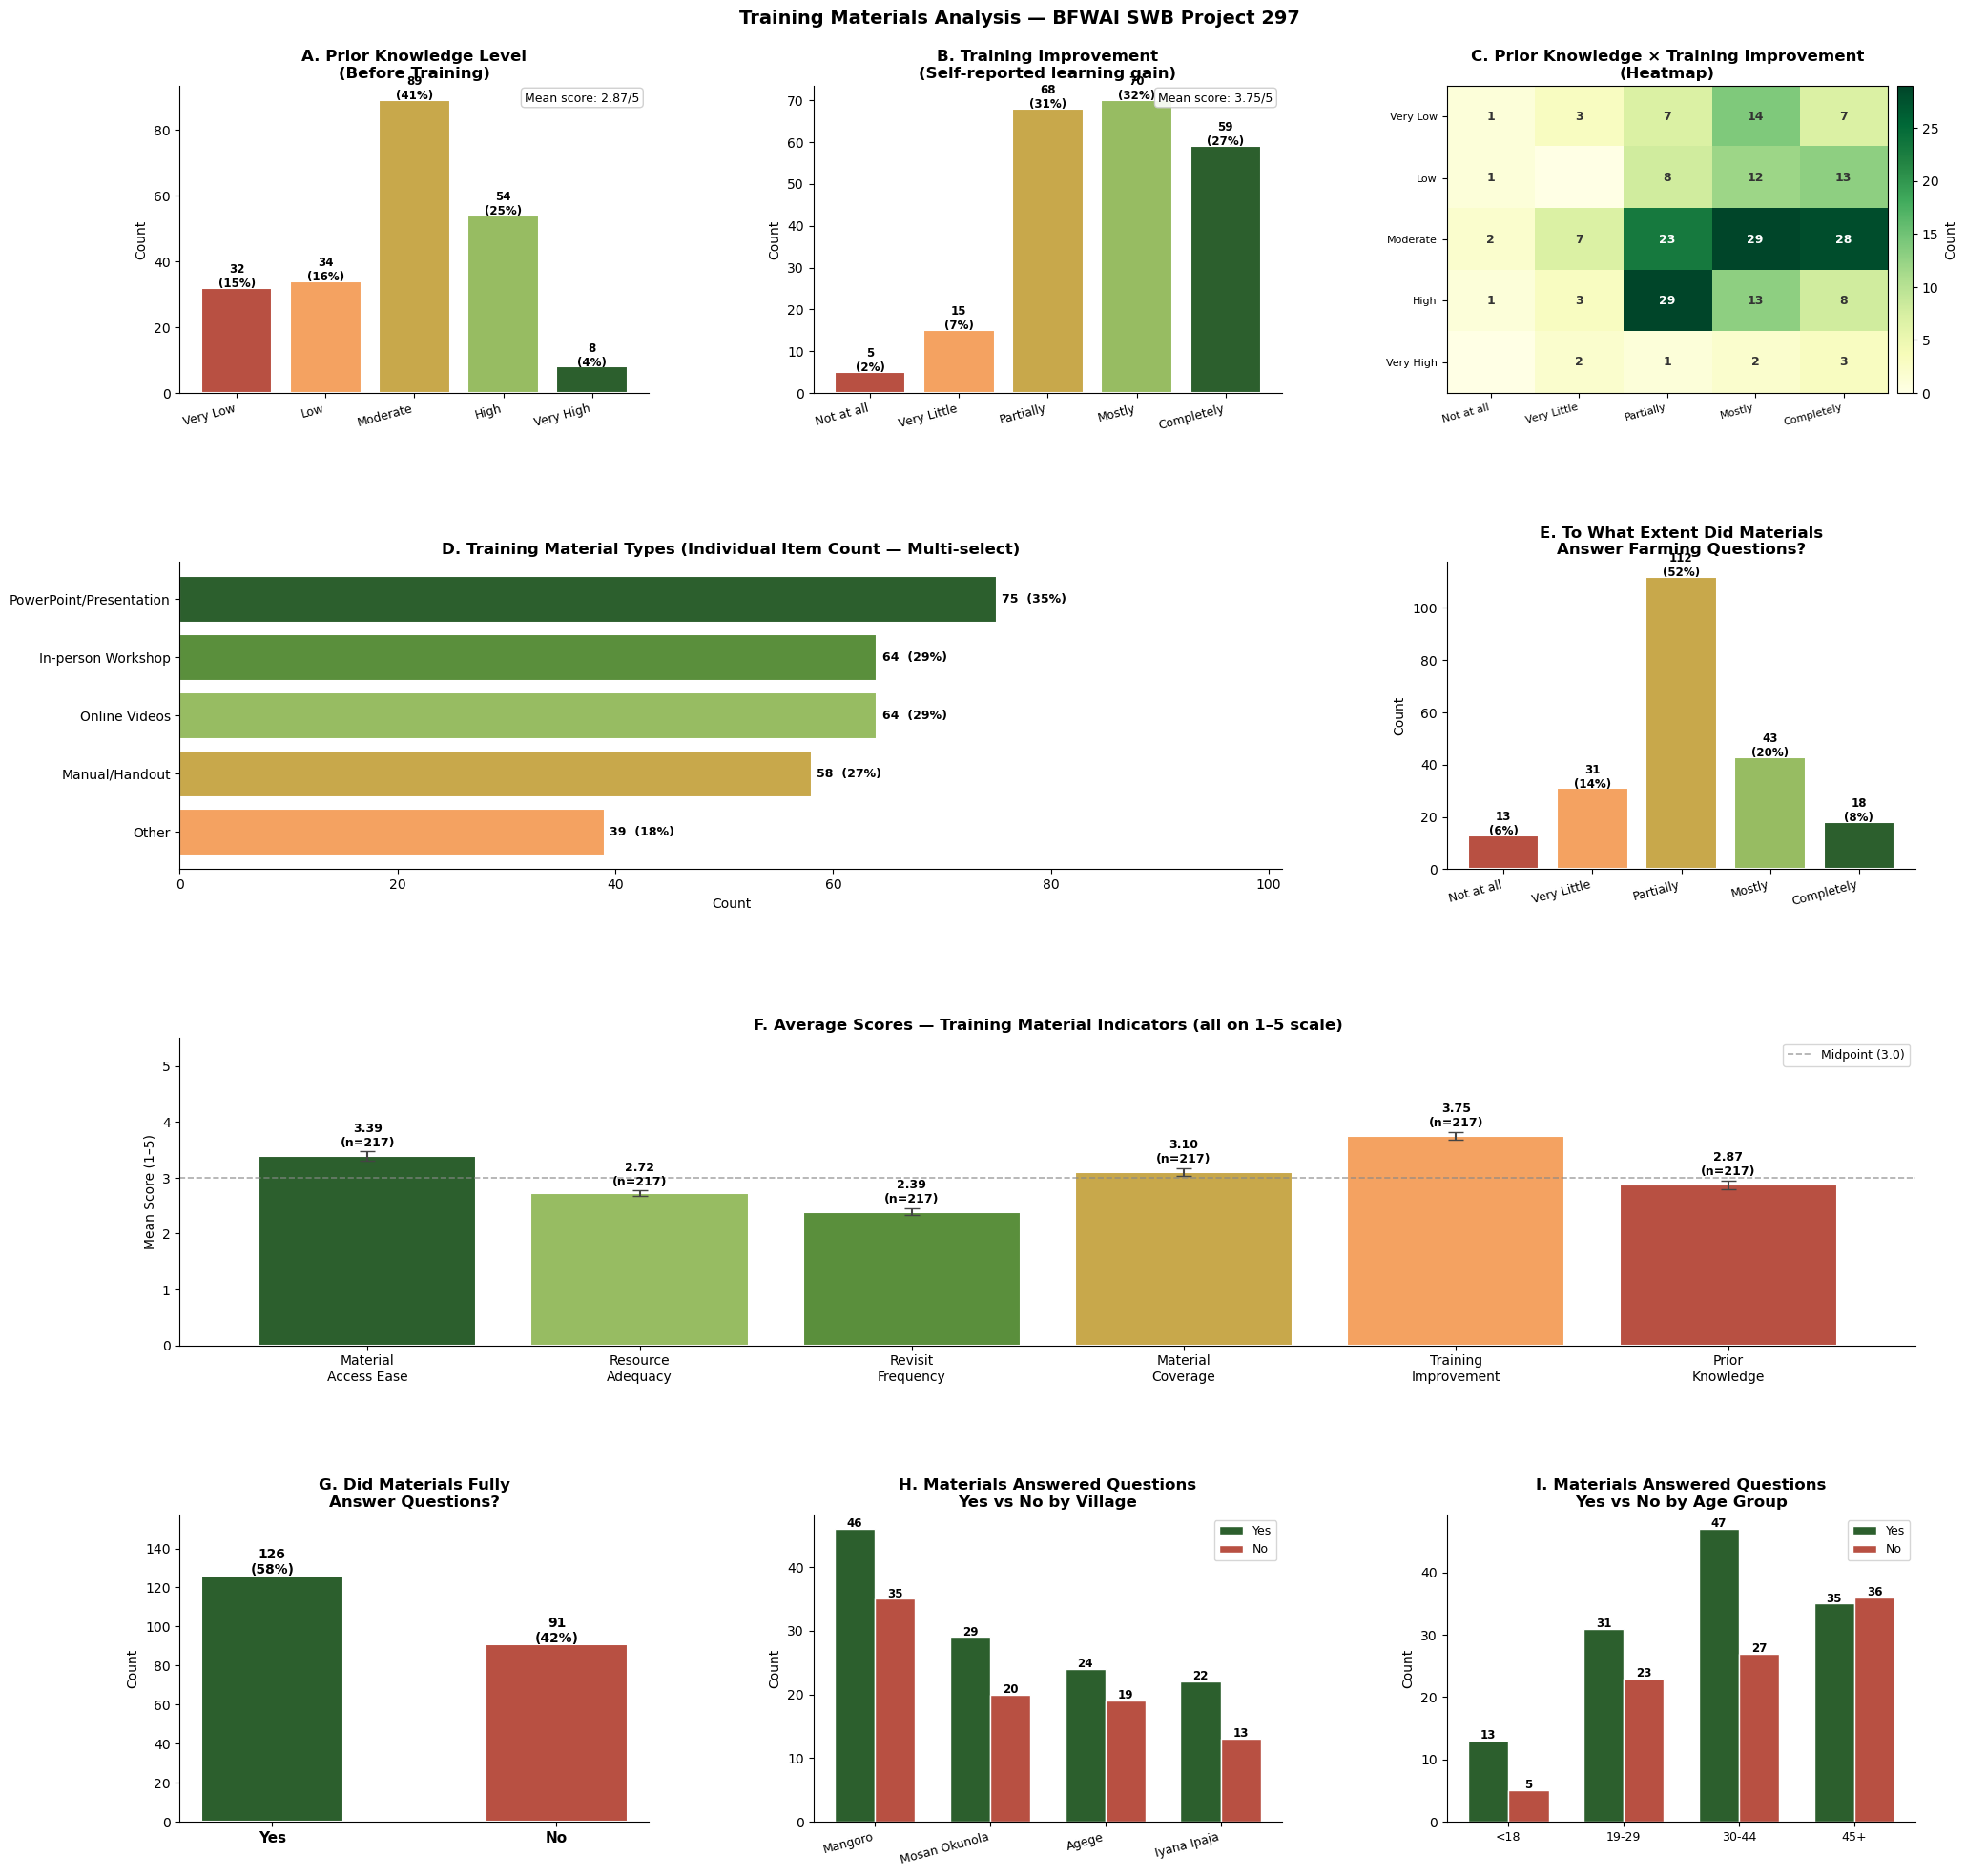

In [22]:
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import numpy as np
import pandas as pd

fig = plt.figure(figsize=(20, 20))
fig.patch.set_facecolor('white')
fig.suptitle("Training Materials Analysis — BFWAI SWB Project 297",
             fontsize=14, fontweight='bold', y=0.99)

gs = gridspec.GridSpec(4, 3, figure=fig, hspace=0.55, wspace=0.35,
                       left=0.06, right=0.97, top=0.95, bottom=0.04)

C1="#2C5F2D"; C2="#97BC62"; C3="#C8A84B"; C4="#B85042"; C5="#5A8F3C"; C6="#F4A261"

def set_xlabels(ax, labels, **kwargs):
    ax.set_xticks(range(len(labels)))
    ax.set_xticklabels(labels, **kwargs)

# ══════════════════════════════════════════════════════════════════════════════
# ROW 1: Prior Knowledge histogram + Training Improvement frequency
# ══════════════════════════════════════════════════════════════════════════════

# ── A. Prior Knowledge histogram ──────────────────────────────────────────────
ax_a = fig.add_subplot(gs[0, 0])
prior_order  = ['Very Low', 'Low', 'Moderate', 'High', 'Very High']
prior_counts = df_encoded['prior_knowledge'].map(
    {1:'Very Low', 2:'Low', 3:'Moderate', 4:'High', 5:'Very High'}
).value_counts().reindex(prior_order).fillna(0)
prior_colors = [C4, C6, C3, C2, C1]
bars = ax_a.bar(range(len(prior_order)), prior_counts.values,
                color=prior_colors, edgecolor='white', linewidth=1.5)
set_xlabels(ax_a, prior_order, rotation=15, ha='right', fontsize=9)
ax_a.set_title("A. Prior Knowledge Level\n(Before Training)", fontweight='bold')
ax_a.set_ylabel("Count")
for bar in bars:
    h = bar.get_height()
    if h > 0:
        ax_a.text(bar.get_x() + bar.get_width()/2, h + 0.3,
                  f'{h:.0f}\n({100*h/len(df_encoded):.0f}%)',
                  ha='center', fontsize=8.5, fontweight='bold')
mean_prior = pd.to_numeric(df_encoded['prior_knowledge'], errors='coerce').mean()
ax_a.axhline(0, color='white', linewidth=0)
ax_a.text(0.98, 0.95, f"Mean score: {mean_prior:.2f}/5",
          transform=ax_a.transAxes, ha='right', fontsize=9,
          bbox=dict(boxstyle='round,pad=0.3', facecolor='white',
                    edgecolor='#CCC', alpha=0.9))
ax_a.spines['top'].set_visible(False)
ax_a.spines['right'].set_visible(False)

# ── B. Training Improvement frequency ────────────────────────────────────────
ax_b = fig.add_subplot(gs[0, 1])
imp_order  = ['Not at all', 'Very Little', 'Partially', 'Mostly', 'Completely']
imp_counts = df_encoded['training_improvement'].map(
    {1:'Not at all', 2:'Very Little', 3:'Partially', 4:'Mostly', 5:'Completely'}
).value_counts().reindex(imp_order).fillna(0)
imp_colors = [C4, C6, C3, C2, C1]
bars_b = ax_b.bar(range(len(imp_order)), imp_counts.values,
                  color=imp_colors, edgecolor='white', linewidth=1.5)
set_xlabels(ax_b, imp_order, rotation=15, ha='right', fontsize=9)
ax_b.set_title("B. Training Improvement\n(Self-reported learning gain)", fontweight='bold')
ax_b.set_ylabel("Count")
for bar in bars_b:
    h = bar.get_height()
    if h > 0:
        ax_b.text(bar.get_x() + bar.get_width()/2, h + 0.3,
                  f'{h:.0f}\n({100*h/len(df_encoded):.0f}%)',
                  ha='center', fontsize=8.5, fontweight='bold')
mean_imp = pd.to_numeric(df_encoded['training_improvement'], errors='coerce').mean()
ax_b.text(0.98, 0.95, f"Mean score: {mean_imp:.2f}/5",
          transform=ax_b.transAxes, ha='right', fontsize=9,
          bbox=dict(boxstyle='round,pad=0.3', facecolor='white',
                    edgecolor='#CCC', alpha=0.9))
ax_b.spines['top'].set_visible(False)
ax_b.spines['right'].set_visible(False)

# ── C. Prior Knowledge vs Training Improvement (cross) ───────────────────────
ax_c = fig.add_subplot(gs[0, 2])
cross_pi = pd.crosstab(
    df_encoded['prior_knowledge'].map({1:'Very Low',2:'Low',3:'Moderate',4:'High',5:'Very High'}),
    df_encoded['training_improvement'].map({1:'Not at all',2:'Very Little',3:'Partially',4:'Mostly',5:'Completely'})
).reindex(prior_order).reindex(columns=imp_order).fillna(0)

im = ax_c.imshow(cross_pi.values, cmap='YlGn', aspect='auto')
set_xlabels(ax_c, imp_order, rotation=15, ha='right', fontsize=8)
ax_c.set_yticks(range(len(prior_order)))
ax_c.set_yticklabels(prior_order, fontsize=8)
ax_c.set_title("C. Prior Knowledge × Training Improvement\n(Heatmap)", fontweight='bold')
plt.colorbar(im, ax=ax_c, fraction=0.04, pad=0.02, label='Count')
for i in range(len(prior_order)):
    for j in range(len(imp_order)):
        val = int(cross_pi.values[i, j])
        if val > 0:
            ax_c.text(j, i, str(val), ha='center', va='center',
                      fontsize=9, fontweight='bold',
                      color='white' if val > cross_pi.values.max()*0.6 else '#333')

# ══════════════════════════════════════════════════════════════════════════════
# ROW 2: Training Materials frequency + Materials answered
# ══════════════════════════════════════════════════════════════════════════════

# ── D. Training Materials (multi-select split) ────────────────────────────────
ax_d = fig.add_subplot(gs[1, 0:2])
mat_col = df.columns[6]
mat_counts = (
    df[mat_col].dropna()
    .astype(str)
    .str.split(r',\s*')
    .explode()
    .str.strip()
    .replace('', pd.NA)
    .dropna()
    .value_counts()
)
short_labels = {
    'In-person workshop or orientation': 'In-person Workshop',
    'PowerPoint or printed presentation': 'PowerPoint/Presentation',
    'Farming Manual or Handout':          'Manual/Handout',
    'Online farming practice videos':     'Online Videos',
    'Other':                              'Other',
}
mat_counts.index = [short_labels.get(i, i) for i in mat_counts.index]
bar_colors_d = [C1, C5, C2, C3, C6][:len(mat_counts)]
bars_d = ax_d.barh(mat_counts.index[::-1], mat_counts.values[::-1],
                   color=bar_colors_d[::-1],
                   edgecolor='white', linewidth=1.5)
ax_d.set_title("D. Training Material Types (Individual Item Count — Multi-select)",
               fontweight='bold')
ax_d.set_xlabel("Count")
ax_d.set_xlim(0, mat_counts.max() * 1.35)
for bar in bars_d:
    w = bar.get_width()
    x_pos = bar.get_x() + w + 0.5
    y_pos = bar.get_y() + bar.get_height() / 2
    if np.isfinite(x_pos) and np.isfinite(y_pos) and w > 0:
        ax_d.text(x_pos, y_pos,
                  f'{w:.0f}  ({100*w/len(df):.0f}%)',
                  va='center', fontsize=9, fontweight='bold')
ax_d.spines['top'].set_visible(False)
ax_d.spines['right'].set_visible(False)

# ── E. Material Coverage (Likert) ─────────────────────────────────────────────
ax_e = fig.add_subplot(gs[1, 2])
cov_counts = df_encoded['material_coverage'].map(
    {1:'Not at all', 2:'Very Little', 3:'Partially', 4:'Mostly', 5:'Completely'}
).value_counts().reindex(['Not at all','Very Little','Partially','Mostly','Completely']).fillna(0)
bars_e = ax_e.bar(range(len(cov_counts)), cov_counts.values,
                  color=[C4,C6,C3,C2,C1], edgecolor='white', linewidth=1.5)
set_xlabels(ax_e, cov_counts.index, rotation=15, ha='right', fontsize=9)
ax_e.set_title("E. To What Extent Did Materials\nAnswer Farming Questions?", fontweight='bold')
ax_e.set_ylabel("Count")
for bar in bars_e:
    h = bar.get_height()
    if h > 0:
        ax_e.text(bar.get_x() + bar.get_width()/2, h + 0.3,
                  f'{h:.0f}\n({100*h/len(df_encoded):.0f}%)',
                  ha='center', fontsize=8.5, fontweight='bold')
ax_e.spines['top'].set_visible(False)
ax_e.spines['right'].set_visible(False)

# ══════════════════════════════════════════════════════════════════════════════
# ROW 3: Likert averages — material access, adequacy, revisit, coverage
# ══════════════════════════════════════════════════════════════════════════════
ax_f = fig.add_subplot(gs[2, 0:3])

likert_vars = {
    'Material\nAccess Ease':  'material_access',
    'Resource\nAdequacy':     'resource_adequacy',
    'Revisit\nFrequency':     'revisit_freq',
    'Material\nCoverage':     'material_coverage',
    'Training\nImprovement':  'training_improvement',
    'Prior\nKnowledge':       'prior_knowledge',
}


means, ses, ns = [], [], []
for col in likert_vars.values():
    d = pd.to_numeric(df_encoded[col], errors='coerce').dropna()
    means.append(d.mean())
    ses.append(d.std() / np.sqrt(len(d)))
    ns.append(len(d))

bar_colors = [C1, C2, C5, C3, C6, C4, C2]
bars_f = ax_f.bar(range(len(likert_vars)), means, yerr=ses,
                  color=bar_colors, edgecolor='white', linewidth=1.5,
                  capsize=6, error_kw=dict(ecolor='#444', lw=1.5))
ax_f.axhline(3.0, color='#888', linestyle='--', linewidth=1.2,
             alpha=0.7, label='Midpoint (3.0)')
set_xlabels(ax_f, list(likert_vars.keys()), rotation=0, fontsize=10)
ax_f.set_title("F. Average Scores — Training Material Indicators (all on 1–5 scale)",
               fontweight='bold')
ax_f.set_ylabel("Mean Score (1–5)")
ax_f.set_ylim(0, 5.5)
ax_f.legend(fontsize=9)
ax_f.spines['top'].set_visible(False)
ax_f.spines['right'].set_visible(False)
for i, (m, se, n) in enumerate(zip(means, ses, ns)):
    ax_f.text(i, m + se + 0.1, f'{m:.2f}\n(n={n})',
              ha='center', fontsize=9, fontweight='bold')

# ══════════════════════════════════════════════════════════════════════════════
# ROW 4: Materials answered Yes/No + material type by village
# ══════════════════════════════════════════════════════════════════════════════

# ── G. Did materials fully answer questions? ──────────────────────────────────
ax_g = fig.add_subplot(gs[3, 0])
yn_col    = df.columns[11]
yn_counts = df[yn_col].value_counts().reindex(['Yes', 'No']).fillna(0)
bars_g = ax_g.bar(range(len(yn_counts)), yn_counts.values,
                  color=[C1, C4], edgecolor='white', linewidth=1.5, width=0.5)
ax_g.set_xticks([0, 1])
ax_g.set_xticklabels(['Yes', 'No'], fontsize=11, fontweight='bold')
ax_g.set_title("G. Did Materials Fully\nAnswer Questions?", fontweight='bold')
ax_g.set_ylabel("Count")
ax_g.set_ylim(0, yn_counts.max() * 1.25)
ax_g.spines['top'].set_visible(False)
ax_g.spines['right'].set_visible(False)
for bar in bars_g:
    h = bar.get_height()
    if h > 0:
        ax_g.text(bar.get_x() + bar.get_width()/2, h + 1,
                  f'{h:.0f}\n({100*h/yn_counts.sum():.0f}%)',
                  ha='center', fontsize=10, fontweight='bold')
        
# ── H. Who said No — by village ───────────────────────────────────────────────
ax_h = fig.add_subplot(gs[3, 1])
df_temp = df_encoded.copy()
df_temp['mat_answered_yn'] = df.iloc[:, 11]
village_order = ['Mangoro', 'Mosan Okunola', 'Agege', 'Iyana Ipaja']
no_by_village  = df_temp[df_temp['mat_answered_yn']=='No']['village'].value_counts().reindex(village_order).fillna(0)
yes_by_village = df_temp[df_temp['mat_answered_yn']=='Yes']['village'].value_counts().reindex(village_order).fillna(0)
x  = np.arange(len(village_order))
w  = 0.35
ax_h.bar(x - w/2, yes_by_village, w, color=C1, edgecolor='white', label='Yes')
ax_h.bar(x + w/2, no_by_village,  w, color=C4, edgecolor='white', label='No')
set_xlabels(ax_h, village_order, rotation=15, ha='right', fontsize=9)
ax_h.set_title("H. Materials Answered Questions\nYes vs No by Village", fontweight='bold')
ax_h.set_ylabel("Count")
ax_h.legend(fontsize=9)
ax_h.spines['top'].set_visible(False)
ax_h.spines['right'].set_visible(False)
for bar in ax_h.patches:
    h = bar.get_height()
    x_pos = bar.get_x() + bar.get_width() / 2
    y_pos = h + 0.3
    if np.isfinite(x_pos) and np.isfinite(y_pos) and h > 0:
        ax_h.text(x_pos, y_pos, f'{h:.0f}',
                  ha='center', fontsize=8.5, fontweight='bold')

# ── I. Who said No — by age group ────────────────────────────────────────────
ax_i = fig.add_subplot(gs[3, 2])
age_order = ['Below 18 years', '19-29 years', '30-44 years', '45+ years']
no_by_age  = df_temp[df_temp['mat_answered_yn']=='No']['age_group'].value_counts().reindex(age_order).fillna(0)
yes_by_age = df_temp[df_temp['mat_answered_yn']=='Yes']['age_group'].value_counts().reindex(age_order).fillna(0)
x2 = np.arange(len(age_order))
ax_i.bar(x2 - w/2, yes_by_age, w, color=C1, edgecolor='white', label='Yes')
ax_i.bar(x2 + w/2, no_by_age,  w, color=C4, edgecolor='white', label='No')
set_xlabels(ax_i, ['<18', '19-29', '30-44', '45+'], rotation=0, fontsize=9)
ax_i.set_title("I. Materials Answered Questions\nYes vs No by Age Group", fontweight='bold')
ax_i.set_ylabel("Count")
ax_i.legend(fontsize=9)
ax_i.spines['top'].set_visible(False)
ax_i.spines['right'].set_visible(False)
for bar in ax_i.patches:
    h = bar.get_height()
    if h > 0:
        ax_i.text(bar.get_x() + bar.get_width()/2, h + 0.3,
                  f'{h:.0f}', ha='center', fontsize=8.5, fontweight='bold')

# ── Export chart ─────────────────────────────────────────────────────────────
_chart_path = os.path.join(CHART_DIR, 's06_training_materials__training_materials_9panel.png')
plt.savefig(_chart_path, dpi=150, bbox_inches='tight', facecolor='white')
print(f'Saved: {_chart_path}')
plt.show()


---
## 7. Training Support Analysis

Examines post-training support from Beellahy Foundation: whether participants
could access support, how easy it was, and overall satisfaction with monitoring.

### Key Findings
- Only **63% could access BF support** when they had farming questions
- **Support ease is the strongest predictor of overall satisfaction** (ρ=0.63, p<0.001)
- Village significantly predicts support satisfaction (R²=9.8%, p<0.001) — Mangoro 3.27/5 vs 2.25-2.63 elsewhere
- Geographic proximity to BF staff is the likely mechanism
- **Multi-channel support recommended:** Phone (universal reach) + WhatsApp (50%+ internet access in Lagos) + scheduled in-person meetups
- Nigeria mobile penetration: 82.87% teledensity; internet crossed 50% in November 2025; WhatsApp dominant channel


In [23]:
df_training_support.head()

,additional_info_sources,satisfaction,support_access,support_ease
0,NaN,3,Yes,4.0
1,NaN,5,Yes,5.0
2,NaN,5,Yes,4.0
3,NaN,4,Yes,4.0
4,NaN,5,Yes,4.0


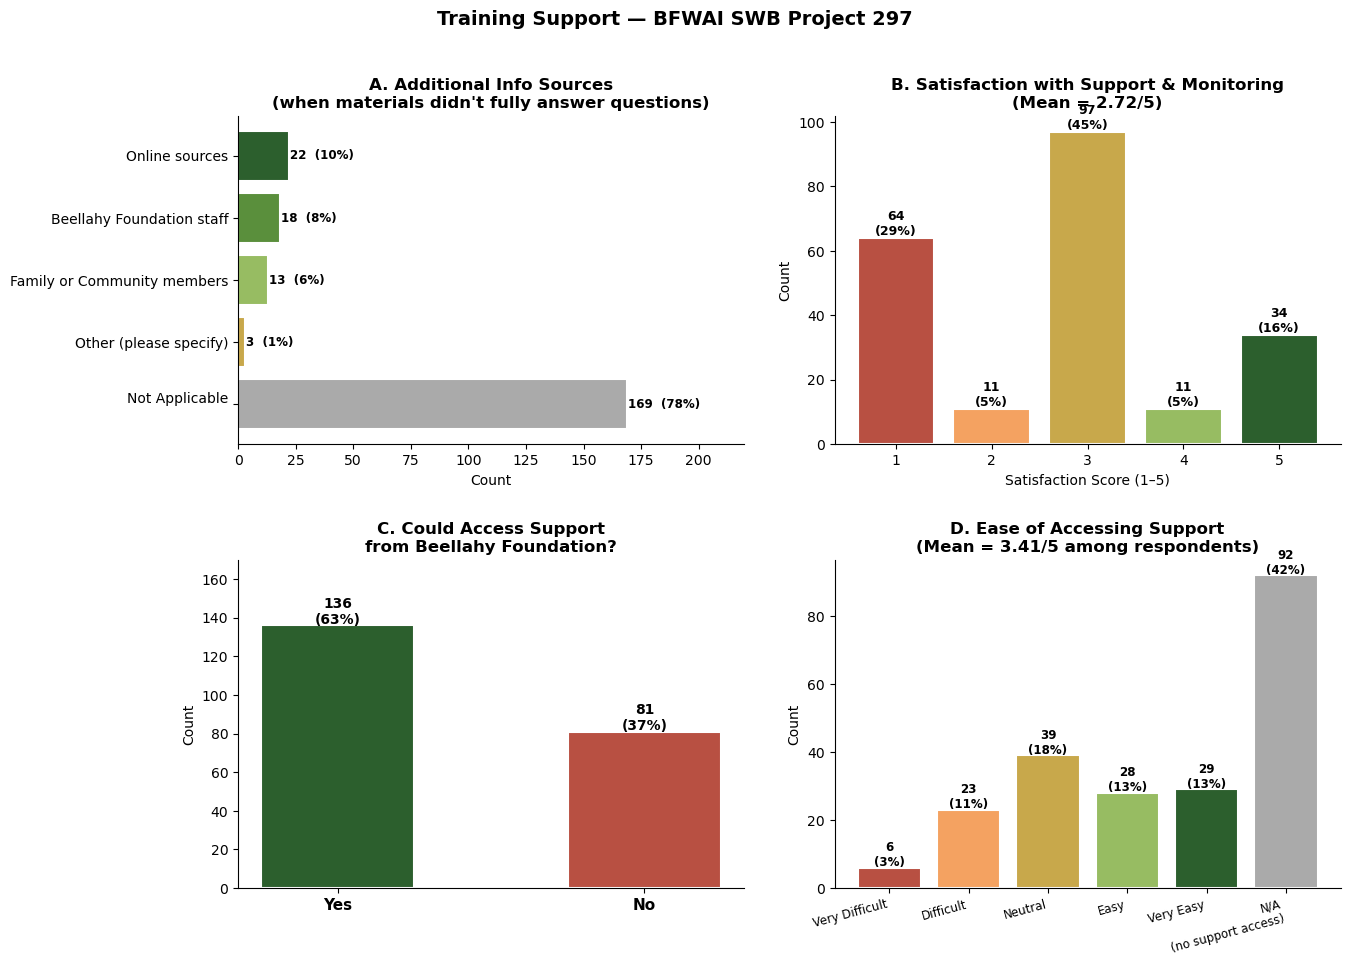

In [24]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.patch.set_facecolor('white')
fig.suptitle("Training Support — BFWAI SWB Project 297",
             fontsize=14, fontweight='bold')

C1="#2C5F2D"; C2="#97BC62"; C3="#C8A84B"; C4="#B85042"; C5="#5A8F3C"; C6="#F4A261"; C7="#AAAAAA"

def set_xlabels(ax, labels, **kwargs):
    ax.set_xticks(range(len(labels)))
    ax.set_xticklabels(labels, **kwargs)

# ── A. Additional Info Sources (multi-select frequency + NaN) ────────────────
ax = axes[0, 0]
info_col = df.columns[12]
n_total = len(df)
n_missing = df[info_col].isna().sum()

info_counts = (
    df[info_col].dropna()
    .astype(str)
    .str.split(r',\s*')
    .explode()
    .str.strip()
    .replace('', pd.NA)
    .dropna()
    .value_counts()
)
# Add NaN as its own category
info_counts_with_nan = pd.concat([
    info_counts,
    pd.Series({'Not Applicable\n': n_missing})
])

bar_colors = [C1, C5, C2, C3, C6][:len(info_counts)] + [C7]
bars = ax.barh(info_counts_with_nan.index[::-1], info_counts_with_nan.values[::-1],
               color=bar_colors[::-1], edgecolor='white', linewidth=1.5)
ax.set_title("A. Additional Info Sources\n(when materials didn't fully answer questions)",
             fontweight='bold')
ax.set_xlabel("Count")
for bar in bars:
    w = bar.get_width()
    if np.isfinite(w) and w > 0:
        ax.text(w + 0.5, bar.get_y() + bar.get_height()/2,
                f'{w:.0f}  ({100*w/n_total:.0f}%)', va='center',
                fontsize=8.5, fontweight='bold')
ax.set_xlim(0, info_counts_with_nan.max() * 1.3)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

# ── B. Satisfaction average ────────────────────────────────────────────────────
ax = axes[0, 1]
sat = pd.to_numeric(df_encoded['satisfaction'], errors='coerce')
sat_counts = sat.value_counts().sort_index()
bars_b = ax.bar(sat_counts.index, sat_counts.values,
                color=[C4,C6,C3,C2,C1], edgecolor='white', linewidth=1.5)
mean_sat = sat.mean()
ax.set_title(f"B. Satisfaction with Support & Monitoring\n(Mean = {mean_sat:.2f}/5)",
             fontweight='bold')
ax.set_xlabel("Satisfaction Score (1–5)")
ax.set_ylabel("Count")
for bar in bars_b:
    h = bar.get_height()
    if h > 0:
        ax.text(bar.get_x() + bar.get_width()/2, h + 1,
                f'{h:.0f}\n({100*h/sat.notna().sum():.0f}%)',
                ha='center', fontsize=9, fontweight='bold')
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

# ── C. Support Access frequency ────────────────────────────────────────────────
ax = axes[1, 0]
access_counts = df_encoded['support_access'].value_counts().reindex(['Yes','No']).fillna(0)
bars_c = ax.bar(range(len(access_counts)), access_counts.values,
                color=[C1, C4], edgecolor='white', linewidth=1.5, width=0.5)
ax.set_xticks([0, 1])
ax.set_xticklabels(['Yes', 'No'], fontsize=11, fontweight='bold')
ax.set_title("C. Could Access Support\nfrom Beellahy Foundation?", fontweight='bold')
ax.set_ylabel("Count")
for bar in bars_c:
    h = bar.get_height()
    if h > 0:
        ax.text(bar.get_x() + bar.get_width()/2, h + 1,
                f'{h:.0f}\n({100*h/access_counts.sum():.0f}%)',
                ha='center', fontsize=10, fontweight='bold')
ax.set_ylim(0, access_counts.max() * 1.25)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

# ── D. Support Ease average (+ NaN as Not Applicable) ─────────────────────────
ax = axes[1, 1]
ease = pd.to_numeric(df_encoded['support_ease'], errors='coerce')
n_ease_missing = ease.isna().sum()

ease_counts = ease.map({1:'Very Difficult',2:'Difficult',3:'Neutral',4:'Easy',5:'Very Easy'}) \
                  .value_counts().reindex(
                      ['Very Difficult','Difficult','Neutral','Easy','Very Easy']
                  ).fillna(0)
ease_counts_with_nan = pd.concat([
    ease_counts,
    pd.Series({'N/A\n(no support access)': n_ease_missing})
])
mean_ease = ease.mean()

bar_colors_d = [C4,C6,C3,C2,C1,C7]
bars_d = ax.bar(range(len(ease_counts_with_nan)), ease_counts_with_nan.values,
                color=bar_colors_d, edgecolor='white', linewidth=1.5)
set_xlabels(ax, ease_counts_with_nan.index, rotation=15, ha='right', fontsize=8.5)
ax.set_title(f"D. Ease of Accessing Support\n(Mean = {mean_ease:.2f}/5 among respondents)",
             fontweight='bold')
ax.set_ylabel("Count")
for bar in bars_d:
    h = bar.get_height()
    if h > 0:
        ax.text(bar.get_x() + bar.get_width()/2, h + 0.5,
                f'{h:.0f}\n({100*h/len(df):.0f}%)',
                ha='center', fontsize=8.5, fontweight='bold')
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.tight_layout(pad=2.5)

# ── Export chart ─────────────────────────────────────────────────────────────
_chart_path = os.path.join(CHART_DIR, 's07_training_support__support_4panel.png')
plt.savefig(_chart_path, dpi=150, bbox_inches='tight', facecolor='white')
print(f'Saved: {_chart_path}')
plt.show()


                            OLS Regression Results                            
Dep. Variable:           satisfaction   R-squared:                       0.098
Model:                            OLS   Adj. R-squared:                  0.084
Method:                 Least Squares   F-statistic:                     7.349
Date:                Wed, 01 Jul 2026   Prob (F-statistic):           0.000106
Time:                        13:47:51   Log-Likelihood:                -346.44
No. Observations:                 208   AIC:                             700.9
Df Residuals:                     204   BIC:                             714.2
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                                                        coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------------------

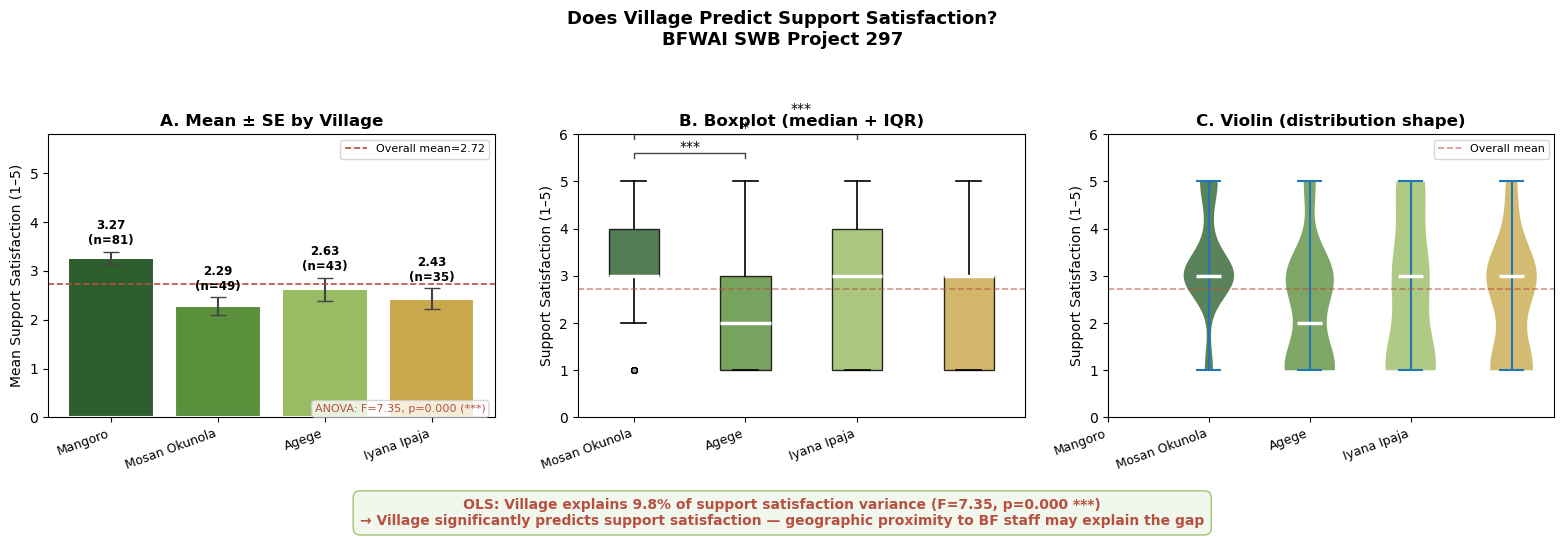

In [25]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from scipy import stats
import statsmodels.formula.api as smf

fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.patch.set_facecolor('white')
fig.suptitle("Does Village Predict Support Satisfaction?\nBFWAI SWB Project 297",
             fontsize=13, fontweight='bold')

C1="#2C5F2D"; C2="#97BC62"; C3="#C8A84B"; C4="#B85042"; C5="#5A8F3C"
village_order  = ['Mangoro', 'Mosan Okunola', 'Agege', 'Iyana Ipaja']
village_colors = [C1, C5, C2, C3]

sat_data = []
for v in village_order:
    d = pd.to_numeric(
        df_encoded[df_encoded['village']==v]['satisfaction'], errors='coerce'
    ).dropna().values.astype(float)
    sat_data.append(d)

def set_xlabels(ax, labels, **kwargs):
    ax.set_xticks(range(len(labels)))
    ax.set_xticklabels(labels, **kwargs)

# ── Panel A: Bar (mean ± SE) ───────────────────────────────────────────────────
ax = axes[0]
means = [d.mean() if len(d) > 0 else 0 for d in sat_data]
ses   = [d.std() / np.sqrt(len(d)) if len(d) > 1 else 0 for d in sat_data]
ns    = [len(d) for d in sat_data]

bars = ax.bar(range(len(village_order)), means, yerr=ses,
              color=village_colors, edgecolor='white', linewidth=1.5,
              capsize=6, error_kw=dict(ecolor='#444', lw=1.5))
overall_mean = pd.to_numeric(df_encoded['satisfaction'], errors='coerce').mean()
ax.axhline(overall_mean, color=C4, linestyle='--', linewidth=1.2,
           label=f"Overall mean={overall_mean:.2f}")
ax.set_ylim(0, 5.8)
ax.set_ylabel("Mean Support Satisfaction (1–5)")
ax.set_title("A. Mean ± SE by Village", fontweight='bold')
set_xlabels(ax, village_order, rotation=20, ha='right', fontsize=9)
ax.legend(fontsize=8)
for i, (m, se, n) in enumerate(zip(means, ses, ns)):
    ax.text(i, m + se + 0.15, f"{m:.2f}\n(n={n})",
            ha='center', fontsize=8.5, fontweight='bold')

valid = [d for d in sat_data if len(d) > 1]
if len(valid) >= 2:
    f, p = stats.f_oneway(*valid)
    sig  = "***" if p<.001 else "**" if p<.01 else "*" if p<.05 else "ns"
    ax.text(0.98, 0.02, f"ANOVA: F={f:.2f}, p={p:.3f} ({sig})",
            transform=ax.transAxes, ha='right', fontsize=8,
            color=C4 if p < 0.05 else '#666',
            bbox=dict(boxstyle='round,pad=0.3', facecolor='white',
                      edgecolor='#CCC', alpha=0.8))

# ── Panel B: Boxplot ──────────────────────────────────────────────────────────
ax = axes[1]
bp = ax.boxplot(sat_data, patch_artist=True,
                medianprops=dict(color='white', linewidth=2.5),
                whiskerprops=dict(linewidth=1.2),
                capprops=dict(linewidth=1.2),
                flierprops=dict(marker='o', markerfacecolor='#AAA',
                                markersize=4, linestyle='none'))
for patch, color in zip(bp['boxes'], village_colors):
    patch.set_facecolor(color); patch.set_alpha(0.82)
set_xlabels(ax, village_order, rotation=20, ha='right', fontsize=9)
ax.set_title("B. Boxplot (median + IQR)", fontweight='bold')
ax.set_ylabel("Support Satisfaction (1–5)")
ax.set_ylim(0, 6)
ax.axhline(overall_mean, color=C4, linestyle='--', linewidth=1.2, alpha=0.6)

from itertools import combinations
sig_pairs = []
for (i, v1), (j, v2) in combinations(enumerate(village_order), 2):
    d1, d2 = sat_data[i], sat_data[j]
    if len(d1) > 1 and len(d2) > 1:
        _, p_mw = stats.mannwhitneyu(d1, d2, alternative='two-sided')
        if p_mw < 0.05:
            sig_pairs.append((i+1, j+1, p_mw))
if sig_pairs:
    y_max = 5.5
    for i1, i2, p_mw in sig_pairs:
        sig = "***" if p_mw<.001 else "**" if p_mw<.01 else "*"
        ax.plot([i1, i1, i2, i2], [y_max, y_max+0.1, y_max+0.1, y_max],
                color='#444', lw=1)
        ax.text((i1+i2)/2, y_max+0.15, sig, ha='center', fontsize=10)
        y_max += 0.4

# ── Panel C: Violin ────────────────────────────────────────────────────────────
ax = axes[2]
valid_data = []
for v, d, c in zip(village_order, sat_data, village_colors):
    clean = d[~np.isnan(d)]
    if len(clean) >= 3:
        valid_data.append((v, clean, c))
vp = ax.violinplot([d for _, d, _ in valid_data], showmedians=True, showmeans=False)
for body, (_, _, color) in zip(vp['bodies'], valid_data):
    body.set_facecolor(color); body.set_alpha(0.78)
vp['cmedians'].set_color('white'); vp['cmedians'].set_linewidth(2.5)
set_xlabels(ax, [v for v, _, _ in valid_data], rotation=20, ha='right', fontsize=9)
ax.set_title("C. Violin (distribution shape)", fontweight='bold')
ax.set_ylabel("Support Satisfaction (1–5)")
ax.set_ylim(0, 6)
ax.axhline(overall_mean, color=C4, linestyle='--', linewidth=1.2,
           alpha=0.6, label="Overall mean")
ax.legend(fontsize=8)

# ── OLS ───────────────────────────────────────────────────────────────────────
ols_df = df_encoded[['satisfaction', 'village']].copy()
ols_df['satisfaction'] = pd.to_numeric(ols_df['satisfaction'], errors='coerce')
ols_df = ols_df.dropna()
ols_df['village'] = pd.Categorical(ols_df['village'], categories=village_order)

model = smf.ols('satisfaction ~ C(village, Treatment("Mangoro"))', data=ols_df).fit()
r2, f_ols, fp = model.rsquared, model.fvalue, model.f_pvalue
sig_ols = "***" if fp<.001 else "**" if fp<.01 else "*" if fp<.05 else "ns"

print(model.summary())

conclusion = (
    f"OLS: Village explains {r2*100:.1f}% of support satisfaction variance "
    f"(F={f_ols:.2f}, p={fp:.3f} {sig_ols})\n"
    + (f"→ Village significantly predicts support satisfaction — geographic proximity to BF staff may explain the gap"
       if fp < 0.05 else
       f"→ No significant village effect — support access difficulty is consistent across all sites, not location-specific")
)
fig.text(0.5, -0.05, conclusion, ha='center', fontsize=10,
         color=C4 if fp < 0.05 else C1, fontweight='bold',
         bbox=dict(boxstyle='round,pad=0.5', facecolor='#F0F7EC',
                   edgecolor=C2, alpha=0.9))

plt.tight_layout(pad=2)

# ── Export chart ─────────────────────────────────────────────────────────────
_chart_path = os.path.join(CHART_DIR, 's07_training_support__village_support_satisfaction_3panel.png')
plt.savefig(_chart_path, dpi=150, bbox_inches='tight', facecolor='white')
print(f'Saved: {_chart_path}')
plt.show()


---
## 8. Training Evaluation — Expectations & Challenges

Examines whether training met participant expectations and whether they encountered
challenges, crossed against village, age, and experience level.

### Key Findings
- **Met expectations strongly predicts satisfaction:** Yes (3.36) vs No (2.25), p<0.001
- **U-shaped expectation gap by experience:** 0% of 7-10 year farmers say training met expectations; beginners (44%) and very experienced (45%) are better served
- **Most experienced farmers (10+ yrs) report highest challenge rate** (45.5%) — likely knowledge-conflict with existing habits
- **Older participants report fewer challenges** (45+: 69% No challenges vs <18: 44% No)
- **Iyana Ipaja** is the weakest site on expectation alignment (42.9% No, 20% Yes)
- **Recommendation:** Three-tier curriculum — beginner (0-3 yrs), intermediate (4-10 yrs), advanced (10+ yrs)


In [26]:
df_training_evaluation.head()

,met_expectations,challenges
0,3,No
1,3,No
2,3,Yes
3,3,No
4,3,No


met_expectations_label
No       76
Yes      73
Maybe    68
Name: count, dtype: int64


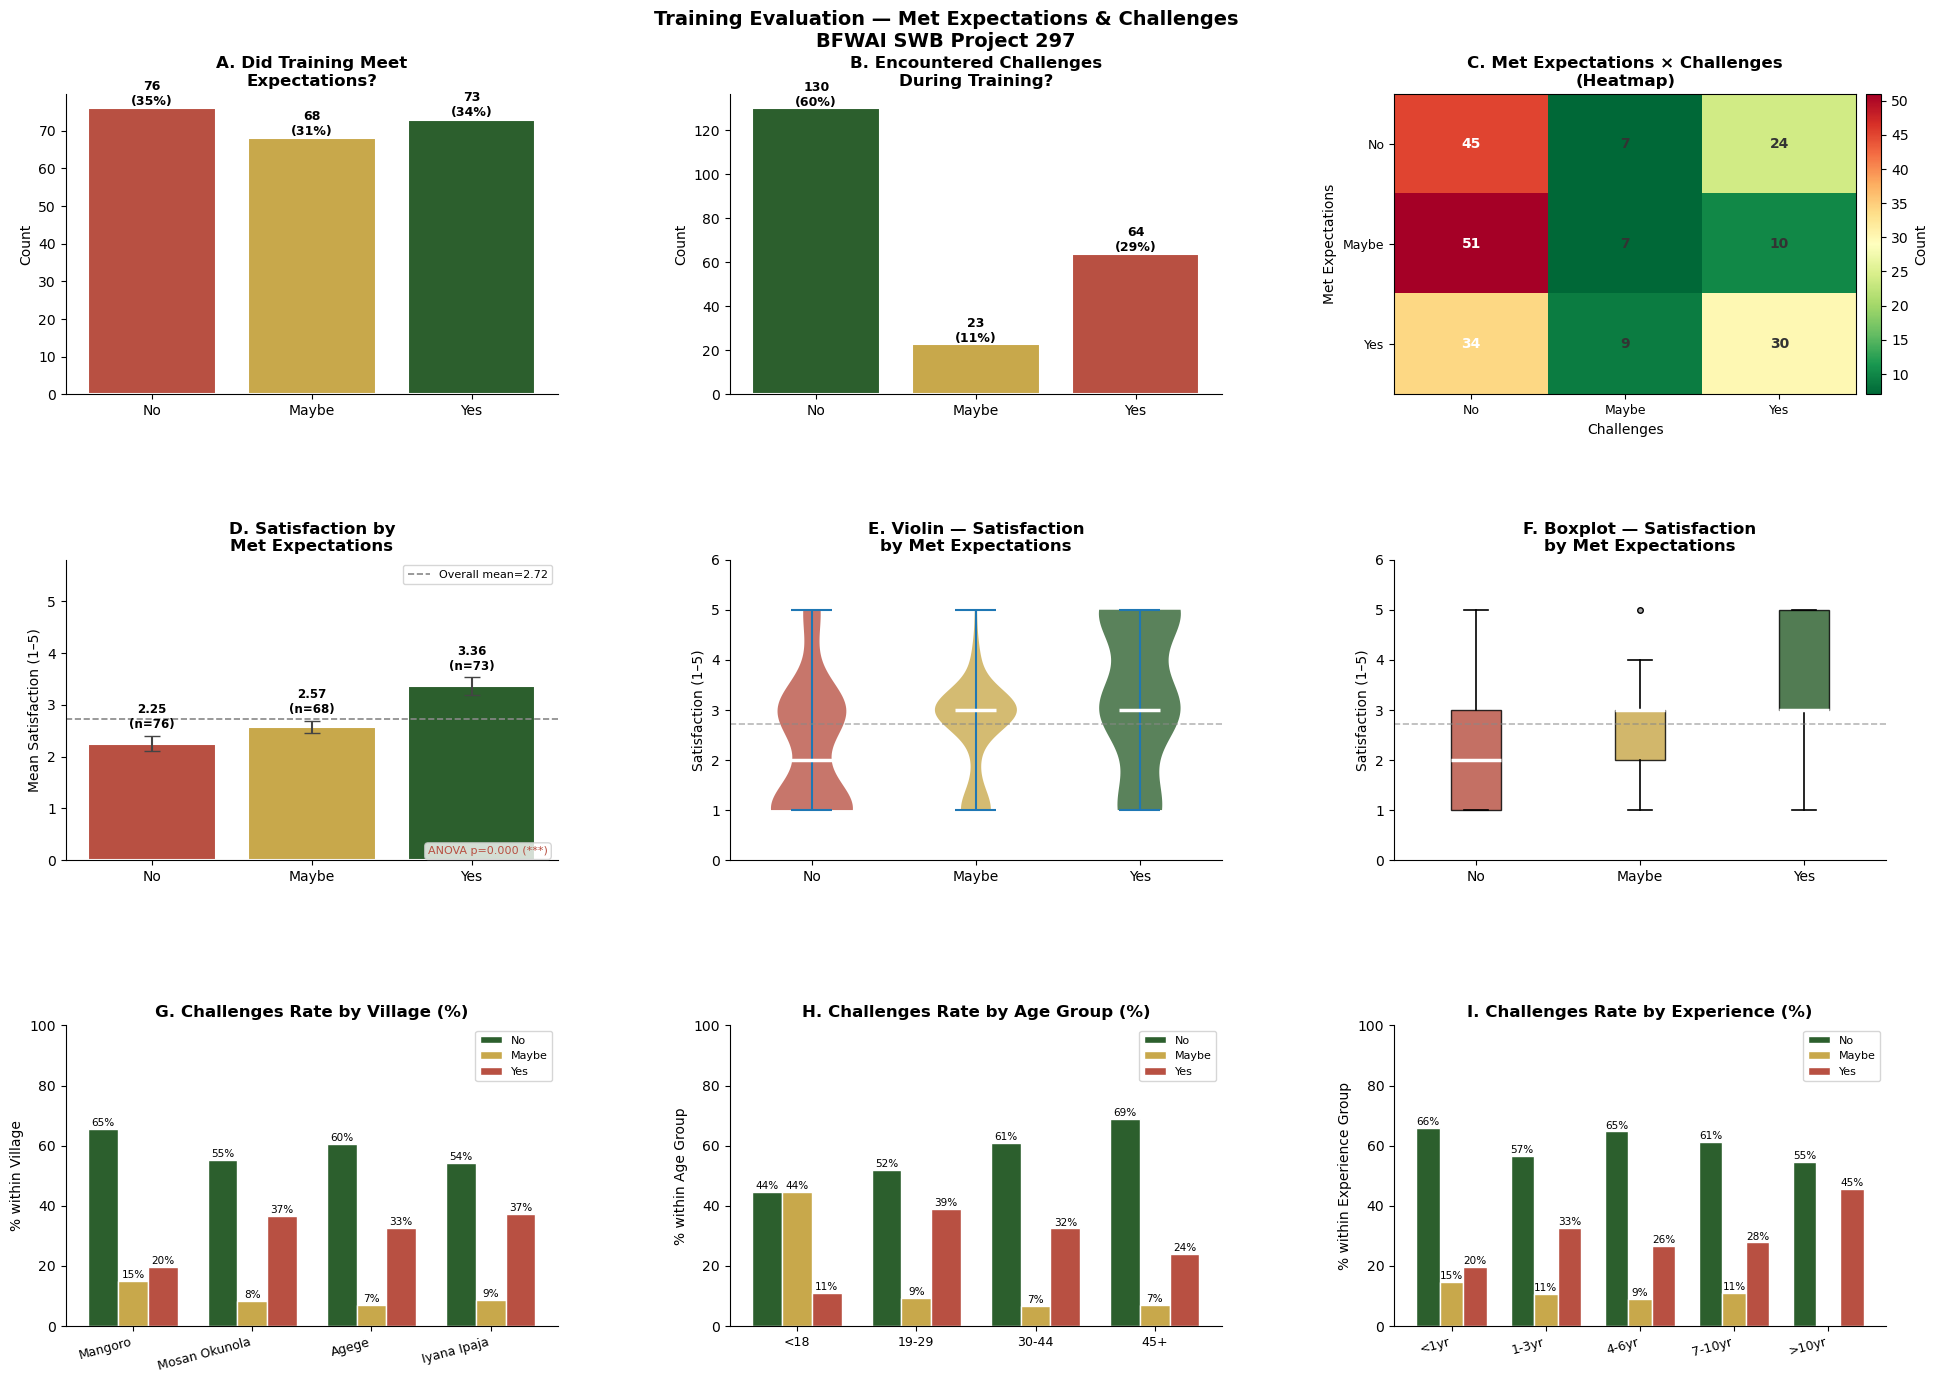

Village × Challenges: Chi2=7.47, p=0.4866 (not significant)
Age Group × Challenges: Chi2=28.36, p=0.0001 (significant)
Experience × Challenges: Chi2=5.40, p=0.7145 (not significant)


In [27]:
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import numpy as np
import pandas as pd
from scipy import stats
# ── Recreate met_expectations_label ──────────────────────────────────────────
met_map_reverse = {1: 'No', 2: 'Maybe', 3: 'Yes'}
df_encoded['met_expectations_label'] = df_encoded['met_expectations'].map(met_map_reverse)

# verify
print(df_encoded['met_expectations_label'].value_counts())
fig = plt.figure(figsize=(20, 14))
fig.patch.set_facecolor('white')
fig.suptitle("Training Evaluation — Met Expectations & Challenges\nBFWAI SWB Project 297",
             fontsize=14, fontweight='bold', y=0.99)

gs = gridspec.GridSpec(3, 3, figure=fig, hspace=0.55, wspace=0.35,
                       left=0.06, right=0.97, top=0.93, bottom=0.05)

C1="#2C5F2D"; C2="#97BC62"; C3="#C8A84B"; C4="#B85042"; C5="#5A8F3C"; C6="#F4A261"

def set_xlabels(ax, labels, **kwargs):
    ax.set_xticks(range(len(labels)))
    ax.set_xticklabels(labels, **kwargs)

village_order = ['Mangoro', 'Mosan Okunola', 'Agege', 'Iyana Ipaja']
age_order     = ['Below 18 years', '19-29 years', '30-44 years', '45+ years']
exp_order     = ['Less than 1 year', '1-3 years', '4-6 years', '7-10 years', 'More than 10 years']
met_order     = ['No', 'Maybe', 'Yes']

# ══════════════════════════════════════════════════════════════════════════════
# ROW 1: Frequency of met_expectations and challenges
# ══════════════════════════════════════════════════════════════════════════════

ax_a = fig.add_subplot(gs[0, 0])
met_counts = df_encoded['met_expectations_label'].value_counts().reindex(met_order).fillna(0)
bars_a = ax_a.bar(range(len(met_counts)), met_counts.values,
                  color=[C4, C3, C1], edgecolor='white', linewidth=1.5)
set_xlabels(ax_a, met_counts.index, fontsize=10)
ax_a.set_title("A. Did Training Meet\nExpectations?", fontweight='bold')
ax_a.set_ylabel("Count")
for bar in bars_a:
    h = bar.get_height()
    if h > 0:
        ax_a.text(bar.get_x() + bar.get_width()/2, h + 1,
                  f'{h:.0f}\n({100*h/met_counts.sum():.0f}%)',
                  ha='center', fontsize=9, fontweight='bold')
ax_a.spines['top'].set_visible(False)
ax_a.spines['right'].set_visible(False)

ax_b = fig.add_subplot(gs[0, 1])
chall_counts = df_encoded['challenges'].value_counts().reindex(['No','Maybe','Yes']).fillna(0)
bars_b = ax_b.bar(range(len(chall_counts)), chall_counts.values,
                  color=[C1, C3, C4], edgecolor='white', linewidth=1.5)
set_xlabels(ax_b, chall_counts.index, fontsize=10)
ax_b.set_title("B. Encountered Challenges\nDuring Training?", fontweight='bold')
ax_b.set_ylabel("Count")
for bar in bars_b:
    h = bar.get_height()
    if h > 0:
        ax_b.text(bar.get_x() + bar.get_width()/2, h + 1,
                  f'{h:.0f}\n({100*h/chall_counts.sum():.0f}%)',
                  ha='center', fontsize=9, fontweight='bold')
ax_b.spines['top'].set_visible(False)
ax_b.spines['right'].set_visible(False)

ax_c = fig.add_subplot(gs[0, 2])
cross_mc = pd.crosstab(df_encoded['met_expectations_label'], df_encoded['challenges'])
cross_mc = cross_mc.reindex(met_order).reindex(columns=['No','Maybe','Yes']).fillna(0)
im = ax_c.imshow(cross_mc.values, cmap='RdYlGn_r', aspect='auto')
set_xlabels(ax_c, cross_mc.columns, fontsize=9)
ax_c.set_yticks(range(len(cross_mc.index)))
ax_c.set_yticklabels(cross_mc.index, fontsize=9)
ax_c.set_xlabel("Challenges")
ax_c.set_ylabel("Met Expectations")
ax_c.set_title("C. Met Expectations × Challenges\n(Heatmap)", fontweight='bold')
plt.colorbar(im, ax=ax_c, fraction=0.04, pad=0.02, label='Count')
for i in range(len(cross_mc.index)):
    for j in range(len(cross_mc.columns)):
        val = int(cross_mc.values[i, j])
        if val > 0:
            ax_c.text(j, i, str(val), ha='center', va='center',
                      fontsize=10, fontweight='bold',
                      color='white' if val > cross_mc.values.max()*0.6 else '#333')

# ══════════════════════════════════════════════════════════════════════════════
# ROW 2: Satisfaction by Met Expectations (bar, box, and a clean table)
# ══════════════════════════════════════════════════════════════════════════════

met_colors = [C4, C3, C1]
sat_by_met = []
for m in met_order:
    d = pd.to_numeric(
        df_encoded[df_encoded['met_expectations_label']==m]['satisfaction'], errors='coerce'
    ).dropna().values.astype(float)
    d = d[~np.isnan(d)]
    sat_by_met.append(d)

ax_d = fig.add_subplot(gs[1, 0])
means = [d.mean() if len(d)>0 else 0 for d in sat_by_met]
ses   = [d.std()/np.sqrt(len(d)) if len(d)>1 else 0 for d in sat_by_met]
ns    = [len(d) for d in sat_by_met]
bars_d = ax_d.bar(range(len(met_order)), means, yerr=ses,
                  color=met_colors, edgecolor='white', linewidth=1.5,
                  capsize=6, error_kw=dict(ecolor='#444', lw=1.5))
overall_mean = pd.to_numeric(df_encoded['satisfaction'], errors='coerce').mean()
ax_d.axhline(overall_mean, color='#888', linestyle='--', linewidth=1.2,
             label=f"Overall mean={overall_mean:.2f}")
set_xlabels(ax_d, met_order, fontsize=10)
ax_d.set_title("D. Satisfaction by\nMet Expectations", fontweight='bold')
ax_d.set_ylabel("Mean Satisfaction (1–5)")
ax_d.set_ylim(0, 5.8)
ax_d.legend(fontsize=8)
for i,(m,se,n) in enumerate(zip(means,ses,ns)):
    ax_d.text(i, m+se+0.15, f"{m:.2f}\n(n={n})", ha='center', fontsize=8.5, fontweight='bold')
valid = [d for d in sat_by_met if len(d) > 1]
if len(valid) >= 2:
    f, p = stats.f_oneway(*valid)
    sig = "***" if p<.001 else "**" if p<.01 else "*" if p<.05 else "ns"
    ax_d.text(0.98, 0.02, f"ANOVA p={p:.3f} ({sig})",
              transform=ax_d.transAxes, ha='right', fontsize=8,
              color=C4 if p<0.05 else '#666',
              bbox=dict(boxstyle='round,pad=0.3', facecolor='white', edgecolor='#CCC', alpha=0.8))
ax_d.spines['top'].set_visible(False)
ax_d.spines['right'].set_visible(False)

# ── E. Violin — fixed positioning ─────────────────────────────────────────────
ax_e = fig.add_subplot(gs[1, 1])
valid_data = [(m, d, c) for m, d, c in zip(met_order, sat_by_met, met_colors) if len(d) >= 3]
positions = [met_order.index(m) + 1 for m, _, _ in valid_data]  # use original index +1

vp = ax_e.violinplot([d for _, d, _ in valid_data], positions=positions,
                     showmedians=True, showmeans=False)
for body, (_, _, color) in zip(vp['bodies'], valid_data):
    body.set_facecolor(color); body.set_alpha(0.78)
vp['cmedians'].set_color('white'); vp['cmedians'].set_linewidth(2.5)
ax_e.set_xticks(range(1, len(met_order)+1))
ax_e.set_xticklabels(met_order, fontsize=10)
ax_e.set_title("E. Violin — Satisfaction\nby Met Expectations", fontweight='bold')
ax_e.set_ylabel("Satisfaction (1–5)")
ax_e.set_ylim(0, 6)
ax_e.set_xlim(0.5, len(met_order)+0.5)
ax_e.axhline(overall_mean, color='#888', linestyle='--', linewidth=1.2, alpha=0.6)
ax_e.spines['top'].set_visible(False)
ax_e.spines['right'].set_visible(False)

# ── F. Boxplot — fixed positioning ────────────────────────────────────────────
ax_f = fig.add_subplot(gs[1, 2])
positions_f = [met_order.index(m) + 1 for m in met_order]
bp = ax_f.boxplot(sat_by_met, positions=positions_f, patch_artist=True,
                  medianprops=dict(color='white', linewidth=2.5),
                  whiskerprops=dict(linewidth=1.2), capprops=dict(linewidth=1.2),
                  flierprops=dict(marker='o', markerfacecolor='#AAA', markersize=4))
for patch, c in zip(bp['boxes'], met_colors):
    patch.set_facecolor(c); patch.set_alpha(0.82)
ax_f.set_xticks(range(1, len(met_order)+1))
ax_f.set_xticklabels(met_order, fontsize=10)
ax_f.set_xlim(0.5, len(met_order)+0.5)
ax_f.set_title("F. Boxplot — Satisfaction\nby Met Expectations", fontweight='bold')
ax_f.set_ylabel("Satisfaction (1–5)")
ax_f.set_ylim(0, 6)
ax_f.axhline(overall_mean, color='#888', linestyle='--', linewidth=1.2, alpha=0.6)
ax_f.spines['top'].set_visible(False)
ax_f.spines['right'].set_visible(False)
# ══════════════════════════════════════════════════════════════════════════════
# ROW 3: Challenges as RATE (%) by village, age, experience
# ══════════════════════════════════════════════════════════════════════════════

df_temp = df_encoded.copy()
w = 0.25

# ── G. Challenges rate by Village ─────────────────────────────────────────────
ax_g = fig.add_subplot(gs[2, 0])
cross_v = pd.crosstab(df_temp['village'], df_temp['challenges'], normalize='index') * 100
cross_v = cross_v.reindex(village_order).reindex(columns=['No','Maybe','Yes']).fillna(0)
x = np.arange(len(village_order))
for i, col in enumerate(['No','Maybe','Yes']):
    if col in cross_v.columns:
        bars = ax_g.bar(x + (i-1)*w, cross_v[col], w,
                        color=[C1,C3,C4][i], edgecolor='white', label=col)
        for bar in bars:
            h = bar.get_height()
            if h > 0:
                ax_g.text(bar.get_x()+bar.get_width()/2, h+1, f'{h:.0f}%',
                          ha='center', fontsize=7.5)
set_xlabels(ax_g, village_order, rotation=15, ha='right', fontsize=9)
ax_g.set_title("G. Challenges Rate by Village (%)", fontweight='bold')
ax_g.set_ylabel("% within Village")
ax_g.set_ylim(0, 100)
ax_g.legend(fontsize=8)
ax_g.spines['top'].set_visible(False)
ax_g.spines['right'].set_visible(False)

# ── H. Challenges rate by Age Group ───────────────────────────────────────────
ax_h = fig.add_subplot(gs[2, 1])
cross_a = pd.crosstab(df_temp['age_group'], df_temp['challenges'], normalize='index') * 100
cross_a = cross_a.reindex(age_order).reindex(columns=['No','Maybe','Yes']).fillna(0)
x2 = np.arange(len(age_order))
for i, col in enumerate(['No','Maybe','Yes']):
    if col in cross_a.columns:
        bars = ax_h.bar(x2 + (i-1)*w, cross_a[col], w,
                        color=[C1,C3,C4][i], edgecolor='white', label=col)
        for bar in bars:
            h = bar.get_height()
            if h > 0:
                ax_h.text(bar.get_x()+bar.get_width()/2, h+1, f'{h:.0f}%',
                          ha='center', fontsize=7.5)
set_xlabels(ax_h, ['<18','19-29','30-44','45+'], fontsize=9)
ax_h.set_title("H. Challenges Rate by Age Group (%)", fontweight='bold')
ax_h.set_ylabel("% within Age Group")
ax_h.set_ylim(0, 100)
ax_h.legend(fontsize=8)
ax_h.spines['top'].set_visible(False)
ax_h.spines['right'].set_visible(False)

# ── I. Challenges rate by Experience ──────────────────────────────────────────
ax_i = fig.add_subplot(gs[2, 2])
cross_e = pd.crosstab(df_temp['farming_exp'], df_temp['challenges'], normalize='index') * 100
cross_e = cross_e.reindex(exp_order).reindex(columns=['No','Maybe','Yes']).fillna(0)
x3 = np.arange(len(exp_order))
for i, col in enumerate(['No','Maybe','Yes']):
    if col in cross_e.columns:
        bars = ax_i.bar(x3 + (i-1)*w, cross_e[col], w,
                        color=[C1,C3,C4][i], edgecolor='white', label=col)
        for bar in bars:
            h = bar.get_height()
            if h > 0:
                ax_i.text(bar.get_x()+bar.get_width()/2, h+1, f'{h:.0f}%',
                          ha='center', fontsize=7.5)
set_xlabels(ax_i, ['<1yr','1-3yr','4-6yr','7-10yr','>10yr'], rotation=15, ha='right', fontsize=9)
ax_i.set_title("I. Challenges Rate by Experience (%)", fontweight='bold')
ax_i.set_ylabel("% within Experience Group")
ax_i.set_ylim(0, 100)
ax_i.legend(fontsize=8)
ax_i.spines['top'].set_visible(False)
ax_i.spines['right'].set_visible(False)



# ── Chi-square tests (on raw counts, not normalised) ──────────────────────────
from scipy.stats import chi2_contingency
raw_v = pd.crosstab(df_temp['village'], df_temp['challenges'])
raw_a = pd.crosstab(df_temp['age_group'], df_temp['challenges'])
raw_e = pd.crosstab(df_temp['farming_exp'], df_temp['challenges'])
for name, cross in [('Village', raw_v), ('Age Group', raw_a), ('Experience', raw_e)]:
    contingency = cross.loc[:, (cross != 0).any(axis=0)]
    if contingency.shape[0] > 1 and contingency.shape[1] > 1:
        chi2, p_chi, dof, _ = chi2_contingency(contingency)
        print(f"{name} × Challenges: Chi2={chi2:.2f}, p={p_chi:.4f} "
              f"({'significant' if p_chi<0.05 else 'not significant'})")

# ── Export chart ─────────────────────────────────────────────────────────────
_chart_path = os.path.join(CHART_DIR, 's08_evaluation__expectations_challenges_9panel.png')
plt.savefig(_chart_path, dpi=150, bbox_inches='tight', facecolor='white')
print(f'Saved: {_chart_path}')
plt.show()


In [28]:
print("=== Met Expectations by Village (%) ===")
print(pd.crosstab(df_encoded['village'], df_encoded['met_expectations_label'],
                   normalize='index').reindex(['Mangoro','Mosan Okunola','Agege','Iyana Ipaja']).round(3) * 100)

print("\n=== Challenges by Age Group (%) — remember Yes=had challenges (bad) ===")
print(pd.crosstab(df_encoded['age_group'], df_encoded['challenges'],
                   normalize='index').reindex(['Below 18 years','19-29 years','30-44 years','45+ years']).round(3) * 100)

print("\n=== Challenges by Experience (%) ===")
print(pd.crosstab(df_encoded['farming_exp'], df_encoded['challenges'],
                   normalize='index').reindex(['Less than 1 year','1-3 years','4-6 years','7-10 years','More than 10 years']).round(3) * 100)

print("\n=== Met Expectations by Experience (%) — to cross-check tiered training idea ===")
print(pd.crosstab(df_encoded['farming_exp'], df_encoded['met_expectations_label'],
                   normalize='index').reindex(['Less than 1 year','1-3 years','4-6 years','7-10 years','More than 10 years']).round(3) * 100)

=== Met Expectations by Village (%) ===
met_expectations_label  Maybe    No   Yes
village                                  
Mangoro                  34.6  23.5  42.0
Mosan Okunola            24.5  38.8  36.7
Agege                    32.6  39.5  27.9
Iyana Ipaja              37.1  42.9  20.0

=== Challenges by Age Group (%) — remember Yes=had challenges (bad) ===
challenges      Maybe    No   Yes
age_group                        
Below 18 years   44.4  44.4  11.1
19-29 years       9.3  51.9  38.9
30-44 years       6.8  60.8  32.4
45+ years         7.0  69.0  23.9

=== Challenges by Experience (%) ===
challenges          Maybe    No   Yes
farming_exp                          
Less than 1 year     14.6  65.9  19.5
1-3 years            10.6  56.6  32.7
4-6 years             8.8  64.7  26.5
7-10 years           11.1  61.1  27.8
More than 10 years    0.0  54.5  45.5

=== Met Expectations by Experience (%) — to cross-check tiered training idea ===
met_expectations_label  Maybe    No   Yes
far

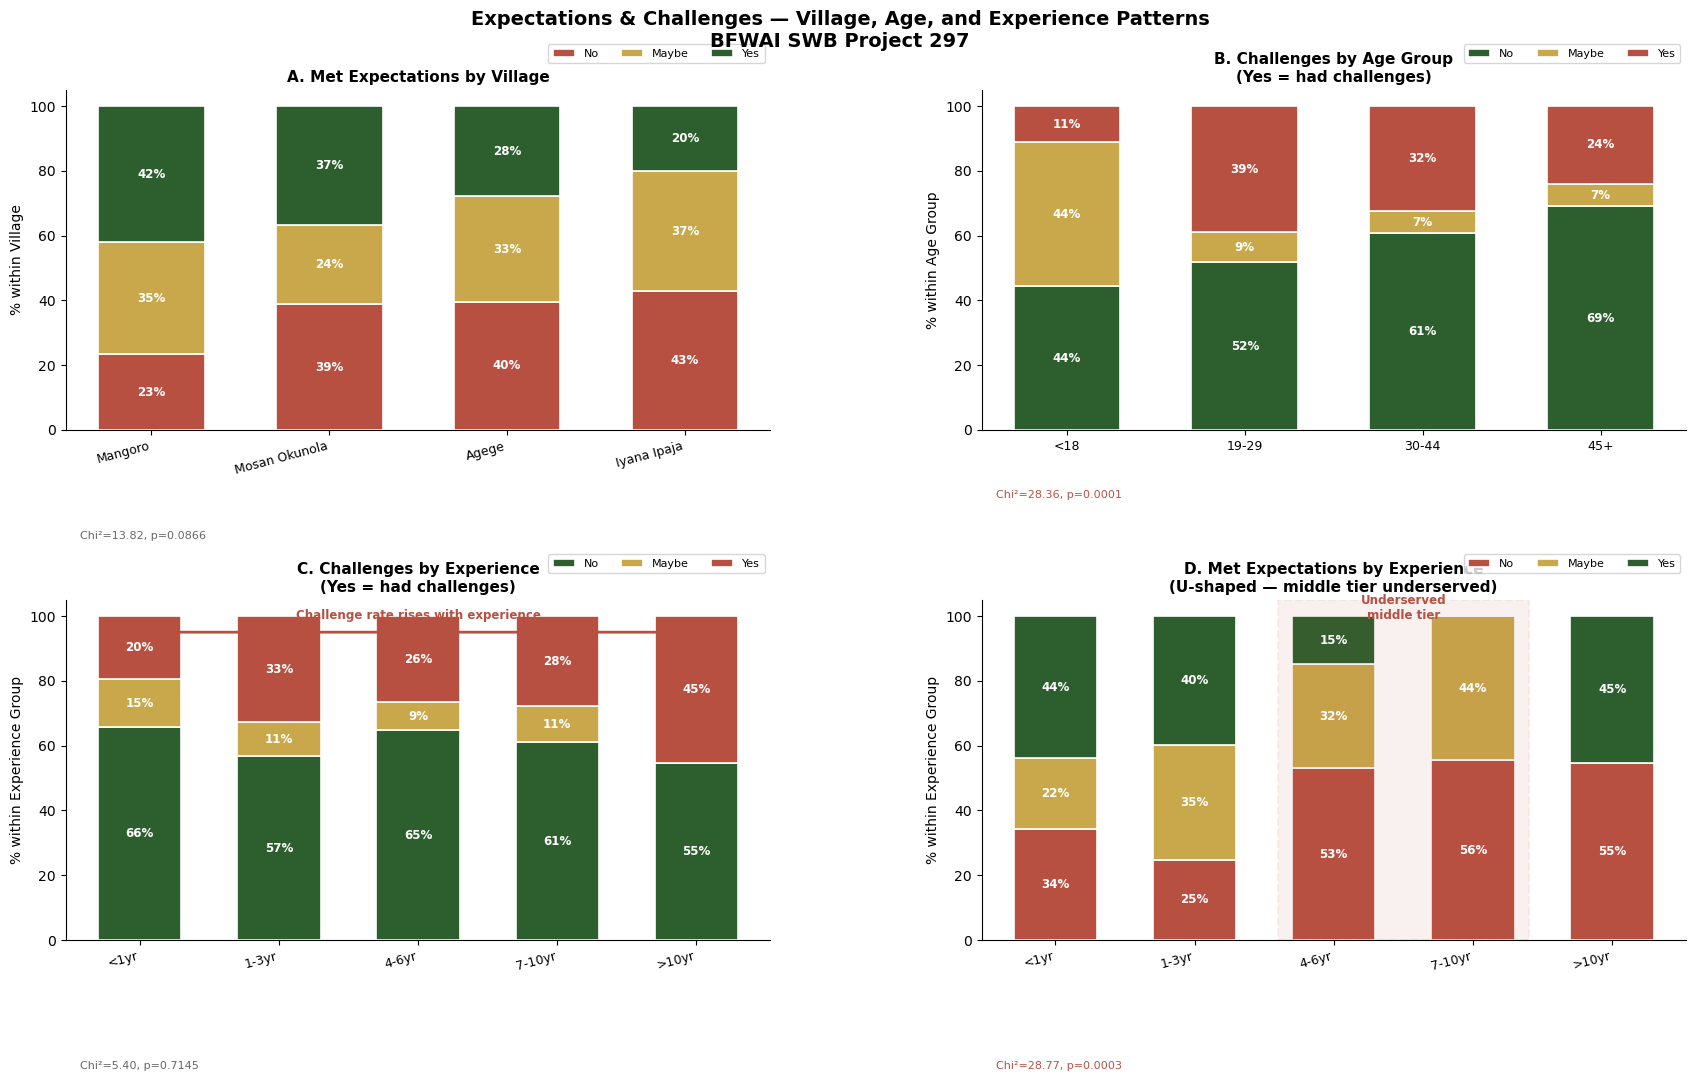

=== Summary ===
A. Village × Met Expectations: not significant (p=0.0866)
B. Age × Challenges: significant (p=0.0001)
C. Experience × Challenges: not significant (p=0.7145)
D. Experience × Met Expectations: significant (p=0.0003)


In [29]:
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import numpy as np
import pandas as pd
from scipy.stats import chi2_contingency

fig = plt.figure(figsize=(18, 10))
fig.patch.set_facecolor('white')
fig.suptitle("Expectations & Challenges — Village, Age, and Experience Patterns\nBFWAI SWB Project 297",
             fontsize=14, fontweight='bold', y=0.99)

gs = gridspec.GridSpec(2, 2, figure=fig, hspace=0.5, wspace=0.3,
                       left=0.07, right=0.97, top=0.91, bottom=0.06)

C1="#2C5F2D"; C2="#97BC62"; C3="#C8A84B"; C4="#B85042"; C5="#5A8F3C"

village_order = ['Mangoro', 'Mosan Okunola', 'Agege', 'Iyana Ipaja']
age_order     = ['Below 18 years', '19-29 years', '30-44 years', '45+ years']
exp_order     = ['Less than 1 year', '1-3 years', '4-6 years', '7-10 years', 'More than 10 years']
met_order     = ['No', 'Maybe', 'Yes']
chall_order   = ['No', 'Maybe', 'Yes']

def stacked_rate_chart(ax, data, order, cats, colors, title, ylabel, xlabels=None, rot=15):
    cross = pd.crosstab(data.index, data.values) if False else None  # placeholder not used
    x = np.arange(len(order))
    bottom = np.zeros(len(order))
    for cat, color in zip(cats, colors):
        vals = data[cat].values if cat in data.columns else np.zeros(len(order))
        ax.bar(x, vals, 0.6, bottom=bottom, color=color,
               edgecolor='white', linewidth=1.2, label=cat)
        for i, (v, b) in enumerate(zip(vals, bottom)):
            if v >= 5:
                ax.text(x[i], b + v/2, f'{v:.0f}%', ha='center', va='center',
                        fontsize=8.5, fontweight='bold', color='white')
        bottom += vals
    ax.set_xticks(x)
    labels = xlabels if xlabels else order
    ax.set_xticklabels(labels, rotation=rot, ha='right' if rot else 'center', fontsize=9)
    ax.set_title(title, fontweight='bold', fontsize=11)
    ax.set_ylabel(ylabel)
    ax.set_ylim(0, 105)
    ax.legend(fontsize=8, loc='upper right', bbox_to_anchor=(1.0, 1.15), ncol=3)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

# ── A. Met Expectations by Village ────────────────────────────────────────────
ax_a = fig.add_subplot(gs[0, 0])
cross_a = pd.crosstab(df_encoded['village'], df_encoded['met_expectations_label'],
                      normalize='index').reindex(village_order).reindex(columns=met_order).fillna(0) * 100
stacked_rate_chart(ax_a, cross_a, village_order, met_order, [C4, C3, C1],
                   "A. Met Expectations by Village", "% within Village", village_order)
chi2_a, p_a, _, _ = chi2_contingency(pd.crosstab(df_encoded['village'], df_encoded['met_expectations_label']))
ax_a.text(0.02, -0.32, f"Chi²={chi2_a:.2f}, p={p_a:.4f}", transform=ax_a.transAxes,
          fontsize=8, color=C4 if p_a<0.05 else '#666')

# ── B. Challenges by Age Group ────────────────────────────────────────────────
ax_b = fig.add_subplot(gs[0, 1])
cross_b = pd.crosstab(df_encoded['age_group'], df_encoded['challenges'],
                      normalize='index').reindex(age_order).reindex(columns=chall_order).fillna(0) * 100
stacked_rate_chart(ax_b, cross_b, age_order, chall_order, [C1, C3, C4],
                   "B. Challenges by Age Group\n(Yes = had challenges)", "% within Age Group",
                   ['<18', '19-29', '30-44', '45+'], rot=0)
chi2_b, p_b, _, _ = chi2_contingency(pd.crosstab(df_encoded['age_group'], df_encoded['challenges']))
ax_b.text(0.02, -0.20, f"Chi²={chi2_b:.2f}, p={p_b:.4f}", transform=ax_b.transAxes,
          fontsize=8, color=C4 if p_b<0.05 else '#666')

# ── C. Challenges by Experience ───────────────────────────────────────────────
ax_c = fig.add_subplot(gs[1, 0])
cross_c = pd.crosstab(df_encoded['farming_exp'], df_encoded['challenges'],
                      normalize='index').reindex(exp_order).reindex(columns=chall_order).fillna(0) * 100
stacked_rate_chart(ax_c, cross_c, exp_order, chall_order, [C1, C3, C4],
                   "C. Challenges by Experience\n(Yes = had challenges)", "% within Experience Group",
                   ['<1yr','1-3yr','4-6yr','7-10yr','>10yr'])
chi2_c, p_c, _, _ = chi2_contingency(pd.crosstab(df_encoded['farming_exp'], df_encoded['challenges']))
ax_c.text(0.02, -0.38, f"Chi²={chi2_c:.2f}, p={p_c:.4f}", transform=ax_c.transAxes,
          fontsize=8, color=C4 if p_c<0.05 else '#666')
# Trend annotation
ax_c.annotate('', xy=(4, 95), xytext=(0, 95),
             arrowprops=dict(arrowstyle='->', color=C4, lw=2))
ax_c.text(2, 99, "Challenge rate rises with experience", ha='center',
          fontsize=8.5, color=C4, fontweight='bold')

# ── D. Met Expectations by Experience (U-shape) ───────────────────────────────
ax_d = fig.add_subplot(gs[1, 1])
cross_d = pd.crosstab(df_encoded['farming_exp'], df_encoded['met_expectations_label'],
                      normalize='index').reindex(exp_order).reindex(columns=met_order).fillna(0) * 100
stacked_rate_chart(ax_d, cross_d, exp_order, met_order, [C4, C3, C1],
                   "D. Met Expectations by Experience\n(U-shaped — middle tier underserved)",
                   "% within Experience Group",
                   ['<1yr','1-3yr','4-6yr','7-10yr','>10yr'])
chi2_d, p_d, _, _ = chi2_contingency(pd.crosstab(df_encoded['farming_exp'], df_encoded['met_expectations_label']))
ax_d.text(0.02, -0.38, f"Chi²={chi2_d:.2f}, p={p_d:.4f}", transform=ax_d.transAxes,
          fontsize=8, color=C4 if p_d<0.05 else '#666')
# Highlight the underserved middle tier
ax_d.add_patch(plt.Rectangle((1.6, 0), 1.8, 105, fill=True,
               facecolor=C4, alpha=0.08, edgecolor=C4, linewidth=1.5, linestyle='--'))
ax_d.text(2.5, 99, "Underserved\nmiddle tier", ha='center',
          fontsize=8.5, color=C4, fontweight='bold')



print("=== Summary ===")
print(f"A. Village × Met Expectations: {'significant' if p_a<0.05 else 'not significant'} (p={p_a:.4f})")
print(f"B. Age × Challenges: {'significant' if p_b<0.05 else 'not significant'} (p={p_b:.4f})")
print(f"C. Experience × Challenges: {'significant' if p_c<0.05 else 'not significant'} (p={p_c:.4f})")
print(f"D. Experience × Met Expectations: {'significant' if p_d<0.05 else 'not significant'} (p={p_d:.4f})")

# ── Export chart ─────────────────────────────────────────────────────────────
_chart_path = os.path.join(CHART_DIR, 's08_evaluation__expectations_challenges_rate_stacked.png')
plt.savefig(_chart_path, dpi=150, bbox_inches='tight', facecolor='white')
print(f'Saved: {_chart_path}')
plt.show()


---
## 9. Farming Impact & Market Access

Examines what participants use container farming for, whether harvests met
household needs, surplus sales, and belief in future viability of the practice.

### Key Findings
- **83.4%** achieve at least partial harvest sufficiency — production is working
- **Only 32.3%** believe container farming is a practical future solution — despite strong production
- **39% of fully-successful farmers still doubt future viability** (chi²=56.04, p<0.001)
- **Inability to sell surplus is the strongest predictor of doubt** — 40% No rate among non-sellers (chi²=8.12, p=0.044)
- Production success and economic sustainability are **structurally decoupled**
- **Market access is the binding constraint**, not farming capability

### Recommendation
Market access training module: (1) Understanding market structure, (2) Pricing & negotiation,
(3) Cooperative selling, (4) Basic farm records. Financial assistance/microloans needed as entry barrier.


In [30]:
df_farming_impact.head()

,farming_purpose,future_of_farming,harvest_sufficiency,sold_surplus
0,"Household food consumption, Income generation",Not sure,"Yes, partially",Yes
1,Household food consumption,Maybe,"Yes, partially",No
2,Household food consumption,No,"Yes, partially",No
3,Household food consumption,Yes,No,No
4,I am not currently using container farming,No,"Yes, fully",Yes


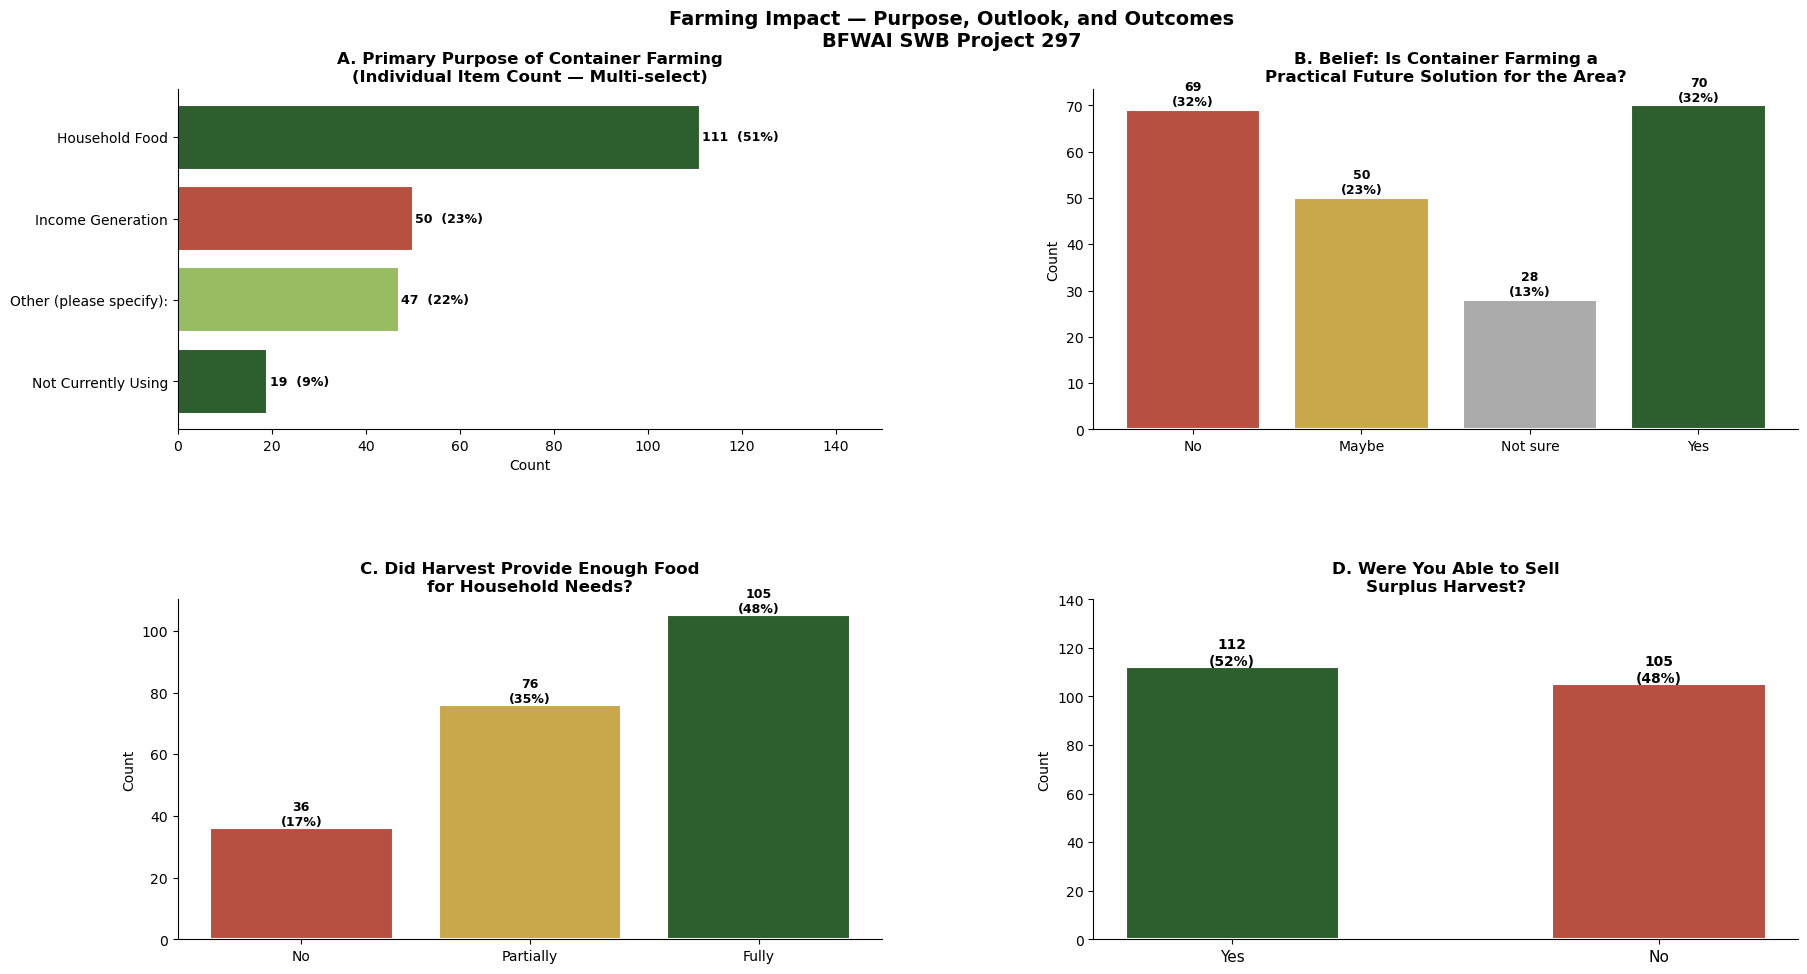

In [31]:
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import numpy as np
import pandas as pd

fig = plt.figure(figsize=(18, 10))
fig.patch.set_facecolor('white')
fig.suptitle("Farming Impact — Purpose, Outlook, and Outcomes\nBFWAI SWB Project 297",
             fontsize=14, fontweight='bold', y=0.99)

gs = gridspec.GridSpec(2, 2, figure=fig, hspace=0.5, wspace=0.3,
                       left=0.07, right=0.97, top=0.91, bottom=0.06)

C1="#2C5F2D"; C2="#97BC62"; C3="#C8A84B"; C4="#B85042"; C5="#5A8F3C"

def set_xlabels(ax, labels, **kwargs):
    ax.set_xticks(range(len(labels)))
    ax.set_xticklabels(labels, **kwargs)

# ── A. Farming Purpose (multi-select split) ───────────────────────────────────
ax_a = fig.add_subplot(gs[0, 0])
purpose_counts = (
    df_encoded['farming_purpose'].dropna()
    .astype(str)
    .str.split(r',\s*')
    .explode()
    .str.strip()
    .replace('', pd.NA)
    .dropna()
    .value_counts()
)
short_labels = {
    'Household food consumption': 'Household Food',
    'Income generation':          'Income Generation',
    'I am not currently using container farming': 'Not Currently Using',
}
purpose_counts.index = [short_labels.get(i, i) for i in purpose_counts.index]
bars_a = ax_a.barh(purpose_counts.index[::-1], purpose_counts.values[::-1],
                   color=[C1,C2,C4][:len(purpose_counts)], edgecolor='white', linewidth=1.5)
ax_a.set_title("A. Primary Purpose of Container Farming\n(Individual Item Count — Multi-select)",
               fontweight='bold')
ax_a.set_xlabel("Count")
for bar in bars_a:
    w = bar.get_width()
    if np.isfinite(w) and w > 0:
        ax_a.text(w + 0.5, bar.get_y() + bar.get_height()/2,
                  f'{w:.0f}  ({100*w/len(df_encoded):.0f}%)',
                  va='center', fontsize=9, fontweight='bold')
ax_a.set_xlim(0, purpose_counts.max() * 1.35)
ax_a.spines['top'].set_visible(False)
ax_a.spines['right'].set_visible(False)

# ── B. Future of Farming belief (histogram) ───────────────────────────────────
ax_b = fig.add_subplot(gs[0, 1])
future_order  = ['No', 'Maybe', 'Not sure', 'Yes']
future_counts = df_encoded['future_of_farming'].value_counts().reindex(future_order).fillna(0)
future_colors = [C4, C3, '#AAAAAA', C1]
bars_b = ax_b.bar(range(len(future_counts)), future_counts.values,
                  color=future_colors, edgecolor='white', linewidth=1.5)
set_xlabels(ax_b, future_order, fontsize=10)
ax_b.set_title("B. Belief: Is Container Farming a\nPractical Future Solution for the Area?",
               fontweight='bold')
ax_b.set_ylabel("Count")
for bar in bars_b:
    h = bar.get_height()
    if h > 0:
        ax_b.text(bar.get_x() + bar.get_width()/2, h + 1,
                  f'{h:.0f}\n({100*h/future_counts.sum():.0f}%)',
                  ha='center', fontsize=9, fontweight='bold')
ax_b.spines['top'].set_visible(False)
ax_b.spines['right'].set_visible(False)

# ── C. Harvest Sufficiency (histogram) ────────────────────────────────────────
ax_c = fig.add_subplot(gs[1, 0])
harvest_order  = ['No', 'Yes, partially', 'Yes, fully']
harvest_counts = df_encoded['harvest_sufficiency'].value_counts().reindex(harvest_order).fillna(0)
bars_c = ax_c.bar(range(len(harvest_counts)), harvest_counts.values,
                  color=[C4, C3, C1], edgecolor='white', linewidth=1.5)
set_xlabels(ax_c, ['No', 'Partially', 'Fully'], fontsize=10)
ax_c.set_title("C. Did Harvest Provide Enough Food\nfor Household Needs?", fontweight='bold')
ax_c.set_ylabel("Count")
for bar in bars_c:
    h = bar.get_height()
    if h > 0:
        ax_c.text(bar.get_x() + bar.get_width()/2, h + 1,
                  f'{h:.0f}\n({100*h/harvest_counts.sum():.0f}%)',
                  ha='center', fontsize=9, fontweight='bold')
ax_c.spines['top'].set_visible(False)
ax_c.spines['right'].set_visible(False)

# ── D. Sold Surplus (histogram) ───────────────────────────────────────────────
ax_d = fig.add_subplot(gs[1, 1])
sold_counts = df_encoded['sold_surplus'].value_counts().reindex(['Yes','No']).fillna(0)
bars_d = ax_d.bar(range(len(sold_counts)), sold_counts.values,
                  color=[C1, C4], edgecolor='white', linewidth=1.5, width=0.5)
set_xlabels(ax_d, ['Yes', 'No'], fontsize=11)
ax_d.set_title("D. Were You Able to Sell\nSurplus Harvest?", fontweight='bold')
ax_d.set_ylabel("Count")
for bar in bars_d:
    h = bar.get_height()
    if h > 0:
        ax_d.text(bar.get_x() + bar.get_width()/2, h + 1,
                  f'{h:.0f}\n({100*h/sold_counts.sum():.0f}%)',
                  ha='center', fontsize=10, fontweight='bold')
ax_d.set_ylim(0, sold_counts.max() * 1.25)
ax_d.spines['top'].set_visible(False)
ax_d.spines['right'].set_visible(False)

# ── Export chart ─────────────────────────────────────────────────────────────
_chart_path = os.path.join(CHART_DIR, 's09_farming_impact__farming_purpose_outlook_harvest_surplus.png')
plt.savefig(_chart_path, dpi=150, bbox_inches='tight', facecolor='white')
print(f'Saved: {_chart_path}')
plt.show()


In [32]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from scipy.stats import chi2_contingency

# ── Exact percentages first ────────────────────────────────────────────────────
print("=== Harvest Sufficiency (%) ===")
print((df_encoded['harvest_sufficiency'].value_counts(normalize=True) * 100).round(1))

print("\n=== Future of Farming Belief (%) ===")
print((df_encoded['future_of_farming'].value_counts(normalize=True) * 100).round(1))

print("\n=== Sold Surplus (%) ===")
print((df_encoded['sold_surplus'].value_counts(normalize=True) * 100).round(1))

# ── Does outcome predict belief? ──────────────────────────────────────────────
print("\n=== Future of Farming belief BY Harvest Sufficiency (%) ===")
cross1 = pd.crosstab(df_encoded['harvest_sufficiency'], df_encoded['future_of_farming'],
                     normalize='index').reindex(['No','Yes, partially','Yes, fully']) * 100
print(cross1.round(1))
chi2_1, p1, _, _ = chi2_contingency(pd.crosstab(df_encoded['harvest_sufficiency'], df_encoded['future_of_farming']))
print(f"Chi2={chi2_1:.2f}, p={p1:.4f}")

print("\n=== Future of Farming belief BY Sold Surplus (%) ===")
cross2 = pd.crosstab(df_encoded['sold_surplus'], df_encoded['future_of_farming'],
                     normalize='index') * 100
print(cross2.round(1))
chi2_2, p2, _, _ = chi2_contingency(pd.crosstab(df_encoded['sold_surplus'], df_encoded['future_of_farming']))
print(f"Chi2={chi2_2:.2f}, p={p2:.4f}")


=== Harvest Sufficiency (%) ===
harvest_sufficiency
Yes, fully        48.4
Yes, partially    35.0
No                16.6
Name: proportion, dtype: float64

=== Future of Farming Belief (%) ===
future_of_farming
Yes         32.3
No          31.8
Maybe       23.0
Not sure    12.9
Name: proportion, dtype: float64

=== Sold Surplus (%) ===
sold_surplus
Yes    51.6
No     48.4
Name: proportion, dtype: float64

=== Future of Farming belief BY Harvest Sufficiency (%) ===
future_of_farming    Maybe    No  Not sure   Yes
harvest_sufficiency                             
No                    25.0  27.8      30.6  16.7
Yes, partially        43.4  23.7      14.5  18.4
Yes, fully             7.6  39.0       5.7  47.6
Chi2=56.04, p=0.0000

=== Future of Farming belief BY Sold Surplus (%) ===
future_of_farming  Maybe    No  Not sure   Yes
sold_surplus                                  
No                  20.0  40.0       8.6  31.4
Yes                 25.9  24.1      17.0  33.0
Chi2=8.12, p=0.0435


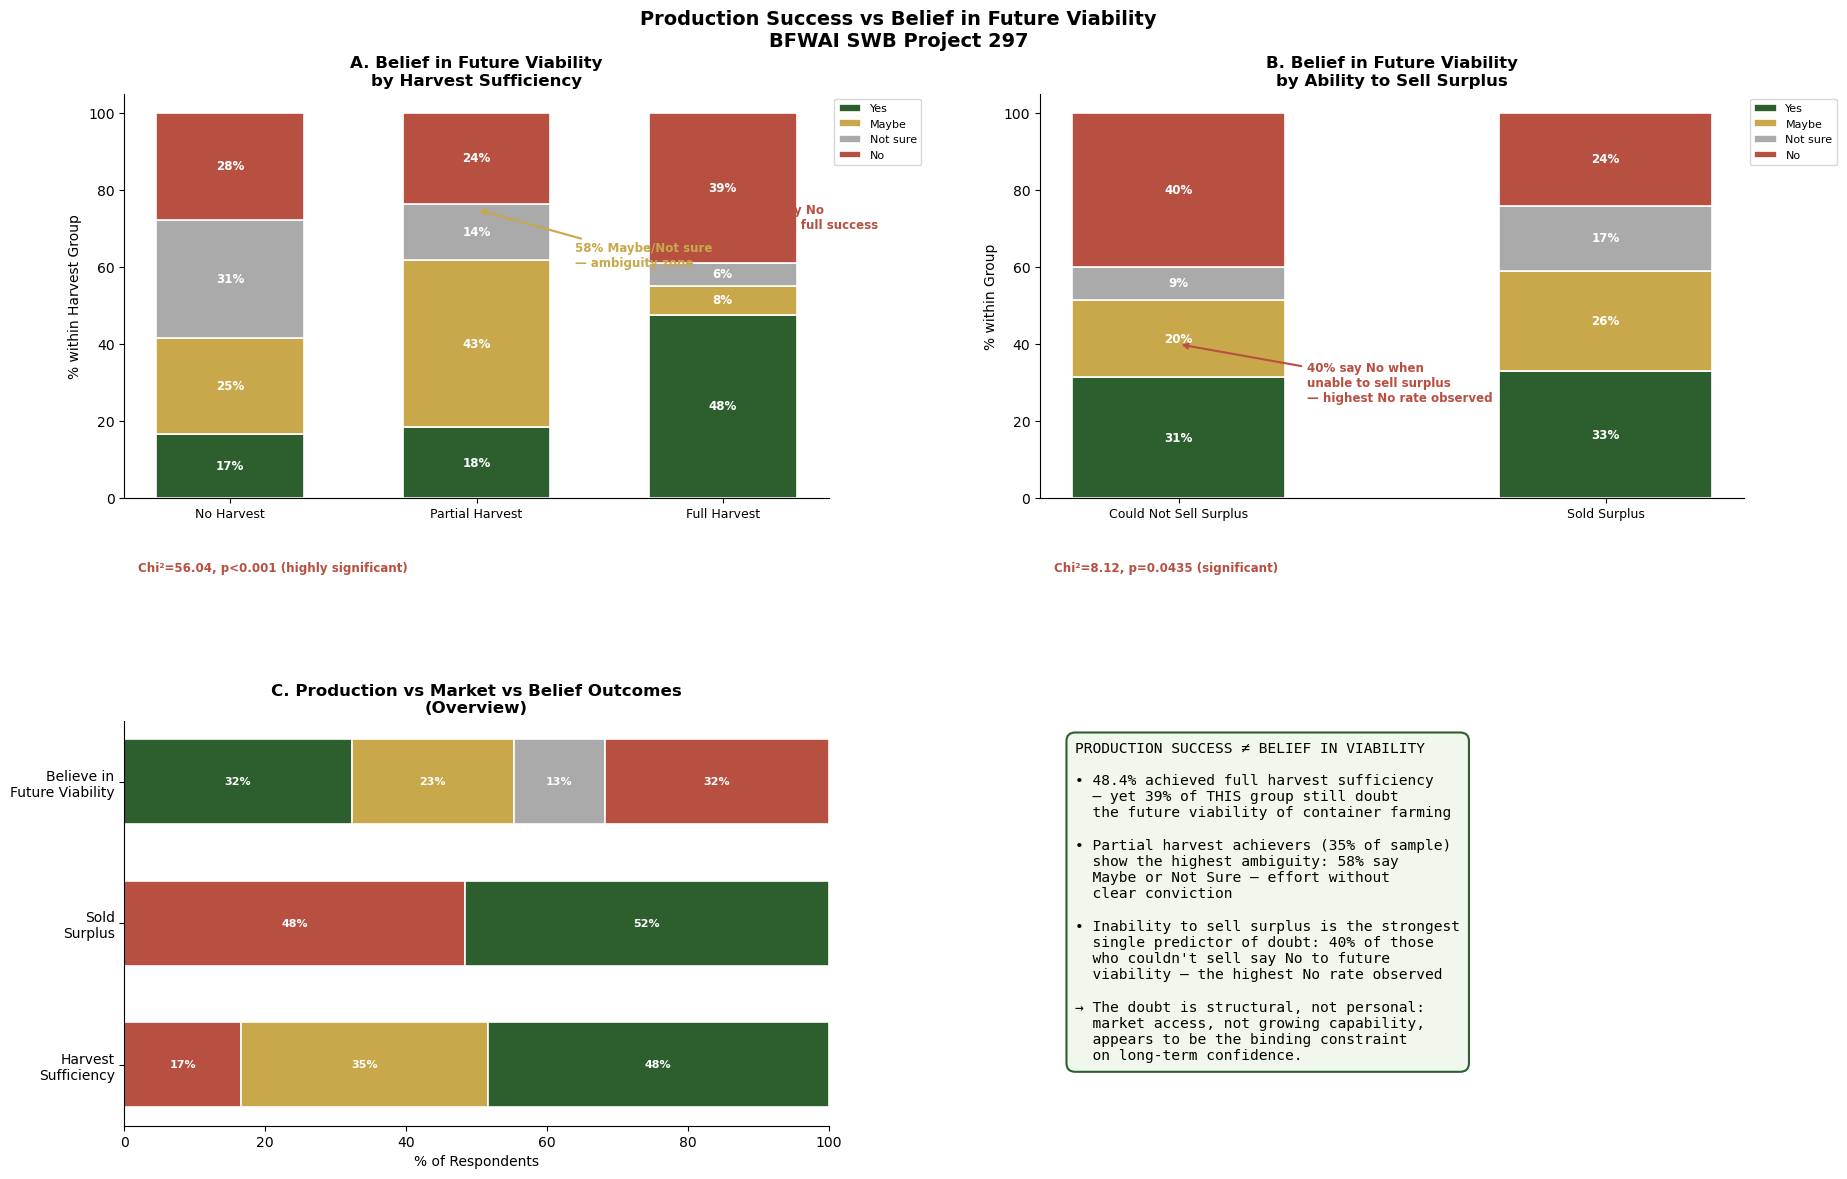

In [33]:
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import numpy as np
import pandas as pd
from scipy.stats import chi2_contingency

fig = plt.figure(figsize=(18, 12))
fig.patch.set_facecolor('white')
fig.suptitle("Production Success vs Belief in Future Viability\nBFWAI SWB Project 297",
             fontsize=14, fontweight='bold', y=0.99)

gs = gridspec.GridSpec(2, 2, figure=fig, hspace=0.55, wspace=0.3,
                       left=0.07, right=0.97, top=0.92, bottom=0.06)

C1="#2C5F2D"; C2="#97BC62"; C3="#C8A84B"; C4="#B85042"; C5="#AAAAAA"

future_order = ['Yes', 'Maybe', 'Not sure', 'No']
future_colors = [C1, C3, C5, C4]

def set_xlabels(ax, labels, **kwargs):
    ax.set_xticks(range(len(labels)))
    ax.set_xticklabels(labels, **kwargs)

# ── A. Future belief by Harvest Sufficiency (100% stacked) ───────────────────
ax_a = fig.add_subplot(gs[0, 0])
harvest_order = ['No', 'Yes, partially', 'Yes, fully']
cross1 = pd.crosstab(df_encoded['harvest_sufficiency'], df_encoded['future_of_farming'],
                     normalize='index').reindex(harvest_order).reindex(columns=future_order).fillna(0) * 100
x = np.arange(len(harvest_order))
bottom = np.zeros(len(harvest_order))
for cat, color in zip(future_order, future_colors):
    vals = cross1[cat].values
    ax_a.bar(x, vals, 0.6, bottom=bottom, color=color, edgecolor='white',
             linewidth=1.2, label=cat)
    for i, (v, b) in enumerate(zip(vals, bottom)):
        if v >= 5:
            ax_a.text(x[i], b + v/2, f'{v:.0f}%', ha='center', va='center',
                      fontsize=8.5, fontweight='bold', color='white')
    bottom += vals
set_xlabels(ax_a, ['No Harvest', 'Partial Harvest', 'Full Harvest'], fontsize=9)
ax_a.set_title("A. Belief in Future Viability\nby Harvest Sufficiency", fontweight='bold')
ax_a.set_ylabel("% within Harvest Group")
ax_a.set_ylim(0, 105)
ax_a.legend(fontsize=8, loc='upper left', bbox_to_anchor=(1.0, 1.0))
chi2_1, p1, _, _ = chi2_contingency(pd.crosstab(df_encoded['harvest_sufficiency'], df_encoded['future_of_farming']))
ax_a.text(0.02, -0.18, f"Chi²={chi2_1:.2f}, p<0.001 (highly significant)",
          transform=ax_a.transAxes, fontsize=8.5, color=C4, fontweight='bold')
ax_a.spines['top'].set_visible(False)
ax_a.spines['right'].set_visible(False)

# Highlight the "stuck in ambiguity" partial harvest group
ax_a.annotate('58% Maybe/Not sure\n— ambiguity zone', xy=(1, 75), xytext=(1.4, 60),
             fontsize=8.5, color=C3, fontweight='bold', ha='left',
             arrowprops=dict(arrowstyle='->', color=C3, lw=1.5))

# Highlight the surprising "No despite success" finding
ax_a.annotate('39% say No\ndespite full success', xy=(2, 90), xytext=(2.1, 70),
             fontsize=8.5, color=C4, fontweight='bold', ha='left',
             arrowprops=dict(arrowstyle='->', color=C4, lw=1.5))

# ── B. Future belief by Sold Surplus (100% stacked) ───────────────────────────
ax_b = fig.add_subplot(gs[0, 1])
cross2 = pd.crosstab(df_encoded['sold_surplus'], df_encoded['future_of_farming'],
                     normalize='index').reindex(['No','Yes']).reindex(columns=future_order).fillna(0) * 100
x2 = np.arange(2)
bottom2 = np.zeros(2)
for cat, color in zip(future_order, future_colors):
    vals = cross2[cat].values
    ax_b.bar(x2, vals, 0.5, bottom=bottom2, color=color, edgecolor='white',
             linewidth=1.2, label=cat)
    for i, (v, b) in enumerate(zip(vals, bottom2)):
        if v >= 5:
            ax_b.text(x2[i], b + v/2, f'{v:.0f}%', ha='center', va='center',
                      fontsize=8.5, fontweight='bold', color='white')
    bottom2 += vals
set_xlabels(ax_b, ['Could Not Sell Surplus', 'Sold Surplus'], fontsize=9)
ax_b.set_title("B. Belief in Future Viability\nby Ability to Sell Surplus", fontweight='bold')
ax_b.set_ylabel("% within Group")
ax_b.set_ylim(0, 105)
ax_b.legend(fontsize=8, loc='upper left', bbox_to_anchor=(1.0, 1.0))
chi2_2, p2, _, _ = chi2_contingency(pd.crosstab(df_encoded['sold_surplus'], df_encoded['future_of_farming']))
ax_b.text(0.02, -0.18, f"Chi²={chi2_2:.2f}, p={p2:.4f} (significant)",
          transform=ax_b.transAxes, fontsize=8.5, color=C4, fontweight='bold')
ax_b.spines['top'].set_visible(False)
ax_b.spines['right'].set_visible(False)

ax_b.annotate('40% say No when\nunable to sell surplus\n— highest No rate observed',
             xy=(0, 40), xytext=(0.3, 25),
             fontsize=8.5, color=C4, fontweight='bold', ha='left',
             arrowprops=dict(arrowstyle='->', color=C4, lw=1.5))

# ── C. Overview: three outcome distributions side by side ────────────────────
ax_c = fig.add_subplot(gs[1, 0])
harvest_pct = (df_encoded['harvest_sufficiency'].value_counts(normalize=True)*100).reindex(harvest_order)
sold_pct    = (df_encoded['sold_surplus'].value_counts(normalize=True)*100).reindex(['No','Yes'])
future_pct  = (df_encoded['future_of_farming'].value_counts(normalize=True)*100).reindex(future_order)

groups = [
    ('Harvest\nSufficiency', harvest_pct, ['No', 'Partial', 'Full'], [C4, C3, C1]),
    ('Sold\nSurplus', sold_pct, ['No', 'Yes'], [C4, C1]),
    ('Believe in\nFuture Viability', future_pct, ['Yes', 'Maybe', 'Not sure', 'No'], future_colors),
]
y_pos = 0
yticks, yticklabels = [], []
for label, pct, cats, colors in groups:
    left = 0
    for cat, color in zip(cats, colors):
        val = pct.get(cat if cat not in ['Partial','Full'] else
                      ('Yes, partially' if cat=='Partial' else 'Yes, fully'), 0)
        ax_c.barh(y_pos, val, left=left, color=color, edgecolor='white',
                  linewidth=1.2, height=0.6)
        if val >= 5:
            ax_c.text(left + val/2, y_pos, f'{val:.0f}%', ha='center', va='center',
                      fontsize=8, fontweight='bold', color='white')
        left += val
    yticks.append(y_pos)
    yticklabels.append(label)
    y_pos += 1
ax_c.set_yticks(yticks)
ax_c.set_yticklabels(yticklabels, fontsize=10)
ax_c.set_xlim(0, 100)
ax_c.set_xlabel("% of Respondents")
ax_c.set_title("C. Production vs Market vs Belief Outcomes\n(Overview)", fontweight='bold')
ax_c.spines['top'].set_visible(False)
ax_c.spines['right'].set_visible(False)

# ── D. Key insight summary table ──────────────────────────────────────────────
ax_d = fig.add_subplot(gs[1, 1])
ax_d.axis('off')
insight_text = (
    "PRODUCTION SUCCESS ≠ BELIEF IN VIABILITY\n\n"
    "• 48.4% achieved full harvest sufficiency\n"
    "  — yet 39% of THIS group still doubt\n"
    "  the future viability of container farming\n\n"
    "• Partial harvest achievers (35% of sample)\n"
    "  show the highest ambiguity: 58% say\n"
    "  Maybe or Not Sure — effort without\n"
    "  clear conviction\n\n"
    "• Inability to sell surplus is the strongest\n"
    "  single predictor of doubt: 40% of those\n"
    "  who couldn't sell say No to future\n"
    "  viability — the highest No rate observed\n\n"
    "→ The doubt is structural, not personal:\n"
    "  market access, not growing capability,\n"
    "  appears to be the binding constraint\n"
    "  on long-term confidence."
)
ax_d.text(0.05, 0.95, insight_text, transform=ax_d.transAxes,
          fontsize=10.5, verticalalignment='top', fontfamily='monospace',
          bbox=dict(boxstyle='round,pad=0.6', facecolor='#F0F7EC',
                    edgecolor=C1, linewidth=1.5))

# ── Export chart ─────────────────────────────────────────────────────────────
_chart_path = os.path.join(CHART_DIR, 's09_farming_impact__production_vs_viability_3panel.png')
plt.savefig(_chart_path, dpi=150, bbox_inches='tight', facecolor='white')
print(f'Saved: {_chart_path}')
plt.show()


---
## 10. Future Outlook & Support Needs

Examines knowledge application rate, training pace adequacy, future training
interest, and the specific support services participants want going forward.

### Key Findings
- **Knowledge application mean: ~3.09/5** — moderate; gap between learning (3.75) and doing (3.09)
- **60% rate training pace as Adequate** — but question cannot distinguish "too fast" from "too slow"
- **Only 55% confirm intent to return** for future training — lower than expected given high learning gains
- **Financial assistance/microloans (45%)** is the #1 requested support — capital is the entry barrier
- Support needs form a **sequential pathway:** capital → advanced training → market access → community structures
- Survey instrument is weak on *why* participants don't apply or don't return — new questions proposed


In [34]:
df_future_outlook.head()

,knowledge_applied,training_pace,future_training_interest
0,4,3,Yes
1,4,3,Yes
2,3,2,Yes
3,4,3,Yes
4,4,3,Yes


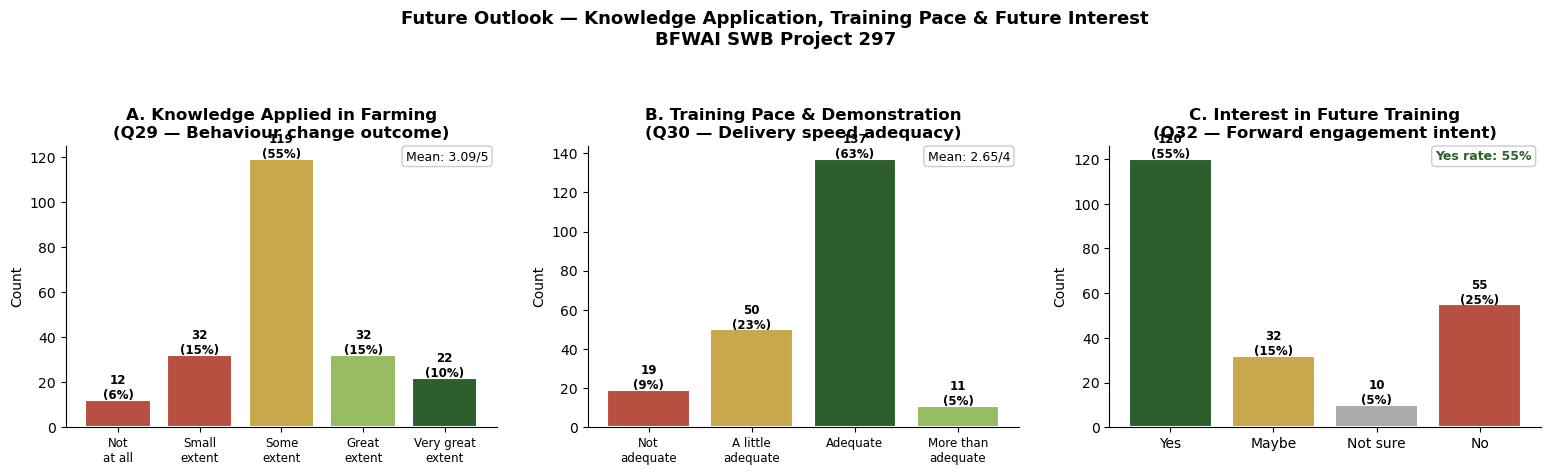

=== Knowledge Applied ===
knowledge_applied
Not at all                 12
To a small extent          32
To some extent            119
To a great extent          32
To a very great extent     22
Mean: 3.09/5

=== Training Pace ===
training_pace
Not adequate           19
A little adequate      50
Adequate              137
More than adequate     11
Mean: 2.65/4

=== Future Training Interest ===
future_training_interest
Yes         120
Maybe        32
Not sure     10
No           55


In [35]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.patch.set_facecolor('white')
fig.suptitle("Future Outlook — Knowledge Application, Training Pace & Future Interest\nBFWAI SWB Project 297",
             fontsize=13, fontweight='bold')

C1="#2C5F2D"; C2="#97BC62"; C3="#C8A84B"; C4="#B85042"; C5="#5A8F3C"

def set_xlabels(ax, labels, **kwargs):
    ax.set_xticks(range(len(labels)))
    ax.set_xticklabels(labels, **kwargs)

# ── A. Knowledge Applied ──────────────────────────────────────────────────────
ax = axes[0]
app_order = ['Not at all', 'To a small extent', 'To some extent',
             'To a great extent', 'To a very great extent']
app_counts = df_encoded['knowledge_applied'].map({
    1: 'Not at all', 2: 'To a small extent', 3: 'To some extent',
    4: 'To a great extent', 5: 'To a very great extent'
}).value_counts().reindex(app_order).fillna(0)

bars_a = ax.bar(range(len(app_order)), app_counts.values,
                color=[C4, C4, C3, C2, C1], edgecolor='white', linewidth=1.5)
set_xlabels(ax, ['Not\nat all', 'Small\nextent', 'Some\nextent',
                  'Great\nextent', 'Very great\nextent'], fontsize=8.5)
ax.set_title("A. Knowledge Applied in Farming\n(Q29 — Behaviour change outcome)",
             fontweight='bold')
ax.set_ylabel("Count")
mean_app = pd.to_numeric(df_encoded['knowledge_applied'], errors='coerce').mean()
ax.text(0.98, 0.95, f"Mean: {mean_app:.2f}/5",
        transform=ax.transAxes, ha='right', fontsize=9,
        bbox=dict(boxstyle='round,pad=0.3', facecolor='white', edgecolor='#CCC'))
for bar in bars_a:
    h = bar.get_height()
    if h > 0:
        ax.text(bar.get_x() + bar.get_width()/2, h + 0.5,
                f'{h:.0f}\n({100*h/app_counts.sum():.0f}%)',
                ha='center', fontsize=8.5, fontweight='bold')
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

# ── B. Training Pace ──────────────────────────────────────────────────────────
ax = axes[1]
pace_order = ['Not adequate', 'A little adequate', 'Adequate', 'More than adequate']
pace_counts = df_encoded['training_pace'].map({
    1: 'Not adequate', 2: 'A little adequate', 3: 'Adequate', 4: 'More than adequate'
}).value_counts().reindex(pace_order).fillna(0)

bars_b = ax.bar(range(len(pace_order)), pace_counts.values,
                color=[C4, C3, C1, C2], edgecolor='white', linewidth=1.5)
set_xlabels(ax, ['Not\nadequate', 'A little\nadequate', 'Adequate', 'More than\nadequate'],
            fontsize=8.5)
ax.set_title("B. Training Pace & Demonstration\n(Q30 — Delivery speed adequacy)",
             fontweight='bold')
ax.set_ylabel("Count")
mean_pace = pd.to_numeric(df_encoded['training_pace'], errors='coerce').mean()
ax.text(0.98, 0.95, f"Mean: {mean_pace:.2f}/4",
        transform=ax.transAxes, ha='right', fontsize=9,
        bbox=dict(boxstyle='round,pad=0.3', facecolor='white', edgecolor='#CCC'))
for bar in bars_b:
    h = bar.get_height()
    if h > 0:
        ax.text(bar.get_x() + bar.get_width()/2, h + 0.5,
                f'{h:.0f}\n({100*h/pace_counts.sum():.0f}%)',
                ha='center', fontsize=8.5, fontweight='bold')
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

# ── C. Future Training Interest ───────────────────────────────────────────────
ax = axes[2]
future_order  = ['Yes', 'Maybe', 'Not sure', 'No']
future_counts = df_encoded['future_training_interest'].value_counts().reindex(future_order).fillna(0)
future_colors = [C1, C3, '#AAAAAA', C4]

bars_c = ax.bar(range(len(future_order)), future_counts.values,
                color=future_colors, edgecolor='white', linewidth=1.5)
set_xlabels(ax, future_order, fontsize=10)
ax.set_title("C. Interest in Future Training\n(Q32 — Forward engagement intent)",
             fontweight='bold')
ax.set_ylabel("Count")
yes_pct = 100 * future_counts.get('Yes', 0) / future_counts.sum()
ax.text(0.98, 0.95, f"Yes rate: {yes_pct:.0f}%",
        transform=ax.transAxes, ha='right', fontsize=9, color=C1, fontweight='bold',
        bbox=dict(boxstyle='round,pad=0.3', facecolor='white', edgecolor='#CCC'))
for bar in bars_c:
    h = bar.get_height()
    if h > 0:
        ax.text(bar.get_x() + bar.get_width()/2, h + 0.5,
                f'{h:.0f}\n({100*h/future_counts.sum():.0f}%)',
                ha='center', fontsize=8.5, fontweight='bold')
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.tight_layout(pad=2.5)


# ── Summary ───────────────────────────────────────────────────────────────────
print("=== Knowledge Applied ===")
print(app_counts.to_string())
print(f"Mean: {mean_app:.2f}/5")
print("\n=== Training Pace ===")
print(pace_counts.to_string())
print(f"Mean: {mean_pace:.2f}/4")
print("\n=== Future Training Interest ===")
print(future_counts.to_string())

# ── Export chart ─────────────────────────────────────────────────────────────
_chart_path = os.path.join(CHART_DIR, 's10_future_outlook__knowledge_applied_pace_interest.png')
plt.savefig(_chart_path, dpi=150, bbox_inches='tight', facecolor='white')
print(f'Saved: {_chart_path}')
plt.show()


In [36]:
df_future_support.head()

,future_support
0,"More advanced training, Access to markets, Fin..."
1,"More advanced training, Financial assistance/m..."
2,"Additional farming materials, Loan farmlands"
3,"More advanced training, Financial assistance/m..."
4,"More advanced training, Access to markets, Fin..."


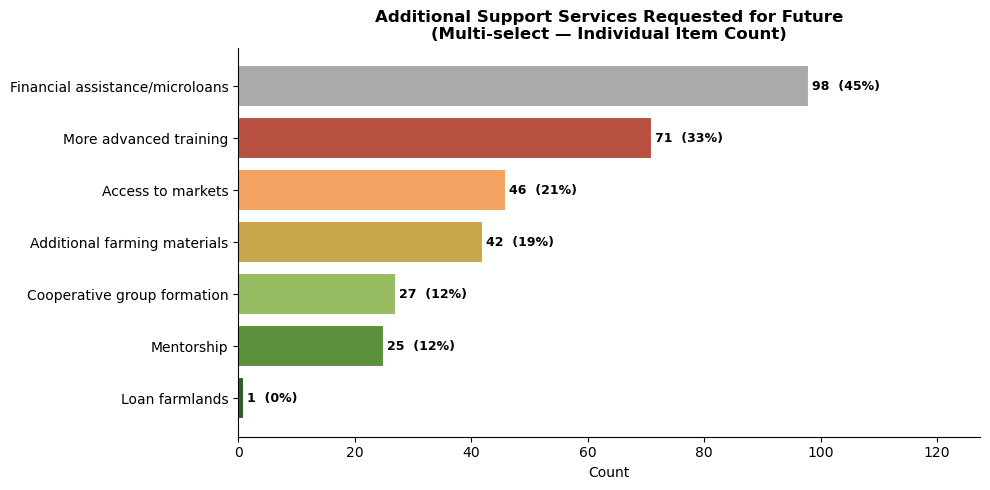

future_support
Loan farmlands                      1
Mentorship                         25
Cooperative group formation        27
Additional farming materials       42
Access to markets                  46
More advanced training             71
Financial assistance/microloans    98


In [37]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

fig, ax = plt.subplots(figsize=(10, 5))
fig.patch.set_facecolor('white')

C1="#2C5F2D"; C2="#97BC62"; C3="#C8A84B"; C4="#B85042"; C5="#5A8F3C"; C6="#F4A261"

support_counts = (
    df_encoded['future_support'].dropna()
    .astype(str)
    .str.split(r',\s*')
    .explode()
    .str.strip()
    .replace('', pd.NA)
    .dropna()
    .value_counts()
    .sort_values(ascending=True)
)

colors = [C1, C5, C2, C3, C6, C4, '#AAAAAA'][:len(support_counts)]
bars = ax.barh(support_counts.index, support_counts.values,
               color=colors, edgecolor='white', linewidth=1.5)

ax.set_title("Additional Support Services Requested for Future\n(Multi-select — Individual Item Count)",
             fontweight='bold', fontsize=12)
ax.set_xlabel("Count")
ax.set_xlim(0, support_counts.max() * 1.3)

for bar in bars:
    w = bar.get_width()
    if np.isfinite(w) and w > 0:
        ax.text(w + 0.5, bar.get_y() + bar.get_height()/2,
                f'{w:.0f}  ({100*w/len(df_encoded):.0f}%)',
                va='center', fontsize=9, fontweight='bold')

ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
plt.tight_layout()


print(support_counts.to_string())

# ── Export chart ─────────────────────────────────────────────────────────────
_chart_path = os.path.join(CHART_DIR, 's10_future_outlook__future_support_needs.png')
plt.savefig(_chart_path, dpi=150, bbox_inches='tight', facecolor='white')
print(f'Saved: {_chart_path}')
plt.show()


---
## 11. Mentor–Mentee Matching Framework

Builds and visualises the two-attribute mentor-mentee classification model
based on the statistical evidence from Sections 4 and 5.

### Why Two Attributes Are Needed
- **Experience** predicts knowledge (ρ>0, p<0.05) but **NOT** application (ρ=−0.04, p=0.535)
- **Age** predicts application (ρ=0.18, p=0.007) but **NOT** knowledge alone
- A good mentor needs both: knowledge to teach + motivation to apply as a model

### Role Classification
| Role | Age | Experience | Rationale |
|---|---|---|---|
| **Confirmed Mentor** | 30+ | 4+ years | Both knowledge depth and application motivation confirmed |
| **Potential Mentor** | 30+ | < 4 years | Application motivation present — needs knowledge development |
| **Potential Mentee** | < 30 | 4+ years | Knowledge present — needs application support |
| **Confirmed Mentee** | < 30 | < 4 years | Both dimensions need development — primary target group |

### Village-Level Capacity
- **Mangoro (1:4)** — under-resourced; needs cross-village mentor deployment
- **Agege (1:1)** — most favourable; recommended pilot launch site
- **Iyana Ipaja** — mentor surplus; can deploy to support Mangoro
- **107 Potential Mentors** — highest-leverage group; one advanced training module could triple the mentor pool


knowledge_score ready: 217 non-null values
df_match ready: (217, 9)
role
Potential Mentor\n(Age ✓, Exp ✗)    107
Mentee                               47
Mentor                               38
Potential Mentee\n(Age ✗, Exp ✓)     25


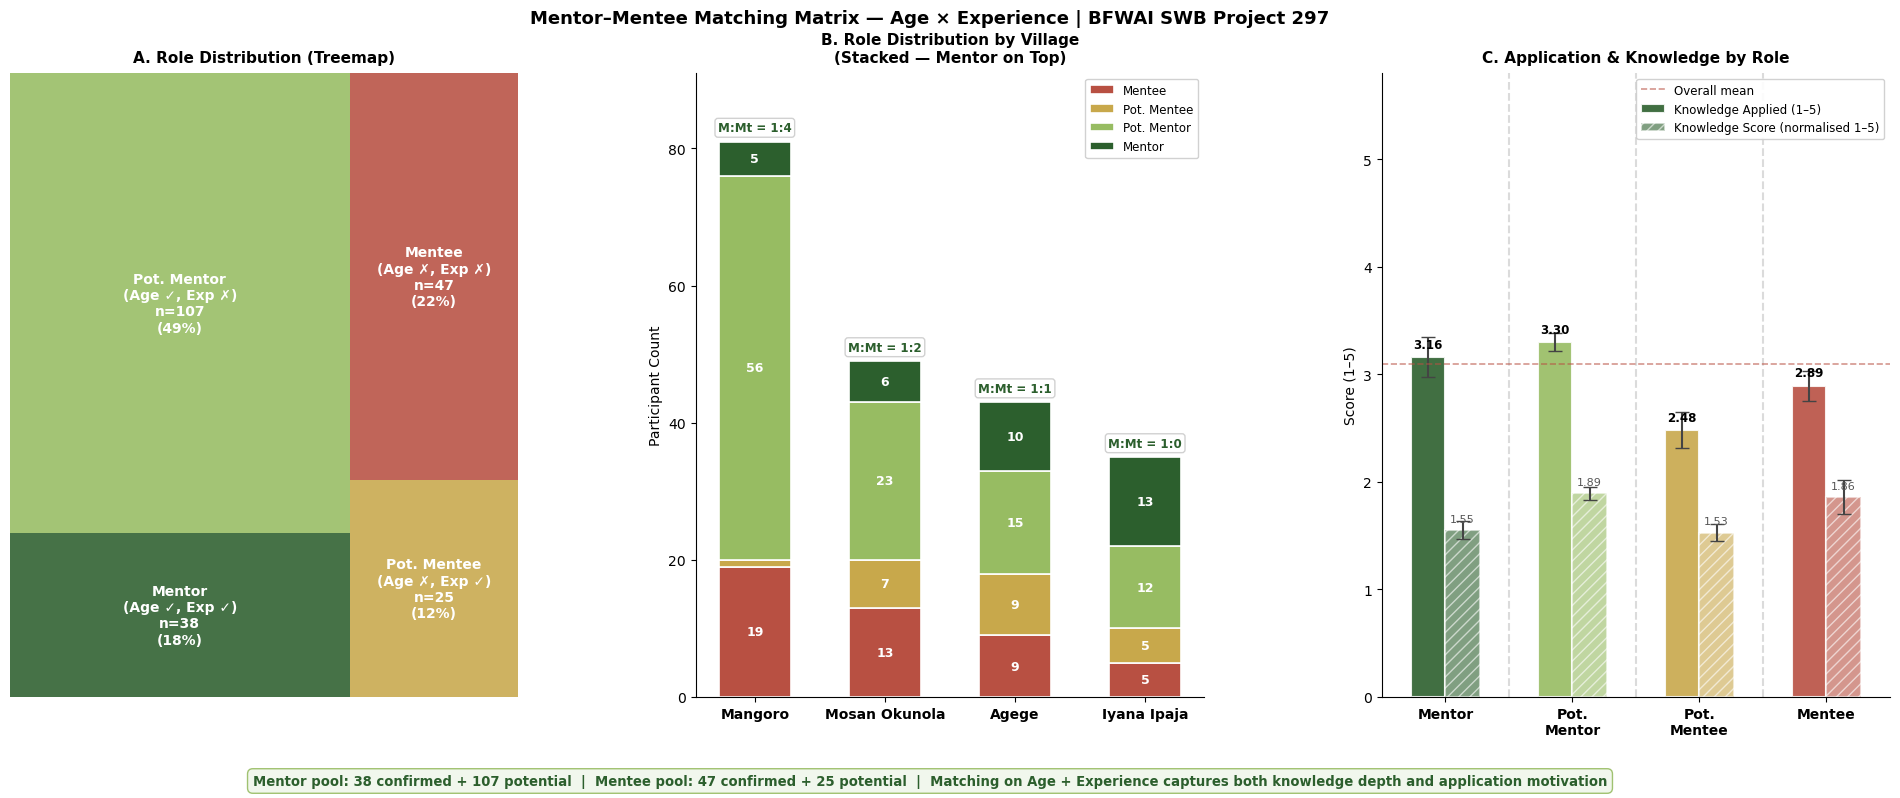

In [38]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np
import pandas as pd
import squarify

# ── Recreate knowledge_score in df_encoded ────────────────────────────────────
def partial_score(response, correct_set):
    if pd.isna(response):
        return np.nan
    selected = set(s.strip() for s in str(response).split(','))
    return len(selected & correct_set) / len(correct_set)

correct_q15 = {
    'Eliminate weeds competition during early growth',
    'Conserve soil and water nutrients',
    'Ensure increased yield growth',
    'Obtain a suitable bed'
}
correct_q16 = {
    'Obtain a specific number of plant population',
    'Improve individual plant rigour',
    'Obtain regular spacing of seedlings'
}
correct_q17 = {
    'Africa Land Snail (Archachatina Marginata)',
    'Africa Giant Snail (Achatina Achatina)',
    'Garden Snail (Achatina Fulica)'
}

likert_qs  = ['q23_organic_manure','q23_nutrient_timing','q23_transplant_timing','q23_overwatering']
reverse_qs = ['q23_nutrient_timing','q23_transplant_timing']

def likert_score(row):
    total, count = 0, 0
    for q in likert_qs:
        if pd.notna(row[q]):
            val = (6 - row[q]) if q in reverse_qs else row[q]
            total += val / 5
            count += 1
    return total / count if count > 0 else np.nan

df_encoded['score_q15']       = df.iloc[:, 19].apply(lambda x: partial_score(x, correct_q15))
df_encoded['score_q16']       = df.iloc[:, 20].apply(lambda x: partial_score(x, correct_q16))
df_encoded['score_q17']       = df.iloc[:, 21].apply(lambda x: partial_score(x, correct_q17))
df_encoded['score_q23']       = df_encoded.apply(likert_score, axis=1)
df_encoded['knowledge_score'] = df_encoded[['score_q15','score_q16',
                                             'score_q17','score_q23']].mean(axis=1) * 100
df_encoded['satisfaction']    = pd.to_numeric(df.iloc[:, 13], errors='coerce')
print("knowledge_score ready:", df_encoded['knowledge_score'].notna().sum(), "non-null values")

# ── Recreate df_match ─────────────────────────────────────────────────────────
age_order = ['Below 18 years', '19-29 years', '30-44 years', '45+ years']
exp_order = ['Less than 1 year', '1-3 years', '4-6 years', '7-10 years', 'More than 10 years']

df_match = df_encoded[['age_group', 'farming_exp', 'village',
                        'knowledge_applied', 'knowledge_score']].copy()
df_match['satisfaction']      = pd.to_numeric(df.iloc[:, 13], errors='coerce')
df_match['knowledge_applied'] = pd.to_numeric(df_match['knowledge_applied'], errors='coerce')
df_match['knowledge_score']   = pd.to_numeric(df_match['knowledge_score'],   errors='coerce')

df_match['age_senior'] = df_match['age_group'].isin(['30-44 years', '45+ years'])
df_match['exp_senior'] = df_match['farming_exp'].isin(
    ['4-6 years', '7-10 years', 'More than 10 years'])

def assign_role(row):
    if row['age_senior'] and row['exp_senior']:
        return 'Mentor'
    elif not row['age_senior'] and not row['exp_senior']:
        return 'Mentee'
    elif row['age_senior'] and not row['exp_senior']:
        return 'Potential Mentor\n(Age ✓, Exp ✗)'
    else:
        return 'Potential Mentee\n(Age ✗, Exp ✓)'

df_match['role'] = df_match.apply(assign_role, axis=1)
print("df_match ready:", df_match.shape)
print(df_match['role'].value_counts().to_string())

# ── Colours & role mappings ───────────────────────────────────────────────────
C1="#2C5F2D"; C2="#97BC62"; C3="#C8A84B"; C4="#B85042"; C5="#5A8F3C"; C6="#F4A261"

role_order = [
    'Mentor',
    'Potential Mentor\n(Age ✓, Exp ✗)',
    'Potential Mentee\n(Age ✗, Exp ✓)',
    'Mentee'
]
role_colors = {
    'Mentor':                           C1,
    'Potential Mentor\n(Age ✓, Exp ✗)': C2,
    'Potential Mentee\n(Age ✗, Exp ✓)': C3,
    'Mentee':                           C4,
}
role_short = {
    'Mentor':                           'Mentor',
    'Potential Mentor\n(Age ✓, Exp ✗)': 'Pot. Mentor',
    'Potential Mentee\n(Age ✗, Exp ✓)': 'Pot. Mentee',
    'Mentee':                           'Mentee',
}
role_short2 = {
    'Mentor':                           'Mentor\n(Age ✓, Exp ✓)',
    'Potential Mentor\n(Age ✓, Exp ✗)': 'Pot. Mentor\n(Age ✓, Exp ✗)',
    'Potential Mentee\n(Age ✗, Exp ✓)': 'Pot. Mentee\n(Age ✗, Exp ✓)',
    'Mentee':                           'Mentee\n(Age ✗, Exp ✗)',
}

# ── Figure layout ─────────────────────────────────────────────────────────────
fig = plt.figure(figsize=(20, 8))
fig.patch.set_facecolor('white')
fig.suptitle("Mentor–Mentee Matching Matrix — Age × Experience | BFWAI SWB Project 297",
             fontsize=13, fontweight='bold', y=0.98)

gs = fig.add_gridspec(1, 3, wspace=0.35, left=0.04, right=0.98,
                      top=0.90, bottom=0.12)
ax1 = fig.add_subplot(gs[0])
ax2 = fig.add_subplot(gs[1])
ax3 = fig.add_subplot(gs[2])

# ══════════════════════════════════════════════════════════════════════════════
# Panel A: Treemap
# ══════════════════════════════════════════════════════════════════════════════
role_counts = df_match['role'].value_counts()
sizes  = [role_counts.get(r, 0) for r in role_order]
colors = [role_colors[r] for r in role_order]
labels = [
    f"{role_short2[r]}\nn={role_counts.get(r, 0)}\n({100*role_counts.get(r, 0)/sum(sizes):.0f}%)"
    for r in role_order
]
squarify.plot(sizes=sizes, label=labels, color=colors,
              alpha=0.88, ax=ax1,
              text_kwargs={'fontsize': 10, 'fontweight': 'bold', 'color': 'white'})
ax1.set_title("A. Role Distribution (Treemap)", fontweight='bold', fontsize=11, pad=8)
ax1.axis('off')

# ══════════════════════════════════════════════════════════════════════════════
# Panel B: Stacked bar by village — Mentor on top
# ══════════════════════════════════════════════════════════════════════════════
village_order = ['Mangoro', 'Mosan Okunola', 'Agege', 'Iyana Ipaja']
cross = pd.crosstab(df_match['village'], df_match['role'])
cross = cross.reindex(village_order).fillna(0)

stack_order = [r for r in [
    'Mentee',
    'Potential Mentee\n(Age ✗, Exp ✓)',
    'Potential Mentor\n(Age ✓, Exp ✗)',
    'Mentor'
] if r in cross.columns]

x      = np.arange(len(village_order))
bottom = np.zeros(len(village_order))

for role in stack_order:
    vals = cross[role].values if role in cross.columns else np.zeros(len(village_order))
    bars = ax2.bar(x, vals, 0.55, bottom=bottom,
                   color=role_colors[role], edgecolor='white',
                   linewidth=1.2, label=role_short[role])
    for i, (v, b) in enumerate(zip(vals, bottom)):
        if v >= 3:
            ax2.text(x[i], b + v/2, f'{v:.0f}',
                     ha='center', va='center',
                     fontsize=9, fontweight='bold', color='white')
    bottom += vals

totals = cross[stack_order].sum(axis=1)
for i, v in enumerate(village_order):
    m  = cross.loc[v, 'Mentor'] if 'Mentor' in cross.columns else 0
    mt = cross.loc[v, 'Mentee'] if 'Mentee' in cross.columns else 0
    ratio = f"M:Mt = 1:{mt/m:.0f}" if m > 0 else "No mentor"
    ax2.text(i, totals.iloc[i] + 1.5, ratio,
             ha='center', fontsize=8.5, fontweight='bold',
             color=C4 if m == 0 else C1,
             bbox=dict(boxstyle='round,pad=0.25', facecolor='white',
                       edgecolor='#CCCCCC', alpha=0.9))

ax2.set_xticks(x)
ax2.set_xticklabels(village_order, fontsize=10, fontweight='bold')
ax2.set_title("B. Role Distribution by Village\n(Stacked — Mentor on Top)",
              fontweight='bold', fontsize=11, pad=8)
ax2.set_ylabel("Participant Count", fontsize=10)
ax2.set_ylim(0, totals.max() + 10)
ax2.legend(fontsize=8.5, loc='upper right', framealpha=0.9)
ax2.spines['top'].set_visible(False)
ax2.spines['right'].set_visible(False)

# ══════════════════════════════════════════════════════════════════════════════
# Panel C: Application & Knowledge score by role
# ══════════════════════════════════════════════════════════════════════════════
roles_clean = [
    'Mentor',
    'Potential Mentor\n(Age ✓, Exp ✗)',
    'Potential Mentee\n(Age ✗, Exp ✓)',
    'Mentee'
]
roles_short = ['Mentor', 'Pot.\nMentor', 'Pot.\nMentee', 'Mentee']

app_means, app_ses, kno_means, kno_ses = [], [], [], []
for role in roles_clean:
    sub = df_match[df_match['role'] == role]
    a   = sub['knowledge_applied'].dropna()
    k   = sub['knowledge_score'].dropna()
    app_means.append(a.mean() if len(a) > 0 else 0)
    app_ses.append(a.std() / np.sqrt(len(a)) if len(a) > 1 else 0)
    kno_means.append(k.mean() if len(k) > 0 else 0)
    kno_ses.append(k.std() / np.sqrt(len(k)) if len(k) > 1 else 0)

kno_means_norm = [k / 100 * 5 for k in kno_means]
kno_ses_norm   = [s / 100 * 5 for s in kno_ses]

group_gap2 = 1.4
x2 = np.arange(len(roles_clean)) * group_gap2
w  = 0.38

bars1 = ax3.bar(x2 - w/2, app_means, w, yerr=app_ses,
                color=[role_colors[r] for r in roles_clean],
                edgecolor='white', linewidth=1.5,
                capsize=5, error_kw=dict(ecolor='#444', lw=1.5),
                label='Knowledge Applied (1–5)', alpha=0.9)
bars2 = ax3.bar(x2 + w/2, kno_means_norm, w, yerr=kno_ses_norm,
                color=[role_colors[r] for r in roles_clean],
                edgecolor='white', linewidth=1.5, hatch='///',
                capsize=5, error_kw=dict(ecolor='#444', lw=1.5),
                label='Knowledge Score (normalised 1–5)', alpha=0.6)

for xi in x2[:-1]:
    ax3.axvline(xi + group_gap2/2, color='#CCCCCC',
                linewidth=1.5, linestyle='--', alpha=0.7)

ax3.set_xticks(x2)
ax3.set_xticklabels(roles_short, fontsize=10, fontweight='bold')
ax3.set_title("C. Application & Knowledge by Role",
              fontweight='bold', fontsize=11, pad=8)
ax3.set_ylabel("Score (1–5)", fontsize=10)
ax3.set_ylim(0, 5.8)
ax3.set_xlim(x2[0] - group_gap2/2, x2[-1] + group_gap2/2)
ax3.axhline(df_match['knowledge_applied'].mean(), color=C4,
            linestyle='--', linewidth=1.2, alpha=0.6, label='Overall mean')
ax3.legend(fontsize=8.5, loc='upper right', framealpha=0.9)
ax3.spines['top'].set_visible(False)
ax3.spines['right'].set_visible(False)

for bar in list(bars1):
    h = bar.get_height()
    if 0 < h <= 5.5:
        ax3.text(bar.get_x() + bar.get_width()/2, h + 0.06,
                 f'{h:.2f}', ha='center', va='bottom',
                 fontsize=8.5, fontweight='bold')

for bar in list(bars2):
    h = bar.get_height()
    if 0 < h <= 5.5:
        ax3.text(bar.get_x() + bar.get_width()/2, h + 0.06,
                 f'{h:.2f}', ha='center', va='bottom',
                 fontsize=8, color='#555')

# ── Bottom conclusion ─────────────────────────────────────────────────────────
mentor_n     = role_counts.get('Mentor', 0)
mentee_n     = role_counts.get('Mentee', 0)
pot_mentor_n = role_counts.get('Potential Mentor\n(Age ✓, Exp ✗)', 0)
pot_mentee_n = role_counts.get('Potential Mentee\n(Age ✗, Exp ✓)', 0)

fig.text(0.5, 0.01,
         f"Mentor pool: {mentor_n} confirmed + {pot_mentor_n} potential  |  "
         f"Mentee pool: {mentee_n} confirmed + {pot_mentee_n} potential  |  "
         f"Matching on Age + Experience captures both knowledge depth and application motivation",
         ha='center', fontsize=9.5, fontweight='bold', color=C1,
         bbox=dict(boxstyle='round,pad=0.4', facecolor='#F0F7EC',
                   edgecolor=C2, alpha=0.9))

# ── Export chart ─────────────────────────────────────────────────────────────
_chart_path = os.path.join(CHART_DIR, 's11_mentor_mentee__mentor_mentee_treemap_village_roles.png')
plt.savefig(_chart_path, dpi=150, bbox_inches='tight', facecolor='white')
print(f'Saved: {_chart_path}')
plt.show()
